# Oral antibacterial prescribing in England — second-order effects of stewardship
## Corrected analysis pipeline

ICB-month panel, January 2021 – December 2025 (configurable), NHS Business Services Authority
Prescription Cost Analysis (PCA) monthly extracts.

Rewrite of `clean_of_Drugantibacterials-2.ipynb`. The architecture, defensive coding style and
publication conventions follow the corrected opioid pipeline; the exposure definition, outcomes,
event register and substitution designs are specific to antibacterials and map onto the three
aims of the CID manuscript:

1. **Fluoroquinolone restriction** — did the MHRA restrictions displace prescribing, and into which agents?
2. **Supply shocks** — did the 2022–23 Group A streptococcus surge and the serious shortage protocols (SSPs) generate substitution cascades?
3. **Guideline-driven shifts** — did the urinary-market shift persist, and what did the in-window nitrofurantoin safety update do?

**What changed, and why**

| # | Problem in the previous notebook | Fix |
|---|---|---|
| A1 | Drugs matched on exact title-cased chemical names. PCA names are salt-qualified (`Flucloxacillin sodium`, `Doxycycline hyclate`, `Phenoxymethylpenicillin (Penicillin V)`, `Co-amoxiclav (Amoxicillin/clavulanic acid)`, `Pivmecillinam hydrochloride`), so they never matched. The notebook's own log: *"Missing drugs: Flucloxacillin, Doxycycline, Phenoxymethylpenicillin, Co-Amoxiclav"*. Two of five switching pairs ran; ciprofloxacin → co-amoxiclav, the headline dyad, was never computed. | Exposure defined by **BNF section 5.1 (`0501`)**, then ordered word-boundary rules on the chemical name, with self-tests for every failure mode. The pipeline **halts** if any cohort drug is absent from any month. |
| A2 | Earlier cells used substring matching (`'TRIMETHOPRIM'` matches co-trimoxazole; `'AMOXICILLIN'` matches co-amoxiclav) and assigned labels by iterating a Python `set`, whose order changes between sessions — so whether co-amoxiclav became "amoxicillin" varied from run to run. `pivot_table` then **averaged** (its default) rather than summed salts of one drug. | Combination products matched first, fixed rule order, `aggfunc="sum"` throughout. |
| A3 | Events dated before the data (NG109, NG111, MHRA 2019, NAP 2019) became step dummies equal to 1 in every month — identical to the intercept. The pseudo-inverse split the intercept between them: the reported "NG109 effect" (+171,787 nitrofurantoin items/month) is half of nitrofurantoin's January 2021 level. The "COVID onset" pulse sat on January 2021. The planned "NG109 success story" rests on this artefact. | A verified **event register** with an estimability guard: an event is modelled only with ≥12 usable pre- and ≥6 post-intervention months, and any design that is rank-deficient **raises** instead of being solved by pseudo-inverse. |
| A4 | Event dates wrong or unverifiable. NG109 given as Apr 2019 (published 31 Oct 2018). Clarithromycin SSP given as Sep 2023 (issued 6 Apr 2023, and a *formulation* substitution, not a switch to other macrolides). "NHS AMR TARGET refresh", "UKHSA NAP milestone" and "NICE antimicrobial prescribing review (Jun 2023)" have no identifiable primary source; the IV-to-oral CQUIN is a hospital scheme. The nitrofurantoin safety update (26 Apr 2023) was missing. | Event register with dates to the day where known, source, verification status, and the reason every old-timeline entry was kept or dropped (Table 1). |
| A5 | Intervention model: all 15 events entered for every drug at once, on raw counts, linear trend, no seasonality, HC3 errors (heteroscedasticity- but not autocorrelation-robust) on monthly data. | Pre-specified outcome–event pairs. Segmented regression on log-odds of share (composition) or log items with a working-day term (volume); Fourier seasonality; Newey–West errors; Breusch–Godfrey; placebo-date scan; counterfactual effects in items with simulation intervals. |
| A6 | "Switching intensity" = \|Δ source drug\| ÷ pair total: month-to-month volatility of one drug, dominated by season and working days; the target drug never enters the numerator. | Pair share from/(from + to), as the manuscript defines it, on the logit scale. |
| A7 | Breaks: CUSUM boundary formula incorrect; Bai–Perron compared RSS across break counts with no penalty (always picks the maximum); PELT penalty on the raw-data scale (16–17 "breaks" in 60 months); all run on seasonal series. | HAC-scaled OLS-CUSUM with a simulated null; Bai–Perron dynamic programming with BIC/LWZ selection and block-bootstrap break-date intervals; PELT on the same segment model with a BIC penalty; all on STL-deseasonalised series. Breaks are linked to events by whether the event falls inside the break-date interval, not by "nearest event". |
| A8 | Granger tests on seasonal levels, lag chosen by minimum p-value, stationarity tested on one series only, no FDR (the Methods say BH-FDR), 16-variable VAR from 60 points: 15/30 pairs "significant", including trimethoprim → clarithromycin. Conceptually, substitution is *contemporaneous*; Granger tests only lagged predictability. | VAR/Granger kept as **descriptive**, within clinical markets, on deseasonalised log-ratio series, AIC lag within a feasible maximum, BH-FDR, stability check. Inference on substitution comes from event-anchored designs (A5, A16) and ICB panel cross-lagged models. |
| A9 | IRF bands: when Monte Carlo failed the code drew `se = \|irf\|*0.25 + …` — invented intervals. 100 replications (Methods: 1,000). Shock of one raw item. | Orthogonalised IRFs on log-ratio series (ordering stated), 1,000 replications, no fallback: if bands cannot be computed the figure is not drawn. |
| A10 | The Excel export wrote a hard-coded "Analytical_Impact" column ("confirmed by IRF & Granger", "Sharp Ciprofloxacin/Levofloxacin ↓ …") whatever the data said. | Removed. Every sentence the pipeline prints is generated from an estimate. |
| A11 | BOCPD could never detect a changepoint: with a constant hazard, P(run length = 0 \| data) equals the hazard (0.02) at every step — below the 0.40 threshold. The run returned `[]`. | Normal–gamma BOCPD with Student-t predictive; changepoints read from resets of the MAP run length. Exploratory (Supplement). |
| A12 | HMM on raw amoxicillin counts — the "regimes" are seasons; `startprob_` never initialised. | HMM on the deseasonalised series, 2 vs 3 states by BIC, multiple restarts. Exploratory. |
| A13 | "Markov transition matrices" estimated from aggregate market shares: up to 49 unconstrained transition probabilities from 59 transitions, ecological (courses are acute; next month's patients are different people), p-values from a normal approximation at the [0, 1] boundary. | Removed. Substitution is estimated from policy shocks (national ITS and the ICB intensity design). |
| A14 | Spatial maps labelled "rate" plot raw counts (PCA has no denominator); 4/10 drugs failed to match; `ICB_NAME` is empty Jan 2021–Apr 2022 (files carry `STP_*` then), so 16 months silently dropped; merge on cleaned name strings. | Removed (not a manuscript aim). If wanted, reuse the opioid pipeline's ODS-coded boundary and denominator linkage. |
| A15 | Tablets/capsules only. Fosfomycin (granules) contributes zero despite being in the cohort; paediatric Strep A prescribing (liquids) is invisible; SSP054 converted clarithromycin suspension prescriptions into 250 mg tablets, which a tablets-only series records as a clarithromycin surge. | Formulation kept as a column. Primary scope **all oral formulations**; solid-only as a sensitivity; the formulation shift itself is quantified. |
| A16 | Shares computed within the 16-drug cohort or ad hoc "markets": displacement to any agent outside the subset was invisible, and closure effects were read as substitution. | Denominator = **all systemic antibacterial items** (BNF 5.1 minus antituberculosis 5.1.9 and antileprotic 5.1.10), partitioned exhaustively into 21 units. An ICB **intensity design** decomposes where displaced fluoroquinolone share went, against a pro-rata (closure-only) benchmark. |
| A17 | Geography: `ICB_NAME` used throughout. | Geography resolved per file (`STP_CODE` → `ICB_CODE`) to one ODS `ORG_CODE`; month coverage asserted. |
| A18 | All 60 files (~230 MB each, 34.6 M rows) loaded simultaneously as strings. | One file at a time, needed columns only, filtered to BNF 5.1 on read, cached extract. |
| A19 | Six near-duplicate cells plus a leftover ophthalmic figure: any reported number could have come from any of them. | One pipeline, executed once, top to bottom. |
| A20 | The cohort in the first analysis cells (lymecycline, clindamycin, oxytetracycline) differed from the manuscript's (levofloxacin, pivmecillinam, fosfomycin). | Cohort defined once in CONFIG, matching the manuscript; all other agents stay in the denominator. |

**Standing caveat, applies to every result below.** PCA is dispensing data aggregated to
organisation and month. It carries no patient identifiers, no indication, no dose instruction.
"Substitution" here always means a population-level reallocation of dispensed items coinciding
with a policy or supply shock. It cannot show that an individual patient who would have received
drug A received drug B instead.

**Before running:** set `DATA_DIR`. Everything else has a justified default. All tables are
written to `outputs_antibacterials/` as CSV, figures to `outputs_antibacterials/figures/` as PNG
and PDF.

In [1]:
# Google Colab: mount Drive and move to the data folder. Harmless elsewhere.
import os
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    os.chdir("/content/drive/MyDrive/KCL/Drug/")
except ImportError:
    print("Not running in Colab - using the current working directory: " + os.getcwd())

Mounted at /content/drive


In [2]:
!pip install -q ruptures hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 11.9 MB/s eta 0:00:00


## 1. Configuration

Every analytical choice that could change a result is set here and printed. The defaults are
the recommended primary analysis; the sensitivity section re-runs the key models with the
alternatives.

**Formulation scope.** The draft Methods restrict to tablets and capsules. That makes
fosfomycin (granules) disappear, hides paediatric prescribing during the Strep A surge, and turns
clarithromycin SSP054 (suspension dispensed as tablets) into an apparent clarithromycin-tablet
surge. `"all_oral"` is recommended as primary; `"solid_oral"` reproduces the draft definition and
is run automatically as a sensitivity analysis.

**Study window.** NG109/NG111 (31 Oct 2018) and the first MHRA fluoroquinolone restriction
(Mar 2019) pre-date a 2021 start and are **not estimable** from these data. Put earlier extracts
in `DATA_DIR` and lower `STUDY_START` (201701 or earlier) and the event register re-evaluates
estimability automatically. COVID-19 months are excluded from every estimation window regardless.

In [3]:
import os, re, glob, json, math, hashlib, warnings, itertools, time
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*divide by zero.*")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 250)

# ----------------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------------
DATA_DIR = "."                    # folder holding the monthly PCA extracts (pca_YYYYMM.csv)
FILE_GLOB = "pca_*.csv"
OUT_DIR = "outputs_antibacterials"
USE_EXTRACT_CACHE = True          # re-use the BNF 5.1 extract while the raw files are unchanged

# ----------------------------------------------------------------------------
# STUDY WINDOW
# ----------------------------------------------------------------------------
STUDY_START = 202101
STUDY_END = 202512

# ----------------------------------------------------------------------------
# EXPOSURE DEFINITION
# ----------------------------------------------------------------------------
FORMULATION_SCOPE = "all_oral"    # "all_oral" (recommended primary) | "solid_oral" (draft Methods)
SCOPE_FORMS = {"all_oral": ["oral_solid", "oral_liquid"], "solid_oral": ["oral_solid"]}

BNF_ANTIBACTERIAL_PREFIX = "0501"                     # BNF 5.1 antibacterial drugs
BNF_EXCLUDE_PREFIXES = {"050109": "antituberculosis drugs (BNF 5.1.9)",
                        "050110": "antileprotic drugs (BNF 5.1.10)"}

# The 16-drug cohort, exactly as listed in the manuscript Methods.
COHORT = ["Amoxicillin", "Co-amoxiclav", "Phenoxymethylpenicillin", "Flucloxacillin",
          "Cefalexin", "Clarithromycin", "Erythromycin", "Azithromycin", "Doxycycline",
          "Ciprofloxacin", "Levofloxacin", "Trimethoprim", "Nitrofurantoin", "Pivmecillinam",
          "Fosfomycin", "Metronidazole"]
# Everything else in BNF 5.1 is kept, so the 21 units partition ALL systemic antibacterial items
# and no displaced prescribing can leave the denominator.
OTHER_UNITS = ["Other quinolones", "Other cephalosporins", "Other tetracyclines",
               "Co-trimoxazole", "Other antibacterials"]
UNIT_ORDER = COHORT + OTHER_UNITS

UNIT_CLASS = {
    "Amoxicillin": "Penicillins", "Co-amoxiclav": "Penicillins",
    "Phenoxymethylpenicillin": "Penicillins", "Flucloxacillin": "Penicillins",
    "Cefalexin": "Cephalosporins", "Other cephalosporins": "Cephalosporins",
    "Clarithromycin": "Macrolides", "Erythromycin": "Macrolides", "Azithromycin": "Macrolides",
    "Doxycycline": "Tetracyclines", "Other tetracyclines": "Tetracyclines",
    "Ciprofloxacin": "Fluoroquinolones", "Levofloxacin": "Fluoroquinolones",
    "Other quinolones": "Fluoroquinolones",
    "Trimethoprim": "Urinary tract agents", "Nitrofurantoin": "Urinary tract agents",
    "Pivmecillinam": "Urinary tract agents", "Fosfomycin": "Urinary tract agents",
    "Metronidazole": "Nitroimidazoles",
    "Co-trimoxazole": "Other antibacterials", "Other antibacterials": "Other antibacterials",
}
CLASS_ORDER = ["Penicillins", "Cephalosporins", "Macrolides", "Tetracyclines",
               "Fluoroquinolones", "Urinary tract agents", "Nitroimidazoles",
               "Other antibacterials"]
# NHS England broad-spectrum stewardship measure: co-amoxiclav + cephalosporins + quinolones.
BROAD_SPECTRUM_UNITS = ["Co-amoxiclav", "Cefalexin", "Other cephalosporins",
                        "Ciprofloxacin", "Levofloxacin", "Other quinolones"]

# The eight pre-specified dyads from the manuscript. Pair share = from / (from + to).
KEY_PAIRS = [
    ("Trimethoprim", "Nitrofurantoin", "NG109 urinary shift"),
    ("Amoxicillin", "Doxycycline", "respiratory tract infection"),
    ("Amoxicillin", "Co-amoxiclav", "broad-spectrum escalation"),
    ("Cefalexin", "Flucloxacillin", "skin and soft tissue"),
    ("Amoxicillin", "Clarithromycin", "macrolide substitution"),
    ("Clarithromycin", "Erythromycin", "macrolide cascade in shortage"),
    ("Ciprofloxacin", "Co-amoxiclav", "post-MHRA displacement"),
    ("Nitrofurantoin", "Pivmecillinam", "second-line urinary escalation"),
]
FQ_ALTERNATIVES = ["Co-amoxiclav", "Cefalexin", "Other cephalosporins", "Doxycycline",
                   "Nitrofurantoin", "Pivmecillinam", "Trimethoprim", "Co-trimoxazole",
                   "Amoxicillin", "Clarithromycin", "Azithromycin", "Fosfomycin"]
CASCADE_UNITS = ["Phenoxymethylpenicillin", "Amoxicillin", "Clarithromycin", "Azithromycin",
                 "Erythromycin", "Flucloxacillin", "Cefalexin", "Co-amoxiclav", "Doxycycline"]
URINARY_UNITS = ["Trimethoprim", "Nitrofurantoin", "Pivmecillinam", "Fosfomycin"]
MARKETS = {
    "Respiratory": ["Amoxicillin", "Phenoxymethylpenicillin", "Co-amoxiclav",
                    "Clarithromycin", "Doxycycline"],
    "Urinary": ["Trimethoprim", "Nitrofurantoin", "Pivmecillinam"],
    "Skin and soft tissue": ["Flucloxacillin", "Cefalexin", "Clarithromycin"],
    "Fluoroquinolone displacement": ["Fluoroquinolones", "Co-amoxiclav", "Cefalexin",
                                     "Doxycycline"],
}

# ----------------------------------------------------------------------------
# MODELLING OPTIONS
# ----------------------------------------------------------------------------
DDD_PER_ITEM_EXCEPTIONS = {"Fosfomycin": (0.5, 3.0)}   # single-dose treatments
INFORMATIVE_CI_PP = 100                        # a share-of-displaced interval wider than this says nothing
DDD_PER_ITEM_RANGE = (2.0, 20.0)               # plausible DDDs per prescription for an acute oral course
FOURIER_HARMONICS = 2            # annual seasonality: sin/cos pairs
NW_MAXLAGS = 6                   # Newey-West lags (sensitivity: 12)
BG_LAGS = 6                      # Breusch-Godfrey lags
ITS_MIN_PRE, ITS_MIN_POST = 12, 6
ITS_MAX_PRE, ITS_MAX_POST = 36, 36
COVID_EXCLUDE = ("2020-03-23", "2021-07-19")   # first lockdown to roadmap step 4
CASCADE_MONTHS = (202211, 202305)              # Strep A surge + PenV SSP period, month by month
BASELINE_FQ_PERIOD = (202107, 202206)          # ICB fluoroquinolone intensity is measured here...
PANEL_WINDOW = (202207, 202512)                # ...and never inside the estimation window
EVENT_STUDY_ANCHOR = 202401                    # quarters counted from Jan 2024
EVENT_STUDY_REF_BIN = -3                       # Apr-Jun 2023: last quarter before any 2023 FQ event
BREAK_MAX, BREAK_TRIM, BREAK_TOL = 3, 0.15, 2  # max breaks, trimming, concordance tolerance (months)
PELT_BIC_MULTIPLIER = 1.0                      # 1 = BIC-type penalty on a correctly scaled cost
VAR_MAX_LAG = 3
IRF_HORIZON = 12
BOCPD_HAZARD = 1 / 50
RANDOM_SEED = 20240122

# FAST_MODE (environment variable ABX_FAST_MODE=1) cuts replication counts for testing only.
FAST_MODE = os.environ.get("ABX_FAST_MODE", "0") == "1"
N_SIM = 400 if FAST_MODE else 10000             # parametric simulation for absolute effects
N_BOOT = 199 if FAST_MODE else 9999             # wild cluster bootstrap (Methods: 9,999)
N_BOOT_BREAK = 49 if FAST_MODE else 999         # break-date block bootstrap (Methods: 999)
IRF_REPS = 100 if FAST_MODE else 1000           # Monte Carlo IRF bands (Methods: 1,000)

# ----------------------------------------------------------------------------
# HOUSEKEEPING
# ----------------------------------------------------------------------------
FIGDIR = os.path.join(OUT_DIR, "figures")
SFIGDIR = os.path.join(FIGDIR, "supplementary")
os.makedirs(SFIGDIR, exist_ok=True)
RESULTS = {}


def save(name, df, index=False):
    path = os.path.join(OUT_DIR, name + ".csv")
    df.to_csv(path, index=index)
    print("  written: " + path)


def banner(text):
    print("\n" + "=" * 90 + "\n" + text + "\n" + "=" * 90)


def key(name):
    return re.sub(r"[^A-Z0-9]+", "_", str(name).upper()).strip("_")


# ---- calendar helpers (YYYYMM integers throughout) ---------------------------
def ym_index(ym):
    return (int(ym) // 100) * 12 + int(ym) % 100 - 1


def ym_from_index(i):
    return (i // 12) * 100 + i % 12 + 1


def ym_add(ym, k):
    return ym_from_index(ym_index(ym) + k)


def ym_range(a, b):
    return [ym_from_index(i) for i in range(ym_index(a), ym_index(b) + 1)]


def to_dates(yms):
    return pd.to_datetime([str(int(v)) for v in yms], format="%Y%m")


def month_bounds(ym):
    y, m = divmod(int(ym), 100)
    return date(y, m, 1), date(y + (m == 12), m % 12 + 1, 1)


def month_days(ym):
    a, b = month_bounds(ym)
    return (b - a).days


def parse_event_date(s):
    """'YYYY-MM-DD' -> (YYYYMM, date);  'YYYY-MM' -> (YYYYMM, None)  (day not confirmed)."""
    s = str(s)
    if len(s) == 7:
        return int(s[:4]) * 100 + int(s[5:7]), None
    d = pd.Timestamp(s).date()
    return d.year * 100 + d.month, d


def step_exposure(yms, when):
    """Share of each month on/after the event. Month-only dates code the event month 0.5."""
    ym0, d0 = parse_event_date(when)
    out = []
    for ym in yms:
        if ym < ym0:
            out.append(0.0)
        elif ym > ym0:
            out.append(1.0)
        else:
            out.append(0.5 if d0 is None else (month_days(ym) - d0.day + 1) / month_days(ym))
    return np.array(out, float)


def window_exposure(yms, start, end):
    """Share of each month's days falling inside [start, end] (inclusive)."""
    ys, ds = parse_event_date(start)
    ye, de = parse_event_date(end)
    ds = ds or month_bounds(ys)[0]
    de = de or (month_bounds(ye)[1] - timedelta(days=1))
    out = []
    for ym in yms:
        a, b = month_bounds(ym)
        lo, hi = max(a, ds), min(b - timedelta(days=1), de)
        out.append(max(0, (hi - lo).days + 1) / month_days(ym))
    return np.array(out, float)


# ---- England & Wales bank holidays, for the working-day covariate ----------
_BH_LIST = [
    "2014-01-01", "2014-04-18", "2014-04-21", "2014-05-05", "2014-05-26", "2014-08-25", "2014-12-25", "2014-12-26",
    "2015-01-01", "2015-04-03", "2015-04-06", "2015-05-04", "2015-05-25", "2015-08-31", "2015-12-25", "2015-12-28",
    "2016-01-01", "2016-03-25", "2016-03-28", "2016-05-02", "2016-05-30", "2016-08-29", "2016-12-26", "2016-12-27",
    "2017-01-02", "2017-04-14", "2017-04-17", "2017-05-01", "2017-05-29", "2017-08-28", "2017-12-25", "2017-12-26",
    "2018-01-01", "2018-03-30", "2018-04-02", "2018-05-07", "2018-05-28", "2018-08-27", "2018-12-25", "2018-12-26",
    "2019-01-01", "2019-04-19", "2019-04-22", "2019-05-06", "2019-05-27", "2019-08-26", "2019-12-25", "2019-12-26",
    "2020-01-01", "2020-04-10", "2020-04-13", "2020-05-08", "2020-05-25", "2020-08-31", "2020-12-25", "2020-12-28",
    "2021-01-01", "2021-04-02", "2021-04-05", "2021-05-03", "2021-05-31", "2021-08-30", "2021-12-27", "2021-12-28",
    "2022-01-03", "2022-04-15", "2022-04-18", "2022-05-02", "2022-06-02", "2022-06-03", "2022-08-29", "2022-09-19",
    "2022-12-26", "2022-12-27",
    "2023-01-02", "2023-04-07", "2023-04-10", "2023-05-01", "2023-05-08", "2023-05-29", "2023-08-28", "2023-12-25",
    "2023-12-26",
    "2024-01-01", "2024-03-29", "2024-04-01", "2024-05-06", "2024-05-27", "2024-08-26", "2024-12-25", "2024-12-26",
    "2025-01-01", "2025-04-18", "2025-04-21", "2025-05-05", "2025-05-26", "2025-08-25", "2025-12-25", "2025-12-26",
    "2026-01-01", "2026-04-03", "2026-04-06", "2026-05-04", "2026-05-25", "2026-08-31", "2026-12-25", "2026-12-28",
]
_BH = {pd.Timestamp(d).date() for d in _BH_LIST}


def working_days(ym):
    """Mon-Fri excluding England & Wales bank holidays. Acute antibacterial prescribing follows
    GP opening days, so a month with Easter in it is not comparable with one without."""
    if not 2014 <= int(ym) // 100 <= 2026:
        raise ValueError("Bank holidays are hard-coded for 2014-2026 only; extend _BH_LIST.")
    a, b = month_bounds(ym)
    n, d = 0, a
    while d < b:
        n += (d.weekday() < 5) and (d not in _BH)
        d += timedelta(days=1)
    return n


# ---- figure conventions: Arial, 300 dpi, mm widths, Okabe-Ito palette -------
MM = 1 / 25.4
OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73", "vermillion": "#D55E00",
         "sky": "#56B4E9", "purple": "#CC79A7", "yellow": "#F0E442", "black": "#000000",
         "grey": "#666666"}
CLASS_COLOURS = dict(zip(CLASS_ORDER, [OKABE["blue"], OKABE["orange"], OKABE["green"],
                                       OKABE["sky"], OKABE["vermillion"], OKABE["purple"],
                                       OKABE["yellow"], "#BBBBBB"]))
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8.5, "xtick.labelsize": 7,
    "ytick.labelsize": 7, "legend.fontsize": 7, "axes.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
    "savefig.dpi": 300, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "legend.frameon": False, "lines.linewidth": 1.0,
})


def _save(fig, name, supplementary=False):
    folder = SFIGDIR if supplementary else FIGDIR
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(folder, name + "." + ext))
    plt.show()
    plt.close(fig)
    print("  figure: " + os.path.join(folder, name) + ".png / .pdf")


def _label(ax, letter, dx=-0.12, dy=1.06):
    ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=10, fontweight="bold",
            va="top", ha="left")


def year_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


np.random.seed(RANDOM_SEED)
print("Configuration loaded.")
print("  study period        " + str(STUDY_START) + " to " + str(STUDY_END))
print("  formulation scope   " + FORMULATION_SCOPE + "  (" + ", ".join(SCOPE_FORMS[FORMULATION_SCOPE]) + ")")
print("  cohort              " + str(len(COHORT)) + " drugs + " + str(len(OTHER_UNITS)) +
      " residual units = all of BNF 5.1 (minus 5.1.9, 5.1.10)")
print("  COVID exclusion     " + COVID_EXCLUDE[0] + " to " + COVID_EXCLUDE[1])
print("  replication counts  sim " + str(N_SIM) + ", wild bootstrap " + str(N_BOOT) +
      ", break bootstrap " + str(N_BOOT_BREAK) + ", IRF " + str(IRF_REPS) +
      ("   [FAST_MODE - testing only]" if FAST_MODE else ""))

Configuration loaded.
  study period        202101 to 202512
  formulation scope   all_oral  (oral_solid, oral_liquid)
  cohort              16 drugs + 5 residual units = all of BNF 5.1 (minus 5.1.9, 5.1.10)
  COVID exclusion     2020-03-23 to 2021-07-19
  replication counts  sim 10000, wild bootstrap 9999, break bootstrap 999, IRF 1000


## 2. Classification rules and self-tests

**Denominator first, by code.** Rows are restricted to BNF section 5.1 by *code*, which fixes the
denominator independently of how substances are spelled. Antituberculosis (5.1.9) and
antileprotic (5.1.10) drugs are excluded: they are specialist-initiated long courses, not part of
acute community stewardship.

**Drug (unit).** Each chemical name is assigned to one of 21 units by ordered word-boundary rules.
Combination products (co-amoxiclav, co-trimoxazole) are matched *before* their components, so
neither can be counted as amoxicillin or trimethoprim. Agents outside the cohort fall into
residual units by BNF paragraph (other quinolones 5.1.12, other cephalosporins 5.1.2, other
tetracyclines 5.1.3) or "Other antibacterials".

**Formulation.** From the presentation name: parenteral, other route (suppositories, topical,
inhaled), oral liquid (suspensions, solutions, granules, sachets) or oral solid.

**DDD (secondary outcome only).** WHO ATC/DDD oral values in grams, applied to the strength parsed
from the presentation name (per tablet/capsule/sachet, or per ml for liquids) × `TOTAL_QUANTITY`.
Check the values against the current WHO index before publication; they affect only the DDD
sensitivity analysis.

The self-tests include the exact strings that broke the previous notebook. Any failure halts the run.

In [4]:
DRUG_RULES = [   # order matters: combination products before their components
    (r"CO-?AMOXICLAV|CLAVULAN", "Co-amoxiclav"),
    (r"CO-?TRIMOXAZOLE|SULFAMETHOXAZOLE|SULPHAMETHOXAZOLE", "Co-trimoxazole"),
    (r"\bAMOXICILLIN\b|\bAMOXYCILLIN\b", "Amoxicillin"),
    (r"PHENOXYMETHYLPENICILLIN|\bPENICILLIN V\b", "Phenoxymethylpenicillin"),
    (r"\bFLUCLOXACILLIN\b", "Flucloxacillin"),
    (r"\bPIVMECILLINAM\b", "Pivmecillinam"),
    (r"\bCEFALEXIN\b|\bCEPHALEXIN\b", "Cefalexin"),
    (r"\bCLARITHROMYCIN\b", "Clarithromycin"),
    (r"\bAZITHROMYCIN\b", "Azithromycin"),
    (r"\bERYTHROMYCIN\b", "Erythromycin"),
    (r"\bDOXYCYCLINE\b", "Doxycycline"),
    (r"\bCIPROFLOXACIN\b", "Ciprofloxacin"),
    (r"\bLEVOFLOXACIN\b", "Levofloxacin"),
    (r"\bTRIMETHOPRIM\b", "Trimethoprim"),
    (r"\bNITROFURANTOIN\b", "Nitrofurantoin"),
    (r"\bFOSFOMYCIN\b", "Fosfomycin"),
    (r"\bMETRONIDAZOLE\b", "Metronidazole"),
]
BUCKET_BY_PARAGRAPH = {"050112": "Other quinolones", "050102": "Other cephalosporins",
                       "050103": "Other tetracyclines"}
BUCKET_BY_NAME = [(r"FLOXACIN|NALIDIXIC", "Other quinolones"),
                  (r"\bCEF|\bCEPH", "Other cephalosporins"),
                  (r"CYCLINE\b", "Other tetracyclines")]


def assign_unit(chemical, paragraph=None):
    chem = str(chemical).upper()
    for pat, unit in DRUG_RULES:
        if re.search(pat, chem):
            return unit
    par = "" if paragraph is None else str(paragraph)
    if par in BUCKET_BY_PARAGRAPH:
        return BUCKET_BY_PARAGRAPH[par]
    for pat, unit in BUCKET_BY_NAME:
        if re.search(pat, chem):
            return unit
    return "Other antibacterials"


FORM_RULES = [   # first match wins
    ("parenteral", r"INJECTION|INFUSION|\bVIALS?\b|AMPOULES?|FOR SOLUTION FOR|FOR SUSPENSION FOR"),
    ("other_route", r"SUPPOSITOR|PESSAR|ENEMA|\bGEL\b|CREAM|OINTMENT|\bEYE\b|\bEAR\b|NEBUL|INHAL|"
                    r"IRRIGAT|VAGINAL|RECTAL|CUTANEOUS|\bPASTE\b|\bSPRAY\b|IMPLANT|\bPATCH"),
    ("oral_liquid", r"ORAL SUSPENSION|ORAL SOLUTION|SUSPENSION|SYRUP|ELIXIR|ORAL DROPS|LIQUID|"
                    r"MIXTURE|GRANULES|SACHETS?|ORAL POWDER|POWDER FOR ORAL|/\s*\d+(\.\d+)?\s*ML\b"),
    ("oral_solid", r"TABLETS?|CAPSULES?|CAPLETS?|\bTABS?\b|\bCAPS?\b|ORODISPERSIBLE|CHEWABLE|"
                   r"DISPERSIBLE|LOZENGES?"),
]


def classify_form(presentation):
    p = str(presentation).upper()
    for form, pat in FORM_RULES:
        if re.search(pat, p):
            return form
    return "unknown"


DDD_ORAL_G = {"Amoxicillin": 1.5, "Co-amoxiclav": 1.5, "Phenoxymethylpenicillin": 2.0,
              "Flucloxacillin": 2.0, "Pivmecillinam": 0.6, "Cefalexin": 2.0,
              "Clarithromycin": 0.5, "Azithromycin": 0.3, "Erythromycin": 1.0,
              "Doxycycline": 0.1, "Ciprofloxacin": 1.0, "Levofloxacin": 0.5,
              "Trimethoprim": 0.4, "Nitrofurantoin": 0.2, "Fosfomycin": 3.0,
              "Metronidazole": 2.0}
DDD_SPECIAL = [(r"ERYTHROMYCIN ETHYLSUCCINATE", 2.0)]
_UNIT_MG = {"MG": 1.0, "G": 1000.0, "MICROGRAM": 0.001, "MICROGRAMS": 0.001, "MCG": 0.001}
_LIQ = re.compile(r"(\d+(?:\.\d+)?)\s*(mg|g|micrograms?|mcg)\s*"
                  r"(?:/\s*\d+(?:\.\d+)?\s*(?:mg|g|micrograms?|mcg)\s*)?/\s*(\d+(?:\.\d+)?)\s*ml\b", re.I)
_SOL = re.compile(r"(\d+(?:\.\d+)?)\s*(mg|g|micrograms?|mcg)\b", re.I)


def parse_strength_mg(presentation):
    """mg per ml for liquids (first component of a combination), else mg per dose unit."""
    s = str(presentation)
    m = _LIQ.search(s)
    if m:
        return float(m.group(1)) * _UNIT_MG[m.group(2).upper()] / float(m.group(3)), "per_ml"
    m = _SOL.search(s)
    if m:
        return float(m.group(1)) * _UNIT_MG[m.group(2).upper()], "per_unit"
    return np.nan, None


def ddd_per_unit(unit, chemical, presentation, form):
    if unit not in DDD_ORAL_G or form not in ("oral_solid", "oral_liquid"):
        return np.nan
    g = DDD_ORAL_G[unit]
    for pat, val in DDD_SPECIAL:
        if re.search(pat, str(chemical).upper()):
            g = val
    mg, _ = parse_strength_mg(presentation)
    return mg / (g * 1000.0) if np.isfinite(mg) else np.nan


banner("CLASSIFIER SELF-TESTS")
UNIT_TESTS = [
    ("Co-amoxiclav (Amoxicillin/clavulanic acid)", "050101", "Co-amoxiclav"),
    ("Amoxicillin", "050101", "Amoxicillin"),
    ("Co-trimoxazole (Trimethoprim/sulfamethoxazole)", "050108", "Co-trimoxazole"),
    ("Trimethoprim", "050108", "Trimethoprim"),
    ("Flucloxacillin sodium", "050101", "Flucloxacillin"),
    ("Doxycycline hyclate", "050103", "Doxycycline"),
    ("Doxycycline monohydrate", "050103", "Doxycycline"),
    ("Phenoxymethylpenicillin (Penicillin V)", "050101", "Phenoxymethylpenicillin"),
    ("Pivmecillinam hydrochloride", "050101", "Pivmecillinam"),
    ("Erythromycin ethylsuccinate", "050105", "Erythromycin"),
    ("Erythromycin stearate", "050105", "Erythromycin"),
    ("Clarithromycin", "050105", "Clarithromycin"),
    ("Azithromycin", "050105", "Azithromycin"),
    ("Cefalexin", "050102", "Cefalexin"),
    ("Ciprofloxacin", "050112", "Ciprofloxacin"),
    ("Levofloxacin", "050112", "Levofloxacin"),
    ("Ofloxacin", "050112", "Other quinolones"),
    ("Moxifloxacin", None, "Other quinolones"),
    ("Cefuroxime axetil", "050102", "Other cephalosporins"),
    ("Lymecycline", "050103", "Other tetracyclines"),
    ("Nitrofurantoin", "050113", "Nitrofurantoin"),
    ("Fosfomycin trometamol", "050107", "Fosfomycin"),
    ("Metronidazole", "050111", "Metronidazole"),
    ("Clindamycin hydrochloride", "050106", "Other antibacterials"),
    ("Methenamine hippurate", "050113", "Other antibacterials"),
]
FORM_TESTS = [
    ("Amoxicillin 500mg capsules", "oral_solid"),
    ("Amoxicillin 250mg/5ml oral suspension sugar free", "oral_liquid"),
    ("Amoxicillin 3g oral powder sachets sugar free", "oral_liquid"),
    ("Fosfomycin 3g granules sachets", "oral_liquid"),
    ("Clarithromycin 500mg powder for solution for infusion vials", "parenteral"),
    ("Gentamicin 80mg/2ml solution for injection ampoules", "parenteral"),
    ("Metronidazole 1g suppositories", "other_route"),
    ("Tobramycin 300mg/5ml nebuliser solution", "other_route"),
    ("Doxycycline 100mg dispersible tablets sugar free", "oral_solid"),
    ("Nitrofurantoin 100mg modified-release capsules", "oral_solid"),
    ("Phenoxymethylpenicillin 250mg/5ml oral solution", "oral_liquid"),
]
DDD_TESTS = [
    ("Amoxicillin", "Amoxicillin", "Amoxicillin 500mg capsules", 1 / 3),
    ("Co-amoxiclav", "Co-amoxiclav (Amoxicillin/clavulanic acid)", "Co-amoxiclav 500mg/125mg tablets", 1 / 3),
    ("Co-amoxiclav", "Co-amoxiclav (Amoxicillin/clavulanic acid)",
     "Co-amoxiclav 250mg/62mg/5ml oral suspension", 50 / 1500),
    ("Clarithromycin", "Clarithromycin", "Clarithromycin 250mg/5ml oral suspension", 0.1),
    ("Fosfomycin", "Fosfomycin trometamol", "Fosfomycin 3g granules sachets", 1.0),
    ("Nitrofurantoin", "Nitrofurantoin", "Nitrofurantoin 100mg modified-release capsules", 0.5),
    ("Doxycycline", "Doxycycline hyclate", "Doxycycline 100mg capsules", 1.0),
    ("Phenoxymethylpenicillin", "Phenoxymethylpenicillin (Penicillin V)",
     "Phenoxymethylpenicillin 250mg tablets", 0.125),
    ("Erythromycin", "Erythromycin ethylsuccinate", "Erythromycin ethylsuccinate 500mg tablets", 0.25),
    ("Amoxicillin", "Amoxicillin", "Amoxicillin 3g oral powder sachets sugar free", 2.0),
]
failures = []
for chem, par, want in UNIT_TESTS:
    got = assign_unit(chem, par)
    if got != want:
        failures.append("unit  %-48s -> %s (expected %s)" % (chem, got, want))
for pres, want in FORM_TESTS:
    got = classify_form(pres)
    if got != want:
        failures.append("form  %-48s -> %s (expected %s)" % (pres, got, want))
for unit, chem, pres, want in DDD_TESTS:
    got = ddd_per_unit(unit, chem, pres, classify_form(pres))
    if not (np.isfinite(got) and abs(got - want) < 1e-9):
        failures.append("DDD   %-48s -> %s (expected %.4f)" % (pres, got, want))
print("  %d unit, %d formulation and %d DDD tests" % (len(UNIT_TESTS), len(FORM_TESTS), len(DDD_TESTS)))
if failures:
    print("\n".join("  FAIL " + f for f in failures))
    raise RuntimeError("Classifier self-tests failed - fix the rules before running anything else.")
print("  all passed")
print("\n  For the record, the matching used by the previous notebook:")
print("    'Flucloxacillin sodium'.title() == 'Flucloxacillin'  ->", "Flucloxacillin sodium".title() == "Flucloxacillin")
print("    'TRIMETHOPRIM' in 'CO-TRIMOXAZOLE (TRIMETHOPRIM/SULFAMETHOXAZOLE)' ->",
      "TRIMETHOPRIM" in "CO-TRIMOXAZOLE (TRIMETHOPRIM/SULFAMETHOXAZOLE)")
print("    'AMOXICILLIN' in 'CO-AMOXICLAV (AMOXICILLIN/CLAVULANIC ACID)'      ->",
      "AMOXICILLIN" in "CO-AMOXICLAV (AMOXICILLIN/CLAVULANIC ACID)")


CLASSIFIER SELF-TESTS
  25 unit, 11 formulation and 10 DDD tests
  all passed

  For the record, the matching used by the previous notebook:
    'Flucloxacillin sodium'.title() == 'Flucloxacillin'  -> False
    'TRIMETHOPRIM' in 'CO-TRIMOXAZOLE (TRIMETHOPRIM/SULFAMETHOXAZOLE)' -> True
    'AMOXICILLIN' in 'CO-AMOXICLAV (AMOXICILLIN/CLAVULANIC ACID)'      -> True


## 3. Load, one file at a time

Each monthly file is read with only the columns needed, filtered to BNF 5.1 immediately and
aggregated to ICB × presentation (PCA carries several rows per presentation). Geography is
resolved per file: the extracts carry `STP_CODE`/`STP_NAME` until April 2022 and
`ICB_CODE`/`ICB_NAME` from May 2022 — the same ODS codes — which is why the old notebook's
`ICB_NAME`-based code lost 16 months. The filtered extract is cached, so re-runs take seconds.

In [5]:
YM_CANDIDATES = ["YEAR_MONTH", "YEARMONTH", "PERIOD"]
GEO_CODE_CANDIDATES = ["ICB_CODE", "STP_CODE", "SUB_ICB_LOCATION_CODE", "PCO_CODE"]
BNF_CODE_CANDIDATES = ["BNF_PRESENTATION_CODE", "BNF_CODE"]
CHEM_CANDIDATES = ["BNF_CHEMICAL_SUBSTANCE", "CHEMICAL_SUBSTANCE_BNF_DESCR", "BNF_CHEMICAL_SUBSTANCE_NAME"]
PRES_CANDIDATES = ["BNF_PRESENTATION_NAME", "BNF_DESCRIPTION", "BNF_PRESENTATION_DESCR"]
ITEMS_CANDIDATES = ["ITEMS", "TOTAL_ITEMS"]
QTY_CANDIDATES = ["TOTAL_QUANTITY", "QUANTITY"]


def _pick(upper, candidates):
    for c in candidates:
        if c in upper:
            return c
    return None


def _signature(files):
    h = hashlib.sha1()
    for f in files:
        h.update((os.path.basename(f) + ":" + str(os.path.getsize(f))).encode())
    h.update((BNF_ANTIBACTERIAL_PREFIX + "|" + ",".join(sorted(BNF_EXCLUDE_PREFIXES))).encode())
    return h.hexdigest()


def read_one(path):
    header = pd.read_csv(path, nrows=0)
    upper = {c.strip().upper(): c for c in header.columns}
    ym_c, geo_c = _pick(upper, YM_CANDIDATES), _pick(upper, GEO_CODE_CANDIDATES)
    name_c = geo_c.replace("_CODE", "_NAME") if geo_c else None
    name_c = name_c if name_c in upper else None
    bnf_c, chem_c = _pick(upper, BNF_CODE_CANDIDATES), _pick(upper, CHEM_CANDIDATES)
    pres_c, items_c = _pick(upper, PRES_CANDIDATES), _pick(upper, ITEMS_CANDIDATES)
    qty_c = _pick(upper, QTY_CANDIDATES)
    missing = [lab for lab, c in [("geography code", geo_c), ("BNF code", bnf_c),
                                  ("chemical substance", chem_c), ("presentation name", pres_c),
                                  ("items", items_c)] if c is None]
    if missing:
        raise KeyError(os.path.basename(path) + ": cannot find " + ", ".join(missing) +
                       ". Columns present: " + ", ".join(upper))
    wanted = [c for c in [ym_c, geo_c, name_c, bnf_c, chem_c, pres_c, items_c, qty_c] if c]
    df = pd.read_csv(path, usecols=[upper[c] for c in wanted],
                     dtype={upper[bnf_c]: str, upper[geo_c]: str}, low_memory=False)
    df.columns = [c.strip().upper() for c in df.columns]
    code = df[bnf_c].astype(str).str.strip().str.upper()
    in_sec = code.str.startswith(BNF_ANTIBACTERIAL_PREFIX)
    excl = pd.Series(False, index=df.index)
    for p in BNF_EXCLUDE_PREFIXES:
        excl = excl | code.str.startswith(p)
    keep = in_sec & ~excl
    items = pd.to_numeric(df[items_c], errors="coerce").fillna(0)
    if ym_c:
        ym = pd.to_numeric(df[ym_c], errors="coerce")
    else:
        m = re.search(r"(20\d{4})", os.path.basename(path))
        if not m:
            raise KeyError(os.path.basename(path) + ": no YEAR_MONTH column and none in the file name")
        ym = pd.Series(int(m.group(1)), index=df.index)
    sub = pd.DataFrame({
        "YEAR_MONTH": ym[keep].astype(int).values,
        "ORG_CODE": df.loc[keep, geo_c].astype(str).str.strip().values,
        "ORG_NAME": df.loc[keep, name_c].astype(str).str.strip().values if name_c else "",
        "BNF_CODE": code[keep].values,
        "CHEMICAL": df.loc[keep, chem_c].astype(str).str.strip().values,
        "PRESENTATION": df.loc[keep, pres_c].astype(str).str.strip().values,
        "ITEMS": items[keep].values,
        "QUANTITY": pd.to_numeric(df.loc[keep, qty_c], errors="coerce").values if qty_c else np.nan,
    })
    agg = (sub.groupby(["YEAR_MONTH", "ORG_CODE", "ORG_NAME", "BNF_CODE", "CHEMICAL", "PRESENTATION"],
                       as_index=False)[["ITEMS", "QUANTITY"]].sum(min_count=1))
    audit = dict(file=os.path.basename(path), year_month=int(ym.median()), n_months_in_file=int(ym.nunique()),
                 geography_column=geo_c, quantity_column=qty_c or "none", rows_raw=len(df),
                 items_raw=float(items.sum()), rows_bnf_0501=int(in_sec.sum()),
                 items_bnf_0501=float(items[in_sec].sum()),
                 items_excluded_5_1_9_10=float(items[in_sec & excl].sum()),
                 rows_retained=int(keep.sum()), items_retained=float(items[keep].sum()),
                 n_org=int(sub.ORG_CODE.nunique()))
    return agg, audit


def load_extract():
    files = sorted(glob.glob(os.path.join(DATA_DIR, FILE_GLOB)))
    cache = os.path.join(OUT_DIR, "extract_bnf0501.csv.gz")
    meta, audit_path = cache + ".json", os.path.join(OUT_DIR, "audit_data_load.csv")
    dtypes = {"ORG_CODE": str, "ORG_NAME": str, "BNF_CODE": str, "CHEMICAL": str, "PRESENTATION": str}
    if not files:
        if all(os.path.exists(p) for p in (cache, meta, audit_path)):
            print("No raw files match " + os.path.join(DATA_DIR, FILE_GLOB) + ".\n"
                  "Re-running from the cached BNF 5.1 extract: " + cache + "\n"
                  "(delete it, or point DATA_DIR at the monthly files, to re-read the raw data).")
            return pd.read_csv(cache, dtype=dtypes), pd.read_csv(audit_path)
        raise FileNotFoundError("No files match " + os.path.join(DATA_DIR, FILE_GLOB) +
                                " and no cached extract in " + OUT_DIR)
    sig = _signature(files)
    if USE_EXTRACT_CACHE and all(os.path.exists(p) for p in (cache, meta, audit_path)):
        with open(meta) as fh:
            if json.load(fh).get("signature") == sig:
                print("Using the cached BNF 5.1 extract (raw files unchanged): " + cache)
                return pd.read_csv(cache, dtype=dtypes), pd.read_csv(audit_path)
    frames, audits, t0 = [], [], time.time()
    for i, f in enumerate(files, 1):
        agg, aud = read_one(f)
        frames.append(agg)
        audits.append(aud)
        if i % 12 == 0 or i == len(files):
            print("  read %d/%d files (%.0fs)" % (i, len(files), time.time() - t0))
    ext = pd.concat(frames, ignore_index=True)
    ext["ORG_NAME"] = ext["ORG_NAME"].fillna("")
    audit = pd.DataFrame(audits).sort_values("year_month").reset_index(drop=True)
    ext.to_csv(cache, index=False, compression="gzip")
    audit.to_csv(audit_path, index=False)
    with open(meta, "w") as fh:
        json.dump({"signature": sig, "n_files": len(files)}, fh)
    return ext, audit


banner("LOAD")
extract, load_audit = load_extract()
if (load_audit.n_months_in_file > 1).any():
    raise RuntimeError("Some files hold more than one month: " +
                       ", ".join(load_audit.loc[load_audit.n_months_in_file > 1, "file"]))
if load_audit.year_month.duplicated().any():
    raise RuntimeError("Two files for the same month would double-count: " +
                       ", ".join(load_audit.loc[load_audit.year_month.duplicated(keep=False), "file"]))
geo = load_audit.groupby("geography_column").year_month.agg(["min", "max", "count"])
print("Geography column by period (resolved per file to one ORG_CODE):")
print(geo.to_string())

# ---- month coverage ----------------------------------------------------------
expected = ym_range(STUDY_START, STUDY_END)
present = set(extract.YEAR_MONTH.unique())
missing_months = [m for m in expected if m not in present]
if missing_months:
    raise RuntimeError("Months missing from the extracts: " + ", ".join(map(str, missing_months)) +
                       ". Add the files or change STUDY_START/STUDY_END.")
print("\nMonth coverage: all %d months %d-%d present." % (len(expected), STUDY_START, STUDY_END))

# ---- classify each distinct presentation once --------------------------------
combos = extract[["BNF_CODE", "CHEMICAL", "PRESENTATION"]].drop_duplicates().reset_index(drop=True)
combos["PARAGRAPH"] = combos.BNF_CODE.str[:6]
combos["UNIT"] = [assign_unit(c, p) for c, p in zip(combos.CHEMICAL, combos.PARAGRAPH)]
combos["CLASS"] = combos.UNIT.map(UNIT_CLASS)
combos["FORM"] = combos.PRESENTATION.map(classify_form)
combos["DDD_PER_UNIT"] = [ddd_per_unit(u, c, p, f) for u, c, p, f in
                          zip(combos.UNIT, combos.CHEMICAL, combos.PRESENTATION, combos.FORM)]
presc = extract.merge(combos, on=["BNF_CODE", "CHEMICAL", "PRESENTATION"], how="left",
                      validate="many_to_one")
presc = presc[(presc.YEAR_MONTH >= STUDY_START) & (presc.YEAR_MONTH <= STUDY_END)].copy()
presc["DDD"] = presc.QUANTITY * presc.DDD_PER_UNIT
presc["IN_SCOPE"] = presc.FORM.isin(SCOPE_FORMS[FORMULATION_SCOPE])
print("Distinct presentations classified: %d; rows in window: %s; items in window: %s" %
      (len(combos), format(len(presc), ","), format(int(presc.ITEMS.sum()), ",")))


LOAD
Using the cached BNF 5.1 extract (raw files unchanged): outputs_antibacterials/extract_bnf0501.csv.gz
Geography column by period (resolved per file to one ORG_CODE):
                     min     max  count
geography_column                       
ICB_CODE          202205  202512     44
STP_CODE          202101  202204     16

Month coverage: all 60 months 202101-202512 present.
Distinct presentations classified: 438; rows in window: 336,981; items in window: 177,065,582


In [6]:
banner("DATA GUARDS")
# 1. Formulation classifier coverage
form_items = presc.groupby("FORM").ITEMS.sum()
unknown_pct = 100 * form_items.get("unknown", 0) / form_items.sum()
print("Items by formulation (all BNF 5.1 in window):")
print((form_items / form_items.sum() * 100).round(3).rename("% items").to_string())
if unknown_pct > 0:
    top = (presc[presc.FORM == "unknown"].groupby("PRESENTATION").ITEMS.sum()
           .sort_values(ascending=False).head(15))
    print("\nUnclassified presentations (largest first):")
    print(top.to_string())
if unknown_pct > 0.5:
    raise RuntimeError("%.2f%% of items have an unclassified formulation - extend FORM_RULES." % unknown_pct)

# 2. BNF paragraph cross-check for cohort units: name rules and BNF codes must agree
par = presc[presc.UNIT.isin(COHORT)].groupby(["UNIT", "PARAGRAPH"]).ITEMS.sum()
par = ((100 * par / par.groupby(level=0).transform("sum")).rename("% of unit items")
       .reset_index().sort_values(["UNIT", "% of unit items"], ascending=[True, False]))
main_par = par.groupby("UNIT")["% of unit items"].max()
print("\nBNF paragraph agreement (dominant paragraph share per cohort unit):")
print(main_par.round(2).to_string())
if (main_par < 95).any():
    print("  WARNING: these units are split across BNF paragraphs - inspect before use:")
    print(par[par.UNIT.isin(main_par[main_par < 95].index)].to_string(index=False))

# 3. Cohort presence in scope, every month (the A1 failure, made impossible)
scope_units = (presc[presc.IN_SCOPE].groupby(["UNIT", "YEAR_MONTH"]).ITEMS.sum()
               .unstack("YEAR_MONTH").reindex(index=UNIT_ORDER, columns=expected).fillna(0))
zero_months = (scope_units == 0).sum(axis=1)
COHORT_ACTIVE = []
for u in COHORT:
    if zero_months[u] == 0:
        COHORT_ACTIVE.append(u)
    elif zero_months[u] == len(expected):
        if u == "Fosfomycin" and FORMULATION_SCOPE == "solid_oral":
            print("  NOTE: fosfomycin is dispensed as granules, so it has no items under the "
                  "solid_oral scope. It is dropped from unit-level models in this scope.")
        else:
            raise RuntimeError("Cohort drug '%s' has no items in any month under scope '%s' - "
                               "the drug definition has failed (this was defect A1)." % (u, FORMULATION_SCOPE))
    else:
        print("  WARNING: %s has zero items in %d months; excluded from unit-level log/logit models." %
              (u, zero_months[u]))
print("\nCohort units with items in every month: %d of %d" % (len(COHORT_ACTIVE), len(COHORT)))

# 4. Organisation coverage
org_by_month = presc.groupby("YEAR_MONTH").ORG_CODE.nunique()
print("Organisations per month: min %d, max %d" % (org_by_month.min(), org_by_month.max()))
if org_by_month.nunique() > 1:
    print("  WARNING: organisation count changes over time:")
    print(org_by_month[org_by_month != org_by_month.mode().iloc[0]].to_string())

# 5. DDD coverage and plausibility (secondary outcome)
cohort_oral = presc[presc.UNIT.isin(COHORT) & presc.FORM.isin(["oral_solid", "oral_liquid"])]
has = np.isfinite(cohort_oral.DDD)
gdd = (cohort_oral.assign(IT_HAS=np.where(has, cohort_oral.ITEMS, 0.0), DDD0=cohort_oral.DDD.fillna(0.0))
       .groupby("UNIT")[["ITEMS", "IT_HAS", "DDD0"]].sum())
ddd_cov = pd.DataFrame({"% items with DDD": 100 * gdd.IT_HAS / gdd.ITEMS,
                        "DDD per item": gdd.DDD0 / gdd.IT_HAS.clip(lower=1)})
print("\nDDD coverage and DDDs per item (cohort, oral):")
print(ddd_cov.round(2).to_string())
# A typical acute oral course is 3-15 DDDs (5-7 days at 1-2 DDD/day). Values outside 2-20 usually
# mean the strength was misparsed or the quantity is in millilitres for a drug dispensed as tablets.
bounds = pd.DataFrame({u: DDD_PER_ITEM_EXCEPTIONS.get(u, DDD_PER_ITEM_RANGE) for u in ddd_cov.index},
                      index=["lo", "hi"]).T
implausible = ddd_cov[(ddd_cov["DDD per item"] < bounds.lo) | (ddd_cov["DDD per item"] > bounds.hi)]
if len(implausible):
    print("  WARNING: DDDs per item outside the plausible range for: " + ", ".join(implausible.index))
    for u in implausible.index:
        top = (cohort_oral[cohort_oral.UNIT == u].groupby(["PRESENTATION", "FORM"])
               .agg(items=("ITEMS", "sum"), ddd_per_item=("DDD", "sum")).sort_values("items", ascending=False).head(4))
        top["ddd_per_item"] = top["ddd_per_item"] / top["items"]
        print("    " + u + ": largest presentations")
        print(top.round(2).to_string().replace("\n", "\n      "))
    print("    These affect only the DDD sensitivity analysis; items-based results are unaffected.")


DATA GUARDS
Items by formulation (all BNF 5.1 in window):
FORM
oral_liquid    13.517
oral_solid     86.378
other_route     0.002
parenteral      0.104

BNF paragraph agreement (dominant paragraph share per cohort unit):
UNIT
Amoxicillin                100.00
Azithromycin               100.00
Cefalexin                  100.00
Ciprofloxacin              100.00
Clarithromycin             100.00
Co-amoxiclav               100.00
Doxycycline                100.00
Erythromycin               100.00
Flucloxacillin             100.00
Fosfomycin                  99.99
Levofloxacin               100.00
Metronidazole              100.00
Nitrofurantoin             100.00
Phenoxymethylpenicillin    100.00
Pivmecillinam              100.00
Trimethoprim               100.00

Cohort units with items in every month: 16 of 16
Organisations per month: min 42, max 42

DDD coverage and DDDs per item (cohort, oral):
                         % items with DDD  DDD per item
UNIT                                

In [7]:
banner("DATA FLOW (manuscript Figure 1)")
aw = load_audit[(load_audit.year_month >= STUDY_START) & (load_audit.year_month <= STUDY_END)]
by_form = presc.groupby("FORM").ITEMS.sum()
in_scope = presc[presc.IN_SCOPE]
flow = pd.DataFrame([
    ("All PCA rows, study window", aw.rows_raw.sum(), aw.items_raw.sum()),
    ("BNF 5.1 antibacterial rows", aw.rows_bnf_0501.sum(), aw.items_bnf_0501.sum()),
    ("  excluded: antituberculosis/antileprotic (5.1.9, 5.1.10)", np.nan, aw.items_excluded_5_1_9_10.sum()),
    ("Systemic antibacterials retained", aw.rows_retained.sum(), aw.items_retained.sum()),
    ("  excluded: parenteral", np.nan, by_form.get("parenteral", 0)),
    ("  excluded: other routes", np.nan, by_form.get("other_route", 0)),
    ("  excluded: formulation unclassified", np.nan, by_form.get("unknown", 0)),
    ("  excluded by scope '" + FORMULATION_SCOPE + "'",
     np.nan, presc.loc[presc.FORM.isin(["oral_solid", "oral_liquid"]) & ~presc.IN_SCOPE, "ITEMS"].sum()),
    ("Analysed denominator (all systemic antibacterials in scope)", np.nan, in_scope.ITEMS.sum()),
    ("  of which the 16-drug cohort", np.nan, in_scope.loc[in_scope.UNIT.isin(COHORT), "ITEMS"].sum()),
    ("  of which other antibacterials (kept in denominator)", np.nan,
     in_scope.loc[~in_scope.UNIT.isin(COHORT), "ITEMS"].sum()),
], columns=["step", "rows", "items"])
print(flow.to_string(index=False, formatters={"rows": lambda v: "" if pd.isna(v) else format(int(v), ","),
                                                 "items": lambda v: format(int(v), ",")}))
save("figure1_flow_numbers", flow)
other_top = (in_scope[in_scope.UNIT == "Other antibacterials"].groupby("CHEMICAL").ITEMS.sum()
             .sort_values(ascending=False).head(10))
print("\nLargest contributors to 'Other antibacterials':")
print(other_top.to_string())


DATA FLOW (manuscript Figure 1)
                                                       step       rows         items
                                 All PCA rows, study window 34,575,588 6,039,991,918
                                 BNF 5.1 antibacterial rows    633,786   177,301,423
    excluded: antituberculosis/antileprotic (5.1.9, 5.1.10)        NaN       235,841
                           Systemic antibacterials retained    605,313   177,065,582
                                       excluded: parenteral        NaN       183,562
                                     excluded: other routes        NaN         2,750
                         excluded: formulation unclassified        NaN             0
                               excluded by scope 'all_oral'        NaN             0
Analysed denominator (all systemic antibacterials in scope)        NaN   176,879,270
                                of which the 16-drug cohort        NaN   166,621,314
        of which other antibacte

## 4. ICB-month panel and national series

Every outcome is built from one ICB × month panel of item counts for the 21 units, so national
series are sums of the same numbers that enter the ICB models. Shares always use the full
denominator (all systemic antibacterial items in scope). Working days are attached to every
month because acute prescribing follows surgery opening days.

In [8]:
banner("PANEL")
GROUP_COLS = {"All antibacterials": "TOTAL_ITEMS", "Fluoroquinolones": "ITEMS_FQ",
              "Broad-spectrum (NHS measure)": "ITEMS_BROAD"}


def item_col(name):
    if name in GROUP_COLS:
        return GROUP_COLS[name]
    if name in UNIT_ORDER:
        return "ITEMS_" + key(name)
    if name in CLASS_ORDER:
        return "ITEMS_CLASS_" + key(name)
    raise KeyError(name)


def build_panel(presc, scope):
    d = presc[presc.FORM.isin(SCOPE_FORMS[scope])]
    idx = ["ORG_CODE", "YEAR_MONTH"]

    def wide(frame, value, prefix):
        w = (frame.pivot_table(index=idx, columns="UNIT", values=value, aggfunc="sum", fill_value=0)
             .reindex(columns=UNIT_ORDER, fill_value=0))
        w.columns = [prefix + key(u) for u in w.columns]
        return w

    p = (wide(d, "ITEMS", "ITEMS_").join(wide(d, "DDD", "DDD_"), how="left")
         .join(wide(d[d.FORM == "oral_solid"], "ITEMS", "SOLID_"), how="left").fillna(0).reset_index())
    unit_cols = ["ITEMS_" + key(u) for u in UNIT_ORDER]
    p["TOTAL_ITEMS"] = p[unit_cols].sum(axis=1)
    for c in CLASS_ORDER:
        p["ITEMS_CLASS_" + key(c)] = p[["ITEMS_" + key(u) for u in UNIT_ORDER if UNIT_CLASS[u] == c]].sum(axis=1)
    p["ITEMS_FQ"] = p["ITEMS_CLASS_FLUOROQUINOLONES"]
    p["ITEMS_BROAD"] = p[["ITEMS_" + key(u) for u in BROAD_SPECTRUM_UNITS]].sum(axis=1)
    p["DDD_FQ"] = p["DDD_CIPROFLOXACIN"] + p["DDD_LEVOFLOXACIN"]
    p["WORKING_DAYS"] = p.YEAR_MONTH.map(working_days)
    grid = pd.MultiIndex.from_product([sorted(p.ORG_CODE.unique()), ym_range(STUDY_START, STUDY_END)],
                                      names=idx)
    if len(p) != len(grid):
        print("  WARNING: panel is unbalanced (%d of %d ICB-months present)" % (len(p), len(grid)))
    return p.sort_values(idx).reset_index(drop=True)


def national(p):
    cols = [c for c in p.columns if c.startswith(("ITEMS_", "DDD_", "SOLID_"))] + ["TOTAL_ITEMS"]
    n = p.groupby("YEAR_MONTH")[cols].sum().sort_index()
    n["WORKING_DAYS"] = [working_days(ym) for ym in n.index]
    return n


def series_for(frame, outcome):
    kind, what = outcome
    if kind == "items":
        return frame[item_col(what)].astype(float)
    if kind == "items_wd":
        return frame[item_col(what)].astype(float) / frame["WORKING_DAYS"]
    if kind == "share":
        return frame[item_col(what)] / frame["TOTAL_ITEMS"]
    if kind == "pair":
        a = frame[item_col(what[0])].astype(float)
        b = frame[item_col(what[1])].astype(float)
        return a / (a + b)
    if kind == "ddd":
        return frame["DDD_FQ"] if what == "Fluoroquinolones" else frame["DDD_" + key(what)]
    if kind == "solid_fraction":
        return frame["SOLID_" + key(what)] / frame[item_col(what)]
    raise KeyError(kind)


def outcome_label(outcome):
    kind, what = outcome
    if kind == "pair":
        return "pair share %s/(%s+%s)" % (what[0], what[0], what[1])
    return {"items": "items: ", "items_wd": "items per working day: ", "share": "share: ",
            "ddd": "DDDs: ", "solid_fraction": "solid-dose fraction: "}[kind] + what


def logit(p):
    p = np.asarray(p, float)
    return np.log(p / (1 - p))


def expit(x):
    return 1 / (1 + np.exp(-np.asarray(x, float)))


panel = build_panel(presc, FORMULATION_SCOPE)
names = (presc.sort_values("YEAR_MONTH").groupby("ORG_CODE").ORG_NAME.last())
panel["ORG_NAME"] = panel.ORG_CODE.map(names)
nat = national(panel)
nat_all = nat if FORMULATION_SCOPE == "all_oral" else national(build_panel(presc, "all_oral"))
share_sum = sum(panel["ITEMS_" + key(u)] for u in UNIT_ORDER) / panel.TOTAL_ITEMS
assert np.allclose(share_sum, 1.0), "Unit shares do not sum to 1 - partition broken"
print("ICBs: %d | months: %d | ICB-months: %d" % (panel.ORG_CODE.nunique(), panel.YEAR_MONTH.nunique(), len(panel)))
print("National items per month (scope %s): median %s, range %s-%s" % (
    FORMULATION_SCOPE, format(int(nat.TOTAL_ITEMS.median()), ","), format(int(nat.TOTAL_ITEMS.min()), ","),
    format(int(nat.TOTAL_ITEMS.max()), ",")))
print("Unit shares sum to 1 in every ICB-month: OK")


PANEL
ICBs: 42 | months: 60 | ICB-months: 2520
National items per month (scope all_oral): median 2,813,829, range 2,161,324-4,613,774
Unit shares sum to 1 in every ICB-month: OK


## 5. Event register (manuscript Table 1)

Dates were verified against primary or authoritative secondary sources (MHRA Drug Safety Update,
NICE, DHSC/NHSBSA SSP notices, Community Pharmacy England). Each event has a *kind* that
determines how it may enter a model:

* **step** / **step_slope**: a lasting change. The event month gets the fraction of its days on
  or after the event date (e.g. 22 January 2024 codes January 2024 as 0.32), so partial exposure
  is neither ignored nor rounded to a whole month. Month-only dates code 0.5.
* **window**: a time-limited protocol (SSP), coded as the fraction of each month's days covered.
* **pulse**: a transient shock (Strep A surge), one indicator per month.
* **exclusion**: months removed from every estimation window (COVID-19 restrictions).
* **context** / **dropped**: listed for transparency, never coded.

The **estimability guard** counts usable months before and after each event inside the data.
An event without ≥12 pre- and ≥6 post-intervention months is not modelled — the defect that
produced the "NG109 effect".


EVENT REGISTER
                  id       date        end       kind                                                      status  n_pre  n_post estimable                                                      reason
          NICE_NG109 2018-10-31       None       step                                                    verified    0.0     NaN        no precedes the data (202101); extend extracts back to test it
        AMR_NAP_2019    2019-01       None    context                                            verified (month)    NaN     NaN         -                                                     context
       MHRA_FQ_MAR19    2019-03       None       step                                            verified (month)    0.0     NaN        no precedes the data (202101); extend extracts back to test it
  COVID_RESTRICTIONS 2020-03-23 2021-07-19  exclusion                                                    verified    NaN     NaN         -                                                  

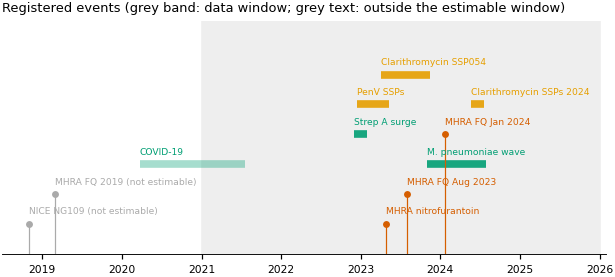

  figure: outputs_antibacterials/figures/figure_table1_event_timeline.png / .pdf


In [9]:
banner("EVENT REGISTER")
EVENTS = pd.DataFrame([
    dict(id="NICE_NG109", date="2018-10-31", end=None, kind="step", category="Guideline", short="NICE NG109",
         label="NICE NG109: lower UTI antimicrobial prescribing guideline",
         status="verified", source="NICE NG109, published 31 Oct 2018. NG111 (acute pyelonephritis) "
         "issued in the same series; confirm its date if cited."),
    dict(id="AMR_NAP_2019", date="2019-01", end=None, kind="context", category="Policy", short="AMR NAP 2019",
         label="UK AMR National Action Plan 2019-2024", status="verified (month)",
         source="HM Government, Jan 2019"),
    dict(id="MHRA_FQ_MAR19", date="2019-03", end=None, kind="step", category="Regulatory", short="MHRA FQ 2019",
         label="MHRA DSU: fluoroquinolone restrictions (disabling, potentially irreversible adverse effects)",
         status="verified (month)", source="MHRA Drug Safety Update, March 2019"),
    dict(id="COVID_RESTRICTIONS", date=COVID_EXCLUDE[0], end=COVID_EXCLUDE[1], kind="exclusion",
         category="Epidemiological", short="COVID-19",
         label="COVID-19 restrictions (first lockdown to roadmap step 4)", status="verified",
         source="UK Government; excluded from every estimation window"),
    dict(id="STREP_A_SURGE", date="2022-12", end="2023-01", kind="pulse", category="Epidemiological",
         short="Strep A surge", label="Group A streptococcus / scarlet fever surge",
         status="period approximate", source="UKHSA surveillance reports, Dec 2022-Jan 2023"),
    dict(id="PENV_SSP", date="2022-12-15", end="2023-05-12", kind="window", category="Supply", short="PenV SSPs",
         label="Phenoxymethylpenicillin SSP040-047: formulation and therapeutic substitution",
         status="verified", source="DHSC 15 Dec 2022 (SSP040-042), 16 Dec 2022 (SSP043-047); "
         "extended to 28 Feb, 31 Mar, 28 Apr, expired after 12 May 2023"),
    dict(id="PENV_SSP_AMEND", date="2023-01-31", end=None, kind="context", category="Supply", short="SSP amendment",
         label="SSP043-047 amended: azithromycin and clarithromycin removed as alternatives",
         status="verified", source="NHSBSA SSP notices, 31 Jan 2023"),
    dict(id="CLARI_SSP053", date="2023-04-06", end="2024-01-12", kind="context", category="Supply",
         short="Clarithromycin SSP053", status="verified",
         label="Clarithromycin SSP053: 125mg/5ml suspension to 250mg/5ml (strength swap within liquids)",
         source="NHSBSA SSP053; issued 6 Apr 2023, extended to 12 Jan 2024. Invisible at molecule level."),
    dict(id="CLARI_SSP054", date="2023-04-06", end="2023-11-17", kind="window", category="Supply",
         short="Clarithromycin SSP054", status="verified",
         label="Clarithromycin SSP054: 250mg/5ml suspension dispensed as 250mg tablets (formulation only)",
         source="NHSBSA SSP054; issued 6 Apr 2023, expired 17 Nov 2023"),
    dict(id="CLARI_SSP_2024", date="2024-05-22", end="2024-07-19", kind="window", category="Supply",
         short="Clarithromycin SSPs 2024", status="verified",
         label="Clarithromycin SSP053/054 reactivated", source="NHSBSA; 22 May 2024, extended to 19 Jul 2024"),
    dict(id="MHRA_NITRO_APR23", date="2023-04-26", end=None, kind="step", category="Regulatory",
         short="MHRA nitrofurantoin", status="verified",
         label="MHRA DSU: nitrofurantoin - reminder of pulmonary and hepatic adverse reactions",
         source="MHRA Drug Safety Update, 26 Apr 2023"),
    dict(id="MHRA_FQ_AUG23", date="2023-08", end=None, kind="step", category="Regulatory", short="MHRA FQ Aug 2023",
         label="MHRA DSU: fluoroquinolones - reminder of disabling, potentially long-lasting effects",
         status="verified (month; day not confirmed - event month coded 0.5)",
         source="MHRA Drug Safety Update, August 2023"),
    dict(id="MHRA_FQ_SEP23", date="2023-09", end=None, kind="context", category="Regulatory", short="MHRA FQ Sep 2023",
         label="MHRA: fluoroquinolone psychiatric reactions (suicidal thoughts) reminder",
         status="verified (month; secondary source)", source="Cited in MHRA/pharmacy press, Jan 2024"),
    dict(id="MHRA_FQ_JAN24", date="2024-01-22", end=None, kind="step_slope", category="Regulatory",
         short="MHRA FQ Jan 2024", status="verified",
         label="MHRA DSU: systemic fluoroquinolones only when other commonly recommended antibiotics are inappropriate",
         source="MHRA Drug Safety Update vol 17 issue 6, 22 Jan 2024"),
    dict(id="MYCOPLASMA_2324", date="2023-11-01", end="2024-07-31", kind="window",
         category="Epidemiological", short="M. pneumoniae wave", status="verified (period approximate)",
         label="Mycoplasma pneumoniae resurgence (pneumonia in children above expected levels)",
         source="UKHSA syndromic surveillance; Todkill et al., Eurosurveillance 2024: elevated from Nov 2023, "
         "peak Mar 2024, persisting into early summer 2024. Treated with macrolides (and doxycycline in "
         "adults), so it overlaps the Jan 2024 fluoroquinolone restriction."),
    dict(id="AMR_NAP_2024", date="2024-05", end=None, kind="context", category="Policy", short="AMR NAP 2024",
         label="UK AMR National Action Plan 2024-2029 published", status="to confirm (reported 8 May 2024)",
         source="HM Government"),
    dict(id="OLD_NG109_APR19", date="2019-04", end=None, kind="dropped", category="Guideline", short="",
         label="'NG109 (Apr 2019)' in the previous notebook", status="date error",
         source="NG109 was published 31 Oct 2018 - see NICE_NG109"),
    dict(id="OLD_TARGET_2021", date="2021-04", end=None, kind="dropped", category="Policy", short="",
         label="'NHS AMR TARGET refresh'", status="no primary source identified", source="dropped"),
    dict(id="OLD_UKHSA_NAP_2022", date="2022-01", end=None, kind="dropped", category="Policy", short="",
         label="'UKHSA AMR national action plan milestone'", status="no primary source identified", source="dropped"),
    dict(id="OLD_CQUIN_2023", date="2023-04", end=None, kind="dropped", category="Policy", short="",
         label="'CQUIN 2023/24 IV-to-oral switch'", status="secondary-care scheme",
         source="dropped: does not act on community dispensing"),
    dict(id="OLD_NICE_REVIEW_2023", date="2023-06", end=None, kind="dropped", category="Guideline", short="",
         label="'NICE antimicrobial prescribing review (Jun 2023)'", status="no NICE publication identified",
         source="dropped"),
    dict(id="OLD_CLARI_SSP_SEP23", date="2023-09", end=None, kind="dropped", category="Supply", short="",
         label="'Clarithromycin SSP (Sep 2023)' in the previous notebook", status="date and mechanism error",
         source="SSP053/054 were issued 6 Apr 2023 and are formulation swaps - see CLARI_SSP rows"),
])


def _val(v):
    if v is None:
        return None
    try:
        if pd.isna(v):
            return None
    except (TypeError, ValueError):
        pass
    return v


EV = {r["id"]: {k: _val(v) for k, v in r.items()} for r in EVENTS.to_dict("records")}

ALL_MONTHS = ym_range(STUDY_START, STUDY_END)
_covid = window_exposure(ALL_MONTHS, *COVID_EXCLUDE)
USABLE = [ym for ym, c in zip(ALL_MONTHS, _covid) if c == 0]
USABLE_SET = set(USABLE)


def contiguous_runs(months):
    runs, cur = [], [months[0]]
    for a, b in zip(months[:-1], months[1:]):
        if ym_index(b) == ym_index(a) + 1:
            cur.append(b)
        else:
            runs.append(cur)
            cur = [b]
    runs.append(cur)
    return runs


MAIN_BLOCK = max(contiguous_runs(USABLE), key=len)


def usable_block(anchor, max_pre=ITS_MAX_PRE, max_post=ITS_MAX_POST):
    """Longest run of consecutive usable months around `anchor`, capped at max_pre months before
    it and max_post months from it (inclusive). Empty if the anchor itself is not usable."""
    if anchor not in USABLE_SET:
        return []
    run = next(r for r in contiguous_runs(USABLE) if anchor in r)
    i = run.index(anchor)
    return run[max(0, i - max_pre): i + max_post]


def estimability(ev):
    k = ev["kind"]
    if k in ("context", "dropped", "exclusion"):
        return dict(n_pre=np.nan, n_post=np.nan, estimable="-", reason=k)
    anchor = parse_event_date(ev["date"])[0]
    if anchor < STUDY_START:
        return dict(n_pre=0, n_post=np.nan, estimable="no",
                    reason="precedes the data (%d); extend extracts back to test it" % STUDY_START)
    if anchor > STUDY_END:
        return dict(n_pre=np.nan, n_post=0, estimable="no", reason="after the data")
    block = usable_block(anchor, max_pre=10 ** 4, max_post=10 ** 4)
    n_pre = sum(1 for ym in block if ym < anchor)
    if k in ("window", "pulse"):
        end = parse_event_date(ev["end"] or ev["date"])[0]
        n_post = sum(1 for ym in block if ym > end)
    else:
        n_post = sum(1 for ym in block if ym >= anchor)
    ok = n_pre >= ITS_MIN_PRE and n_post >= ITS_MIN_POST
    return dict(n_pre=n_pre, n_post=n_post, estimable="yes" if ok else "no",
                reason="" if ok else "needs >=%d pre and >=%d post usable months" % (ITS_MIN_PRE, ITS_MIN_POST))


est = pd.DataFrame([estimability(EV[i]) for i in EVENTS.id])
EVENT_TABLE = pd.concat([EVENTS.reset_index(drop=True), est], axis=1)
show = EVENT_TABLE[["id", "date", "end", "kind", "status", "n_pre", "n_post", "estimable", "reason"]]
print(show.to_string(index=False))
save("table1_event_register", EVENT_TABLE)
print("\nUsable months: %d of %d (COVID exclusion removes %d). Main contiguous block: %d-%d (%d months)." %
      (len(USABLE), len(ALL_MONTHS), len(ALL_MONTHS) - len(USABLE), MAIN_BLOCK[0], MAIN_BLOCK[-1], len(MAIN_BLOCK)))

# ---- timeline figure ----------------------------------------------------------
cat_colour = {"Regulatory": OKABE["vermillion"], "Guideline": OKABE["blue"], "Supply": OKABE["orange"],
              "Epidemiological": OKABE["green"], "Policy": OKABE["purple"]}
drawn = EVENT_TABLE[EVENT_TABLE.kind.isin(["step", "step_slope", "window", "pulse", "exclusion"])]
t0 = min(to_dates([STUDY_START])[0], pd.Timestamp(drawn.date.min()[:7] + "-01") - pd.DateOffset(months=3))
fig, ax = plt.subplots(figsize=(180 * MM, 70 * MM))
ax.axvspan(to_dates([STUDY_START])[0], to_dates([STUDY_END])[0] + pd.DateOffset(months=1),
           color="#EEEEEE", zorder=0, label="data window")
for lvl, (_, e) in enumerate(drawn.sort_values("date").iterrows()):
    y = 1 + (lvl % 6)
    col = cat_colour.get(e.category, OKABE["grey"]) if e.estimable in ("yes", "-") else "#AAAAAA"
    start = pd.Timestamp(e.date if len(e.date) > 7 else e.date + "-01")
    if e.kind in ("window", "pulse", "exclusion"):
        end_s = EV[e.id]["end"] or e.date
        end = pd.Timestamp(end_s if len(end_s) > 7 else end_s + "-28")
        ax.plot([start, end], [y, y], lw=5, color=col, solid_capstyle="butt",
                alpha=0.35 if e.kind == "exclusion" else 0.9)
    else:
        ax.plot([start, start], [0, y], lw=0.8, color=col)
        ax.plot(start, y, "o", ms=3.5, color=col)
    ax.text(start, y + 0.28, e.short + ("" if e.estimable in ("yes", "-") else " (not estimable)"),
            fontsize=6, color=col, ha="left", va="bottom")
ax.set_ylim(0, 7.8)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlim(t0, to_dates([STUDY_END])[0] + pd.DateOffset(months=2))
year_axis(ax)
ax.set_title("Registered events (grey band: data window; grey text: outside the estimable window)", loc="left")
_save(fig, "figure_table1_event_timeline")

## 6. Descriptive composition and seasonality


COMPOSITION BY UNIT
                   unit                  cls  cohort    items  pct_all  pct_first12  pct_last12  pct_liquid  change_pp
            Amoxicillin          Penicillins    True 46403317    26.23        25.12       24.05       24.61      -1.07
           Co-amoxiclav          Penicillins    True  6749888     3.82         4.17        3.74       11.94      -0.44
Phenoxymethylpenicillin          Penicillins    True 13748162     7.77         5.85        8.37       28.58       2.52
         Flucloxacillin          Penicillins    True 19362092    10.95        11.98       11.29       10.46      -0.69
              Cefalexin       Cephalosporins    True  4425438     2.50         2.63        2.59       12.54      -0.04
         Clarithromycin           Macrolides    True  9789682     5.53         5.31        5.41       13.54       0.10
           Erythromycin           Macrolides    True  2641720     1.49         1.76        1.13       32.18      -0.63
           Azithromycin    

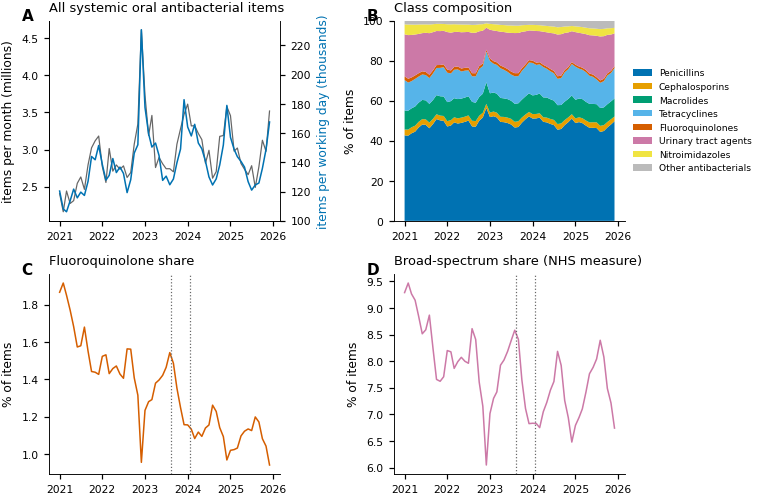

  figure: outputs_antibacterials/figures/figure_descriptive_composition.png / .pdf

SEASONALITY (STL, main usable block)
                                   series  peak_month  trough_month  peak_vs_trough_pct  seasonal_strength
items per working day: All antibacterials          12             8              45.133              0.784
                  share: Fluoroquinolones           8            12              19.385              0.560
                       share: Amoxicillin          12             8              71.819              0.913
           share: Phenoxymethylpenicillin           3             8              37.934              0.668
                    share: Clarithromycin           3             8              12.256              0.432
                       share: Doxycycline           1             8              38.430              0.920
                    share: Nitrofurantoin           8            12              47.297              0.742
                    sha

In [10]:
banner("COMPOSITION BY UNIT")
sc = presc[presc.IN_SCOPE]
g = sc.assign(LIQ=np.where(sc.FORM == "oral_liquid", sc.ITEMS, 0.0)).groupby("UNIT")[["ITEMS", "LIQ"]].sum()
first12, last12 = nat.index[:12], nat.index[-12:]
rows = []
for u in UNIT_ORDER:
    c = item_col(u)
    rows.append(dict(unit=u, cls=UNIT_CLASS[u], cohort=u in COHORT, items=int(nat[c].sum()),
                     pct_all=100 * nat[c].sum() / nat.TOTAL_ITEMS.sum(),
                     pct_first12=100 * nat.loc[first12, c].sum() / nat.loc[first12, "TOTAL_ITEMS"].sum(),
                     pct_last12=100 * nat.loc[last12, c].sum() / nat.loc[last12, "TOTAL_ITEMS"].sum(),
                     pct_liquid=100 * g.LIQ.get(u, 0) / g.ITEMS.get(u, np.nan) if g.ITEMS.get(u, 0) else np.nan))
comp = pd.DataFrame(rows)
comp["change_pp"] = comp.pct_last12 - comp.pct_first12
print(comp.round(2).to_string(index=False))
save("table_s1_unit_composition", comp)

fig, axes = plt.subplots(2, 2, figsize=(180 * MM, 120 * MM))
d = to_dates(nat.index)
ax = axes[0, 0]
ax.plot(d, nat.TOTAL_ITEMS / 1e6, color=OKABE["grey"], lw=0.8, label="items")
ax2 = ax.twinx()
ax2.plot(d, nat.TOTAL_ITEMS / nat.WORKING_DAYS / 1e3, color=OKABE["blue"], label="per working day")
ax.set_ylabel("items per month (millions)")
ax2.set_ylabel("items per working day (thousands)", color=OKABE["blue"])
ax2.spines["right"].set_visible(True)
ax.set_title("All systemic oral antibacterial items", loc="left")
_label(ax, "A")
ax = axes[0, 1]
cls_sh = np.vstack([nat["ITEMS_CLASS_" + key(c)] / nat.TOTAL_ITEMS * 100 for c in CLASS_ORDER])
ax.stackplot(d, cls_sh, colors=[CLASS_COLOURS[c] for c in CLASS_ORDER], labels=CLASS_ORDER, lw=0)
ax.set_ylim(0, 100)
ax.set_ylabel("% of items")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=6)
ax.set_title("Class composition", loc="left")
_label(ax, "B")
for ax, (col, title, colour, letter) in zip(axes[1], [("ITEMS_FQ", "Fluoroquinolone share", OKABE["vermillion"], "C"),
                                                       ("ITEMS_BROAD", "Broad-spectrum share (NHS measure)", OKABE["purple"], "D")]):
    ax.plot(d, nat[col] / nat.TOTAL_ITEMS * 100, color=colour)
    for eid in ("MHRA_FQ_AUG23", "MHRA_FQ_JAN24"):
        ax.axvline(pd.Timestamp(EV[eid]["date"] if len(EV[eid]["date"]) > 7 else EV[eid]["date"] + "-15"),
                   color=OKABE["grey"], ls=":", lw=0.8)
    ax.set_ylabel("% of items")
    ax.set_title(title, loc="left")
    _label(ax, letter)
for ax in axes.flat:
    year_axis(ax)
fig.tight_layout()
_save(fig, "figure_descriptive_composition")

banner("SEASONALITY (STL, main usable block)")
from statsmodels.tsa.seasonal import STL


def stl_fit(y):
    return STL(pd.Series(np.asarray(y, float)), period=12, robust=True).fit()


def deseasonalise(y):
    return np.asarray(y, float) - stl_fit(y).seasonal.values


SEASONAL_SERIES = [("items_wd", "All antibacterials"), ("share", "Fluoroquinolones"),
                   ("share", "Amoxicillin"), ("share", "Phenoxymethylpenicillin"),
                   ("share", "Clarithromycin"), ("share", "Doxycycline"), ("share", "Nitrofurantoin"),
                   ("share", "Flucloxacillin")]
rows = []
for oc in SEASONAL_SERIES:
    v = series_for(nat.loc[MAIN_BLOCK], oc).values
    y = np.log(v) if oc[0] == "items_wd" else logit(v)
    f = stl_fit(y)
    prof = pd.Series(f.seasonal.values, index=[ym % 100 for ym in MAIN_BLOCK]).groupby(level=0).mean()
    ssi = max(0.0, 1 - np.var(f.resid) / np.var(f.resid + f.seasonal))
    rows.append(dict(series=outcome_label(oc), peak_month=int(prof.idxmax()), trough_month=int(prof.idxmin()),
                     peak_vs_trough_pct=100 * (np.exp(prof.max() - prof.min()) - 1),
                     seasonal_strength=ssi))
seas = pd.DataFrame(rows)
print(seas.round(3).to_string(index=False))
print("(peak_vs_trough_pct is on the ratio scale: items for volume, odds for shares)")
save("table_seasonality", seas)

## 7. Stationarity (Supplementary Table S2)

ADF (null: unit root) and KPSS (null: trend-stationary) on the STL-deseasonalised series,
main usable block. Structural breaks bias ADF towards *not* rejecting, so "unit root" verdicts
for series with a known policy break (fluoroquinolones) should be read with the break tests in
Section 8. The verdicts decide only how the descriptive VAR in Section 11 is specified.

In [11]:
banner("STATIONARITY")
from statsmodels.tsa.stattools import adfuller, kpss


def adf_p(x, reg):
    try:
        return float(adfuller(x, regression=reg, autolag="AIC")[1])
    except Exception:
        return np.nan


def kpss_p(x, reg):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            return float(kpss(x, regression=reg, nlags="auto")[1])
    except Exception:
        return np.nan


def verdict(a, k):
    if a < 0.05 and k > 0.05:
        return "trend-stationary"
    if a >= 0.05 and k <= 0.05:
        return "unit root"
    return "ambiguous"


def transformed(frame, oc, months):
    v = series_for(frame.loc[months], oc).values.astype(float)
    return np.log(v) if oc[0] in ("items", "items_wd", "ddd") else logit(v)


STAT_SERIES = ([("items_wd", "All antibacterials"), ("share", "Fluoroquinolones"),
                ("share", "Broad-spectrum (NHS measure)")] +
               [("share", u) for u in COHORT_ACTIVE] + [("pair", (a, b)) for a, b, _ in KEY_PAIRS])
rows = []
for oc in STAT_SERIES:
    x = deseasonalise(transformed(nat, oc, MAIN_BLOCK))
    a, k = adf_p(x, "ct"), kpss_p(x, "ct")
    rows.append(dict(series=outcome_label(oc), adf_p=a, kpss_p=k, verdict=verdict(a, k),
                     adf_p_diff=adf_p(np.diff(x), "c")))
STATIONARITY = pd.DataFrame(rows)
print(STATIONARITY.round(3).to_string(index=False))
print("\nVerdicts:", STATIONARITY.verdict.value_counts().to_dict())
save("table_s2_stationarity", STATIONARITY)


STATIONARITY
                                                  series  adf_p  kpss_p          verdict  adf_p_diff
               items per working day: All antibacterials  0.105   0.034        unit root       0.000
                                 share: Fluoroquinolones  0.023   0.100 trend-stationary       0.000
                     share: Broad-spectrum (NHS measure)  0.259   0.100        ambiguous       0.000
                                      share: Amoxicillin  0.363   0.013        unit root       0.000
                                     share: Co-amoxiclav  0.186   0.064        ambiguous       0.000
                          share: Phenoxymethylpenicillin  0.043   0.100 trend-stationary       0.000
                                   share: Flucloxacillin  0.005   0.070 trend-stationary       0.000
                                        share: Cefalexin  0.147   0.085        ambiguous       0.000
                                   share: Clarithromycin  0.151   0.100      

## 8. Structural breaks (Results section 1; Supplementary Table S3)

Three methods on the same deseasonalised series (STL, main usable block), each correcting a
specific defect in the previous notebook:

* **OLS-CUSUM** (Ploberger–Krämer) on residuals from a linear trend, scaled by a Newey–West
  long-run variance so that autocorrelation does not masquerade as instability. The null
  distribution is simulated for the exact sample size and design (with a trend regressor the
  limit is not the standard Brownian bridge, so textbook critical values do not apply).
* **Bai–Perron**: global least-squares segmentation by dynamic programming, piecewise linear
  trend, minimum segment 15% of the sample, 0–3 breaks, **number of breaks chosen by BIC**
  (LWZ reported alongside). The old code compared raw RSS across break counts, which always
  selects the maximum. Break-date 95% intervals from a moving-block residual bootstrap (999 resamples, six-month blocks).
* **PELT** on the same piecewise-linear cost with a BIC-type penalty, 3σ²·log(n), σ estimated
  robustly (MAD) from the residuals of the BIC-selected Bai–Perron fit (first differences
  understate σ when errors are autocorrelated). The optimum is computed exactly and
  cross-checked against `ruptures`. The old penalty was on the raw-count scale, hence 16–17
  "breaks" in 60 months.
* The two Strep A surge months are interpolated before detection: a known two-month shock is not
  a regime change (it is analysed month by month in Section 11).

A break is **concordant** when Bai–Perron and PELT place it within ±2 months. It is linked to a
registered event only when the event date lies inside the Bai–Perron bootstrap interval. The
nearest event is reported, but proximity alone is not evidence of causation.


STRUCTURAL BREAKS
                                                  series cusum_p cusum_q  bp_breaks_bic                  bp_dates                                                    bp_95ci                         pelt_dates                concordant                                                                                                                   events_in_ci
                                 share: Fluoroquinolones   0.112   0.160              3 2022-11; 2023-07; 2024-06 2022-10 to 2022-11; 2023-07 to 2023-09; 2024-05 to 2024-07          2022-11; 2023-07; 2024-06 2022-11; 2023-07; 2024-06                                                                                            none; MHRA_FQ_AUG23; CLARI_SSP_2024
                     share: Broad-spectrum (NHS measure)   0.427   0.469              3 2022-12; 2023-08; 2024-06 2022-12 to 2022-12; 2023-08 to 2023-09; 2024-06 to 2024-06          2022-12; 2023-08; 2024-06 2022-12; 2023-08; 2024-06                          

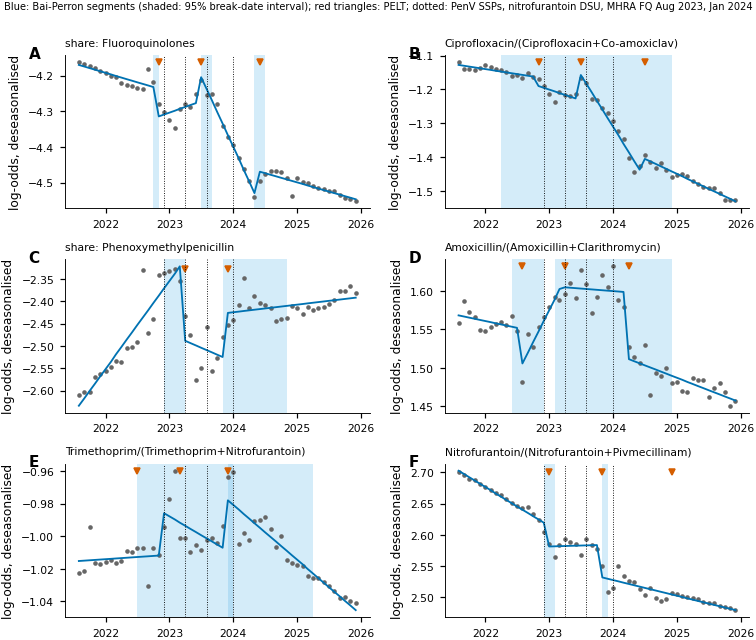

  figure: outputs_antibacterials/figures/figure2_structural_breaks.png / .pdf


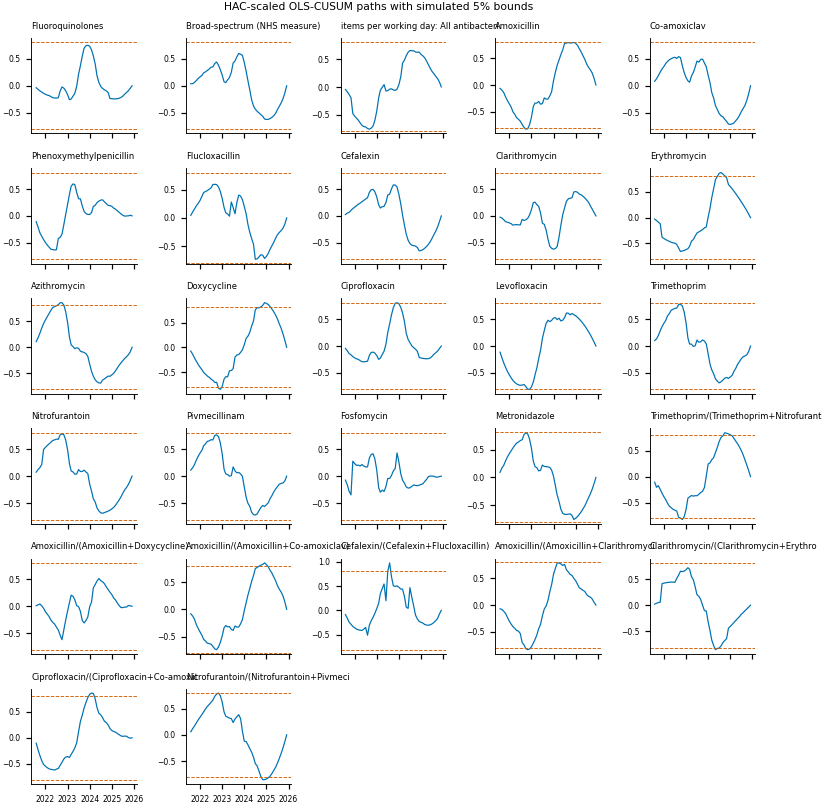

  figure: outputs_antibacterials/figures/supplementary/figure_s_cusum_paths.png / .pdf


In [12]:
banner("STRUCTURAL BREAKS")


def _seg_cost(y, min_size):
    """SSR of a linear-trend fit for every segment [a, b); inf below the minimum length."""
    y = np.asarray(y, float)
    n = len(y)
    yc = y - y.mean()
    t = np.arange(n, dtype=float) - (n - 1) / 2

    def cs(v):
        return np.concatenate([[0.0], np.cumsum(v)])

    P0, P1, P2, Py, Pty, Pyy = cs(np.ones(n)), cs(t), cs(t * t), cs(yc), cs(t * yc), cs(yc * yc)
    a, b = np.arange(n + 1)[:, None], np.arange(n + 1)[None, :]
    S0, S1, S2 = P0[b] - P0[a], P1[b] - P1[a], P2[b] - P2[a]
    Sy, Sty, Syy = Py[b] - Py[a], Pty[b] - Pty[a], Pyy[b] - Pyy[a]
    with np.errstate(divide="ignore", invalid="ignore"):
        det = S0 * S2 - S1 * S1
        b0 = (S2 * Sy - S1 * Sty) / det
        b1 = (S0 * Sty - S1 * Sy) / det
        ssr = Syy - b0 * Sy - b1 * Sty
    ok = (b - a) >= max(min_size, 3)
    return np.where(ok & np.isfinite(ssr), np.maximum(ssr, 0.0), np.inf)


def _dp(cost, m):
    """Exact optimal partition of the whole series into m + 1 segments."""
    n = cost.shape[0] - 1
    F = np.full((m + 1, n + 1), np.inf)
    arg = np.zeros((m + 1, n + 1), dtype=int)
    F[0] = cost[0]
    for k in range(1, m + 1):
        for e in range(1, n + 1):
            v = F[k - 1, :e] + cost[:e, e]
            j = int(np.argmin(v))
            F[k, e], arg[k, e] = v[j], j
    br, e = [], n
    for k in range(m, 0, -1):
        e = arg[k, e]
        br.append(int(e))
    return sorted(br), float(F[m, n])


def bai_perron(y, max_breaks=BREAK_MAX, trim=BREAK_TRIM):
    y = np.asarray(y, float)
    n = len(y)
    h = max(int(np.ceil(trim * n)), 6)
    cost = _seg_cost(y, h)
    rows = []
    for m in range(max_breaks + 1):
        if (m + 1) * h > n:
            break
        br, ssr = ([], float(cost[0, n])) if m == 0 else _dp(cost, m)
        if not np.isfinite(ssr) or ssr <= 0:
            break
        p = 2 * (m + 1) + m
        rows.append(dict(m=m, breaks=br, ssr=ssr, bic=n * np.log(ssr / n) + p * np.log(n),
                         lwz=n * np.log(ssr / (n - p)) + p * 0.299 * np.log(n) ** 2.1))
    tab = pd.DataFrame(rows)
    best = tab.loc[tab.bic.idxmin()]
    return tab, int(best.m), list(best["breaks"]), h


def piecewise_fit(y, breaks):
    y = np.asarray(y, float)
    n = len(y)
    t = np.arange(n, dtype=float)
    fitted = np.empty(n)
    bounds = [0] + list(breaks) + [n]
    for a, b in zip(bounds[:-1], bounds[1:]):
        X = np.column_stack([np.ones(b - a), t[a:b]])
        fitted[a:b] = X @ np.linalg.lstsq(X, y[a:b], rcond=None)[0]
    return fitted


def bp_break_ci(y, breaks, h, n_boot=N_BOOT_BREAK, block=6, seed=RANDOM_SEED):
    """Percentile intervals for break dates from a moving-block bootstrap of residuals."""
    if not breaks:
        return []
    y = np.asarray(y, float)
    n = len(y)
    fitted = piecewise_fit(y, breaks)
    resid = y - fitted
    rng = np.random.default_rng(seed)
    draws = np.empty((n_boot, len(breaks)))
    nb = int(np.ceil(n / block))
    for r in range(n_boot):
        starts = rng.integers(0, n - block + 1, size=nb)
        e = np.concatenate([resid[s:s + block] for s in starts])[:n]
        br, _ = _dp(_seg_cost(fitted + e - e.mean(), h), len(breaks))
        draws[r] = br
    lo = np.floor(np.percentile(draws, 2.5, axis=0)).astype(int)
    hi = np.ceil(np.percentile(draws, 97.5, axis=0)).astype(int)
    return list(zip(lo, hi))


_CUSUM_NULL = {}


def _lrv_rows(E, L):
    E = E - E.mean(axis=1, keepdims=True)
    n = E.shape[1]
    s = (E * E).sum(axis=1) / n
    for lag in range(1, L + 1):
        s = s + 2 * (1 - lag / (L + 1)) * (E[:, lag:] * E[:, :-lag]).sum(axis=1) / n
    return np.maximum(s, 1e-12)


def cusum_hac(y, n_sim=20000):
    y = np.asarray(y, float)
    n = len(y)
    X = np.column_stack([np.ones(n), np.arange(n)])
    M = np.eye(n) - X @ np.linalg.pinv(X)
    e = M @ y
    L = max(1, int(np.floor(4 * (n / 100) ** (2 / 9))))
    path = np.cumsum(e) / np.sqrt(_lrv_rows(e[None, :], L)[0] * n)
    stat = float(np.max(np.abs(path)))
    if n not in _CUSUM_NULL:
        rng = np.random.default_rng(RANDOM_SEED)
        E = rng.standard_normal((n_sim, n)) @ M
        P = np.cumsum(E, axis=1) / np.sqrt(_lrv_rows(E, L)[:, None] * n)
        _CUSUM_NULL[n] = np.sort(np.max(np.abs(P), axis=1))
    null = _CUSUM_NULL[n]
    p = (np.sum(null >= stat) + 1) / (len(null) + 1)
    return stat, float(p), float(np.quantile(null, 0.95)), path


def _penalised_partition(y, min_size, pen):
    n = len(y)
    cost = _seg_cost(y, min_size)
    F = np.full(n + 1, np.inf)
    F[0] = -pen
    last = np.zeros(n + 1, dtype=int)
    for e in range(1, n + 1):
        v = F[:e] + cost[:e, e] + pen
        j = int(np.argmin(v))
        F[e], last[e] = v[j], j
    br, e = [], n
    while e > 0:
        j = int(last[e])
        if j > 0:
            br.append(j)
        e = j
    return sorted(br)


def _partition_cost(y, br, min_size, pen):
    cost = _seg_cost(y, min_size)
    b = [0] + list(br) + [len(y)]
    return float(sum(cost[a, c] for a, c in zip(b[:-1], b[1:])) + pen * len(br))


def pelt(y, min_size, mult=PELT_BIC_MULTIPLIER, ref_breaks=None):
    """Penalised optimal partition (the objective PELT solves exactly), cross-checked against ruptures.
    Noise scale from the residuals of the BIC-selected Bai-Perron fit: first differences would
    understate it when errors are autocorrelated, and the penalty would then admit spurious breaks."""
    y = np.asarray(y, float)
    n = len(y)
    if ref_breaks is None:
        ref_breaks = bai_perron(y)[2]
    r = y - piecewise_fit(y, ref_breaks)
    sigma = 1.4826 * np.median(np.abs(r - np.median(r)))
    pen = mult * 3 * sigma ** 2 * np.log(n)
    exact = _penalised_partition(y, min_size, pen)
    try:
        import ruptures as rpt
        t = np.arange(n, dtype=float)
        sig = np.column_stack([y, np.ones(n), t - t.mean()])
        bk = rpt.Pelt(model="linear", min_size=min_size, jump=1).fit(sig).predict(pen=pen)
        rbr = [int(b) for b in bk if b < n]
        if rbr == exact:
            note = "ruptures identical"
        else:
            note = "ruptures differs (penalised cost %.4f vs optimum %.4f)" % (
                _partition_cost(y, rbr, min_size, pen), _partition_cost(y, exact, min_size, pen))
    except ImportError:
        note = "ruptures not installed"
    return exact, pen, note


def event_span(eid):
    """(first exposed month, first month mostly exposed). A break found in the month after a late-month
    event (e.g. Feb 2024 for 22 Jan 2024) is still that event's break."""
    first = event_month(eid)
    d = str(EV[eid]["date"])
    if len(d) > 7:
        ts = pd.Timestamp(d)
        frac = (ts.days_in_month - ts.day + 1) / ts.days_in_month
        return first, (first if frac >= 0.5 else ym_add(first, 1))
    return first, ym_add(first, 1)


def span_distance(ym, span):
    i, a, b = ym_index(ym), ym_index(span[0]), ym_index(span[1])
    return 0 if a <= i <= b else (i - b if i > b else i - a)


def ym_str(ym):
    return "%d-%02d" % (int(ym) // 100, int(ym) % 100)


def event_month(eid):
    return parse_event_date(EV[eid]["date"])[0]


MODELLED_EVENTS = [e for e in EVENTS.id if EV[e]["kind"] in ("step", "step_slope", "window", "pulse")]
BREAK_MASK_MONTHS = [ym for ym in ym_range(event_month("STREP_A_SURGE"),
                                           parse_event_date(EV["STREP_A_SURGE"]["end"])[0]) if ym in MAIN_BLOCK]


def break_series(oc):
    """Deseasonalised series with the Strep A surge months linearly interpolated, so a known
    two-month shock is not reported as a regime change (it is analysed in Section 11)."""
    y = deseasonalise(transformed(nat, oc, MAIN_BLOCK)).copy()
    idx = [MAIN_BLOCK.index(m) for m in BREAK_MASK_MONTHS]
    if idx:
        keep = np.setdiff1d(np.arange(len(y)), idx)
        y[idx] = np.interp(idx, keep, y[keep])
    return y
BREAK_SERIES = ([("share", "Fluoroquinolones"), ("share", "Broad-spectrum (NHS measure)"),
                 ("items_wd", "All antibacterials")] + [("share", u) for u in COHORT_ACTIVE] +
                [("pair", (a, b)) for a, b, _ in KEY_PAIRS])
BREAK_FITS, rows = {}, []
for oc in BREAK_SERIES:
    y = break_series(oc)
    stat, p, crit, path = cusum_hac(y)
    tab, m_bic, br, h = bai_perron(y)
    m_lwz = int(tab.loc[tab.lwz.idxmin(), "m"])
    ci = bp_break_ci(y, br, h)
    pel, pen, method = pelt(y, h, ref_breaks=br)
    concord = [b for b in br if any(abs(b - q) <= BREAK_TOL for q in pel)]
    in_ci, nearest = [], []
    for b, (lo, hi) in zip(br, ci):
        ev_in = [e for e in MODELLED_EVENTS if event_span(e)[0] <= MAIN_BLOCK[hi] and event_span(e)[1] >= MAIN_BLOCK[lo]]
        in_ci.append("/".join(ev_in) if ev_in else "none")
        dist = {e: span_distance(MAIN_BLOCK[b], event_span(e)) for e in MODELLED_EVENTS}
        e_near = min(dist, key=lambda k: abs(dist[k]))
        nearest.append("%s (%+d mo)" % (e_near, dist[e_near]))
    BREAK_FITS[outcome_label(oc)] = dict(oc=oc, y=y, br=br, ci=ci, pel=pel, path=path, crit=crit)
    rows.append(dict(series=outcome_label(oc), cusum_stat=stat, cusum_p=p, bp_breaks_bic=m_bic,
                     bp_breaks_lwz=m_lwz,
                     bp_dates="; ".join(ym_str(MAIN_BLOCK[b]) for b in br) or "-",
                     bp_95ci="; ".join("%s to %s" % (ym_str(MAIN_BLOCK[lo]), ym_str(MAIN_BLOCK[hi])) for lo, hi in ci) or "-",
                     pelt_dates="; ".join(ym_str(MAIN_BLOCK[b]) for b in pel) or "-",
                     concordant="; ".join(ym_str(MAIN_BLOCK[b]) for b in concord) or "-",
                     events_in_ci="; ".join(in_ci) or "-", nearest_event="; ".join(nearest) or "-",
                     pelt_method=method))
BREAKS = pd.DataFrame(rows)
BREAKS["cusum_q"] = multipletests(BREAKS.cusum_p, method="fdr_bh")[1]
cols = ["series", "cusum_p", "cusum_q", "bp_breaks_bic", "bp_dates", "bp_95ci", "pelt_dates", "concordant", "events_in_ci"]
print(BREAKS[cols].to_string(index=False, formatters={"cusum_p": "{:.3f}".format, "cusum_q": "{:.3f}".format}))
print("\nPELT: exact penalised partition; ruptures cross-check: %d identical, %d different" %
      (BREAKS.pelt_method.eq("ruptures identical").sum(), (~BREAKS.pelt_method.eq("ruptures identical")).sum()))
diff_ = BREAKS[~BREAKS.pelt_method.eq("ruptures identical")]
if len(diff_):
    print(diff_[["series", "pelt_method"]].to_string(index=False))
print("Series with CUSUM instability (BH q < 0.05): %d of %d" % ((BREAKS.cusum_q < 0.05).sum(), len(BREAKS)))
save("table_s3_structural_breaks", BREAKS)
RESULTS["breaks"] = BREAKS

# ---- Figure: breaks in six key series -----------------------------------------
KEY_BREAK_SERIES = [("share", "Fluoroquinolones"), ("pair", ("Ciprofloxacin", "Co-amoxiclav")),
                    ("share", "Phenoxymethylpenicillin"), ("pair", ("Amoxicillin", "Clarithromycin")),
                    ("pair", ("Trimethoprim", "Nitrofurantoin")), ("pair", ("Nitrofurantoin", "Pivmecillinam"))]
fig, axes = plt.subplots(3, 2, figsize=(180 * MM, 150 * MM))
d = to_dates(MAIN_BLOCK)
for ax, oc, letter in zip(axes.flat, KEY_BREAK_SERIES, "ABCDEF"):
    f = BREAK_FITS.get(outcome_label(oc))
    if f is None:
        ax.set_visible(False)
        continue
    ax.plot(d, f["y"], "o", ms=2, color=OKABE["grey"])
    ax.plot(d, piecewise_fit(f["y"], f["br"]), color=OKABE["blue"], lw=1.2)
    for b, (lo, hi) in zip(f["br"], f["ci"]):
        ax.axvspan(d[lo], d[min(hi, len(d) - 1)], color=OKABE["sky"], alpha=0.25, lw=0)
    for b in f["pel"]:
        ax.plot(d[b], np.nanmax(f["y"]), "v", ms=4, color=OKABE["vermillion"])
    for e in ("PENV_SSP", "MHRA_NITRO_APR23", "MHRA_FQ_AUG23", "MHRA_FQ_JAN24"):
        ax.axvline(to_dates([event_month(e)])[0], color=OKABE["black"], ls=":", lw=0.6)
    ax.set_title(outcome_label(oc).replace("pair share ", ""), loc="left", fontsize=7)
    ax.set_ylabel("log-odds, deseasonalised")
    year_axis(ax)
    _label(ax, letter)
fig.suptitle("Blue: Bai-Perron segments (shaded: 95% break-date interval); red triangles: PELT; "
             "dotted: PenV SSPs, nitrofurantoin DSU, MHRA FQ Aug 2023, Jan 2024", fontsize=6.5, y=1.0)
fig.tight_layout()
_save(fig, "figure2_structural_breaks")

n = len(BREAK_FITS)
ncol = 5
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(180 * MM, 32 * MM * nrow), sharex=True)
for ax, (lab, f) in zip(axes.flat, BREAK_FITS.items()):
    ax.plot(d, f["path"], color=OKABE["blue"], lw=0.8)
    ax.axhline(f["crit"], color=OKABE["vermillion"], lw=0.6, ls="--")
    ax.axhline(-f["crit"], color=OKABE["vermillion"], lw=0.6, ls="--")
    ax.set_title(lab.replace("pair share ", "").replace("share: ", "")[:38], fontsize=5.5, loc="left")
    ax.tick_params(labelsize=5)
    year_axis(ax)
for ax in list(axes.flat)[n:]:
    ax.set_visible(False)
fig.suptitle("HAC-scaled OLS-CUSUM paths with simulated 5% bounds", fontsize=7)
fig.tight_layout()
_save(fig, "figure_s_cusum_paths", supplementary=True)

## 9. Interrupted time series engine

Segmented regression on one national monthly series:

  *y*ₜ = β₀ + β₁·t + Σₖ Fourier(month) + [log working days] + Σ event terms + Σ nuisance terms + εₜ

* **Outcome scale.** Composition outcomes (a unit's share of all antibacterial items; pair shares)
  on the log-odds scale, so 100·(e^β − 1) is the % change in the odds of the share (≈ % change
  in the share when it is small). Volume outcomes as log items with log working days as a
  covariate.
* **Window.** The longest run of usable months around the event: up to 36 months before and 36
  after, never crossing the COVID-19 exclusion. A single linear trend is not forced through five
  years.
* **Errors.** Newey–West (6 lags); Breusch–Godfrey test reported for every model.
* **Absolute effects.** Fitted minus counterfactual (event terms set to zero), summed over exposed
  months, in items; 95% intervals by drawing coefficients from their HAC sampling distribution.
  For share models the counterfactual share is multiplied by the observed denominator
  (10,000 draws).
* **Placebo-date scan.** The same model (without the event terms) is refitted with a step + slope
  at every candidate month (≥12 months from the start, ≥6 from the end). `placebo_p` is the
  fraction of candidate dates whose |t| for the step equals or exceeds the true date's; `scan_best`
  is the date the data prefer (minimum AIC). An effect that is unremarkable within its own scan
  is a feature of the series, not of the policy.
* **Guards.** Events that are all-pre or all-post inside the window are not entered (defect A3);
  a rank-deficient design raises an error instead of being solved by pseudo-inverse.

In [13]:
import zlib
from statsmodels.stats.diagnostic import acorr_breusch_godfrey


def _seed(tag):
    return RANDOM_SEED + zlib.crc32(str(tag).encode()) % 1000003


def event_terms(ev_id, yms):
    ev, yms = EV[ev_id], list(yms)
    cols = {}
    if ev["kind"] in ("step", "step_slope"):
        x = step_exposure(yms, ev["date"])
        if x.max() == 0 or x.min() > 0:
            return {}
        cols["STEP_" + ev_id] = x
        if ev["kind"] == "step_slope":
            e0 = int(np.argmax(x > 0))
            cols["SLOPE_" + ev_id] = np.maximum(0, np.arange(len(yms)) - e0).astype(float)
    elif ev["kind"] == "window":
        x = window_exposure(yms, ev["date"], ev["end"])
        if x.max() > 0 and x.min() == 0:
            cols["WIN_" + ev_id] = x
    elif ev["kind"] == "pulse":
        s, e = event_month(ev_id), parse_event_date(ev["end"] or ev["date"])[0]
        for ym in ym_range(s, e):
            if ym in yms:
                cols["PULSE_%s_%d" % (ev_id, ym)] = (np.array(yms) == ym).astype(float)
    return cols


def its_design(yms, kind, primary, nuisance, extra=None, harmonics=FOURIER_HARMONICS, covars=None):
    yms = list(yms)
    n = len(yms)
    X = pd.DataFrame({"const": np.ones(n), "T": np.arange(n, dtype=float)})
    cm = np.array([ym % 100 for ym in yms])
    for h in range(1, harmonics + 1):
        X["SIN%d" % h] = np.sin(2 * np.pi * h * cm / 12)
        X["COS%d" % h] = np.cos(2 * np.pi * h * cm / 12)
    if kind == "log":
        X["LOG_WD"] = np.log([working_days(ym) for ym in yms])
    prim = []
    for ev in primary:
        for c, v in event_terms(ev, yms).items():
            X[c] = v
            prim.append(c)
    for ev in nuisance:
        if ev in primary:
            continue
        for c, v in event_terms(ev, yms).items():
            if c not in X.columns:
                X[c] = v
    for c, v in (extra or {}).items():
        X[c] = np.asarray(v, float)
        prim.append(c)
    for c, v in (covars or {}).items():      # covariates: adjusted for, never treated as effects
        X[c] = np.asarray(v, float)
    rank = np.linalg.matrix_rank(X.values)
    if rank < X.shape[1]:
        raise ValueError("Rank-deficient ITS design (%d < %d): %s" % (rank, X.shape[1], ", ".join(X.columns)))
    return X, prim


def fit_its(y, X, nw=NW_MAXLAGS):
    y = np.asarray(y, float)
    ols = sm.OLS(y, X).fit()
    hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw, "use_correction": True})
    try:
        bg = float(acorr_breusch_godfrey(ols, nlags=min(BG_LAGS, max(1, len(y) // 5)))[1])
    except Exception:
        bg = np.nan
    return hac, ols, bg


def simulate_effect(hac, X, prim, kind, totals=None, n_sim=N_SIM, seed=RANDOM_SEED):
    beta = np.asarray(hac.params, float)
    V = np.asarray(hac.cov_params(), float)
    Xc = X.copy()
    Xc[prim] = 0.0
    Xf, Xc = X.values, Xc.values
    mask = X[prim].abs().sum(axis=1).values > 0
    smear = float(np.mean(np.exp(np.asarray(hac.resid))))

    def diff(bm):
        ef, ec = Xf @ bm, Xc @ bm
        if kind == "logit":
            return (expit(ef) - expit(ec)) * totals[:, None]
        return smear * (np.exp(ef) - np.exp(ec))

    rng = np.random.default_rng(seed)
    draws = diff(rng.multivariate_normal(beta, V, size=n_sim, method="svd").T)[mask].sum(axis=0)
    point = diff(beta[:, None])[:, 0]
    return dict(n_months=int(mask.sum()), point=float(point[mask].sum()), low=float(np.percentile(draws, 2.5)),
                high=float(np.percentile(draws, 97.5)), draws=draws, monthly=point)


def placebo_scan(y, block, kind, nuisance, true_ym, harmonics=FOURIER_HARMONICS, nw=NW_MAXLAGS, covars=None):
    rows, n = [], len(block)
    for i in range(ITS_MIN_PRE, n - ITS_MIN_POST + 1):
        step = (np.arange(n) >= i).astype(float)
        slope = np.maximum(0, np.arange(n) - i).astype(float)
        try:
            X, _ = its_design(block, kind, [], nuisance, {"STEP_SCAN": step, "SLOPE_SCAN": slope}, harmonics, covars)
        except ValueError:
            continue
        hac, ols, _ = fit_its(y, X, nw)
        rows.append(dict(ym=block[i], t_step=float(hac.tvalues["STEP_SCAN"]),
                         beta_step=float(hac.params["STEP_SCAN"]), aic=float(ols.aic)))
    sc = pd.DataFrame(rows)
    if sc.empty or true_ym not in set(sc.ym):
        return dict(table=sc, p=np.nan, best=None, t_true=np.nan)
    t_true = abs(float(sc.loc[sc.ym == true_ym, "t_step"].iloc[0]))
    return dict(table=sc, p=float((sc.t_step.abs() >= t_true).mean()),
                best=int(sc.loc[sc.aic.idxmin(), "ym"]), t_true=t_true)


def _term_info(term):
    for pre, lab in (("STEP_", "level change"), ("SLOPE_", "slope change per month"),
                     ("WIN_", "mean shift during window"), ("PULSE_", "month effect"), ("M_", "month effect")):
        if term.startswith(pre):
            return term[len(pre):], lab
    return term, ""


ITS_FITS, ITS_ROWS, ITS_SKIPPED, ITS_NUISANCE_ROWS = {}, [], [], []


def _skip(model_id, family, outcome, reason):
    ITS_SKIPPED.append(dict(model=model_id, family=family, outcome=outcome_label(outcome), reason=reason))
    print("  skipped %-30s %s" % (model_id, reason))
    return None


def run_its(model_id, outcome, kind, primary, nuisance=(), anchor=None, family="", frame=None,
            extra=None, block=None, nw=None, scan=True, harmonics=None, store=True, covars=None):
    frame = nat if frame is None else frame
    nw = NW_MAXLAGS if nw is None else nw
    harmonics = FOURIER_HARMONICS if harmonics is None else harmonics
    anchor = event_month(primary[-1]) if anchor is None else anchor
    block = usable_block(anchor) if block is None else block
    if not block:
        why = estimability(EV[primary[-1]])["reason"] if primary else "anchor outside the usable data"
        return _skip(model_id, family, outcome, "not estimable: " + why)
    yv = series_for(frame.loc[block], outcome).values.astype(float)
    if kind == "logit" and ((yv <= 0) | (yv >= 1) | ~np.isfinite(yv)).any():
        return _skip(model_id, family, outcome, "share of 0 or 1 in some month")
    if kind == "log" and ((yv <= 0) | ~np.isfinite(yv)).any():
        return _skip(model_id, family, outcome, "zero in some month")
    y = logit(yv) if kind == "logit" else np.log(yv)
    X, prim = its_design(block, kind, primary, nuisance, extra, harmonics, covars)
    if not prim:
        return _skip(model_id, family, outcome, "no event term varies inside the window")
    exposed = X[prim].abs().sum(axis=1).values > 0
    n_pre = int(np.argmax(exposed))
    n_post = len(block) - n_pre
    if n_pre < ITS_MIN_PRE or n_post < ITS_MIN_POST:
        return _skip(model_id, family, outcome, "only %d pre / %d post months" % (n_pre, n_post))
    hac, ols, bg = fit_its(y, X, nw)
    totals = None
    if kind == "logit":
        k_o, what = outcome
        if k_o == "pair":
            totals = (frame.loc[block, item_col(what[0])] + frame.loc[block, item_col(what[1])]).values.astype(float)
        elif k_o == "solid_fraction":
            totals = frame.loc[block, item_col(what)].values.astype(float)
        else:
            totals = frame.loc[block, "TOTAL_ITEMS"].values.astype(float)
    eff = simulate_effect(hac, X, prim, kind, totals, seed=_seed(model_id))
    sc = placebo_scan(y, block, kind, nuisance, anchor, harmonics, nw, covars) if scan else None
    fit = dict(model=model_id, family=family, hac=hac, ols=ols, X=X, y=y, yv=yv, block=block, prim=prim,
               kind=kind, outcome=outcome, eff=eff, scan=sc, totals=totals, bg=bg, n_pre=n_pre, n_post=n_post)
    if store:
        ITS_FITS[model_id] = fit
        ci = hac.conf_int()
        for c in X.columns:      # nuisance event terms: reported so nothing is hidden in the model
            if c in prim or not c.startswith(("STEP_", "SLOPE_", "WIN_", "PULSE_")):
                continue
            b_n = float(hac.params[c])
            lo_n, hi_n = (float(v) for v in ci.loc[c])
            ITS_NUISANCE_ROWS.append(dict(family=family, model=model_id, outcome=outcome_label(outcome),
                                          term=c, pct=100 * (np.exp(b_n) - 1), pct_low=100 * (np.exp(lo_n) - 1),
                                          pct_high=100 * (np.exp(hi_n) - 1), p=float(hac.pvalues[c])))
        for c in prim:
            b = float(hac.params[c])
            lo, hi = (float(v) for v in ci.loc[c])
            ITS_ROWS.append(dict(family=family, model=model_id, outcome=outcome_label(outcome), scale=kind,
                                 term=c, effect=_term_info(c)[1],
                                 window="%s to %s" % (ym_str(block[0]), ym_str(block[-1])),
                                 n_pre=n_pre, n_post=n_post, beta=b, se=float(hac.bse[c]),
                                 p=float(hac.pvalues[c]), pct=100 * (np.exp(b) - 1),
                                 pct_low=100 * (np.exp(lo) - 1), pct_high=100 * (np.exp(hi) - 1),
                                 model_abs_items=eff["point"], model_abs_low=eff["low"],
                                 model_abs_high=eff["high"], abs_months=eff["n_months"], bg_p=bg,
                                 placebo_p=sc["p"] if sc else np.nan,
                                 scan_best=ym_str(sc["best"]) if sc and sc["best"] else ""))
    return fit


def trend_annual(fit, term="T"):
    """Underlying trend as % per year on the model's ratio scale (odds for shares, items for counts)."""
    b = float(fit["hac"].params[term])
    lo, hi = (float(v) for v in fit["hac"].conf_int().loc[term])
    f = lambda v: 100 * (np.exp(12 * v) - 1)
    return f(b), f(lo), f(hi), b


def fitted_cf(fit):
    X, b = fit["X"], np.asarray(fit["hac"].params, float)
    Xc = X.copy()
    Xc[fit["prim"]] = 0.0
    ef, ec = X.values @ b, Xc.values @ b
    if fit["kind"] == "logit":
        return expit(ef), expit(ec)
    s = float(np.mean(np.exp(np.asarray(fit["hac"].resid))))
    return s * np.exp(ef), s * np.exp(ec)


def its_table(families):
    t = pd.DataFrame(ITS_ROWS)
    t = t[t.family.isin(families)].copy()
    t["q_bh"] = np.nan
    for fam in t.family.unique():
        idx = t.index[t.family == fam]
        t.loc[idx, "q_bh"] = multipletests(t.loc[idx, "p"], method="fdr_bh")[1]
    return t


def show_its(t, terms=None):
    if terms is not None:
        t = t[t.term.isin(terms)]
    cols = ["model", "term", "pct", "pct_low", "pct_high", "p", "q_bh", "model_abs_items",
            "model_abs_low", "model_abs_high", "bg_p", "placebo_p", "scan_best"]
    fm = {c: "{:.1f}".format for c in ("pct", "pct_low", "pct_high")}
    fm.update({c: "{:.3f}".format for c in ("p", "q_bh", "bg_p", "placebo_p")})
    fm.update({c: (lambda v: format(int(round(v)), ",")) for c in ("model_abs_items", "model_abs_low", "model_abs_high")})
    print(t[cols].to_string(index=False, formatters=fm))


print("ITS engine ready.")

ITS engine ready.


## 10. Aim 1 — MHRA fluoroquinolone restrictions (national)

Both 2023–24 MHRA communications enter one model: a level step for the August 2023 reminder
(month-only date, coded 0.5 in August) and a level + slope change for the 22 January 2024
restriction. The December 2022 – January 2023 Strep A months (pulses) and the PenV SSP window
enter every model as nuisance terms; the nitrofurantoin safety update enters the urinary units'
models; the clarithromycin SSP windows enter clarithromycin's; and the *Mycoplasma pneumoniae*
resurgence (November 2023 – July 2024) enters the macrolide and doxycycline models, because it
overlaps the restriction and raises exactly the drugs that a displacement analysis would otherwise
credit to it.

The **displacement accounting** compares each alternative's excess items with the fluoroquinolone
deficit over the same months. National series cannot separate substitution from coincident
national trends in the alternatives; the ICB intensity design (Section 12) can, and is the
primary substitution analysis.


AIM 1 - NATIONAL ITS: FLUOROQUINOLONE RESTRICTIONS

Aim 1 primary  (pct = % change: odds of share for share models, items for volume models)
   model                term   pct pct_low pct_high     p  q_bh model_abs_items model_abs_low model_abs_high  bg_p placebo_p scan_best
FQ_share  STEP_MHRA_FQ_AUG23  -2.0    -6.2      2.5 0.378 0.378        -126,614      -199,206        -60,408 0.050     0.083   2024-02
FQ_share  STEP_MHRA_FQ_JAN24 -13.8   -17.1    -10.3 0.000 0.000        -126,614      -199,206        -60,408 0.050     0.083   2024-02
FQ_share SLOPE_MHRA_FQ_JAN24   0.2    -0.1      0.5 0.247 0.296        -126,614      -199,206        -60,408 0.050     0.083   2024-02
FQ_items  STEP_MHRA_FQ_AUG23  -3.9    -6.9     -0.7 0.016 0.024        -193,739      -247,090       -143,810 0.125     0.333   2024-05
FQ_items  STEP_MHRA_FQ_JAN24  -8.2   -11.7     -4.5 0.000 0.000        -193,739      -247,090       -143,810 0.125     0.333   2024-05
FQ_items SLOPE_MHRA_FQ_JAN24  -0.8    -1.0     -

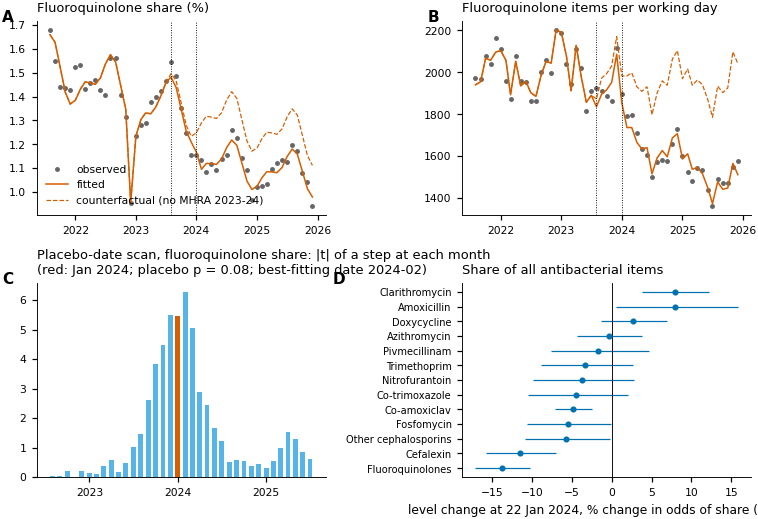

  figure: outputs_antibacterials/figures/figure4a_fluoroquinolone_national_its.png / .pdf


In [14]:
banner("AIM 1 - NATIONAL ITS: FLUOROQUINOLONE RESTRICTIONS")
FQ_EVENTS = ["MHRA_FQ_AUG23", "MHRA_FQ_JAN24"]
FQ_ANCHOR = event_month("MHRA_FQ_JAN24")
WINTER_NUISANCE = ["STREP_A_SURGE", "PENV_SSP"]


ATYPICAL_PNEUMONIA_UNITS = ["Azithromycin", "Clarithromycin", "Erythromycin", "Doxycycline"]


def nuisance_for(*names):
    nu = list(WINTER_NUISANCE)
    if any(n in URINARY_UNITS for n in names):
        nu.append("MHRA_NITRO_APR23")
    if "Clarithromycin" in names:
        nu += ["CLARI_SSP054", "CLARI_SSP_2024"]
    if any(n in ATYPICAL_PNEUMONIA_UNITS for n in names):
        nu.append("MYCOPLASMA_2324")     # Nov 2023 - Jul 2024, overlaps the Jan 2024 restriction
    return nu


AIM1_MODELS = ([("FQ_share", ("share", "Fluoroquinolones"), "logit", "Aim 1 primary"),
                ("FQ_items", ("items", "Fluoroquinolones"), "log", "Aim 1 primary"),
                ("Cipro_share", ("share", "Ciprofloxacin"), "logit", "Aim 1 secondary"),
                ("Levo_share", ("share", "Levofloxacin"), "logit", "Aim 1 secondary"),
                ("Broad_share", ("share", "Broad-spectrum (NHS measure)"), "logit", "Aim 1 secondary"),
                ("All_items", ("items", "All antibacterials"), "log", "Aim 1 secondary"),
                ("Pair_cipro_coamox", ("pair", ("Ciprofloxacin", "Co-amoxiclav")), "logit", "Aim 1 secondary")] +
               [("ALT_share_" + key(a), ("share", a), "logit", "Aim 1 alternatives (share)") for a in FQ_ALTERNATIVES] +
               [("ALT_items_" + key(a), ("items", a), "log", "Aim 1 alternatives (items)") for a in FQ_ALTERNATIVES])
for mid, oc, kind, fam in AIM1_MODELS:
    names = oc[1] if isinstance(oc[1], tuple) else (oc[1],)
    run_its(mid, oc, kind, FQ_EVENTS, nuisance_for(*names), anchor=FQ_ANCHOR, family=fam)

AIM1_FAMILIES = ["Aim 1 primary", "Aim 1 secondary", "Aim 1 alternatives (share)", "Aim 1 alternatives (items)"]
aim1 = its_table(AIM1_FAMILIES)
for fam in AIM1_FAMILIES:
    print("\n" + fam + "  (pct = % change: odds of share for share models, items for volume models)")
    show_its(aim1[aim1.family == fam])
save("table_s4a_its_aim1", aim1)

fq = ITS_FITS["FQ_items"]["eff"]
rows = []
for a in FQ_ALTERNATIVES:
    f = ITS_FITS.get("ALT_items_" + key(a))
    if f is None:
        continue
    r = f["eff"]["draws"] / (-fq["draws"])
    rows.append(dict(alternative=a, excess_items=f["eff"]["point"], low=f["eff"]["low"], high=f["eff"]["high"],
                     pct_of_fq_deficit=100 * f["eff"]["point"] / (-fq["point"]),
                     pct_low=100 * np.percentile(r, 2.5), pct_high=100 * np.percentile(r, 97.5)))
DISPLACEMENT_NATIONAL = pd.DataFrame(rows).sort_values("excess_items", ascending=False)
print("\nNational displacement accounting, Aug 2023 onwards (fluoroquinolone change: %s items, 95%% %s to %s):" %
      (format(int(fq["point"]), ","), format(int(fq["low"]), ","), format(int(fq["high"]), ",")))
print(DISPLACEMENT_NATIONAL.round(1).to_string(index=False))
tot = ITS_FITS["All_items"]["eff"]
print("All antibacterial items over the same months: %s (95%% %s to %s)" %
      (format(int(tot["point"]), ","), format(int(tot["low"]), ","), format(int(tot["high"]), ",")))
print("(Intervals for % of deficit treat the separate models' draws as independent: approximate.)")
print("CAUTION: these unadjusted national item models absorb every change in overall prescribing volume,\n"
      "  so a 'share of the deficit' far outside 0-100% means the series moved with total prescribing,\n"
      "  not that it replaced fluoroquinolones. Use the volume-adjusted table below and the ICB design.")
save("table_aim1_national_displacement", DISPLACEMENT_NATIONAL)
RESULTS["aim1_national"] = aim1

# ---- Figure 3 -------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(180 * MM, 125 * MM))
for ax, mid, lab, scale, letter in [(axes[0, 0], "FQ_share", "Fluoroquinolone share (%)", 100, "A"),
                                    (axes[0, 1], "FQ_items", "Fluoroquinolone items per working day", None, "B")]:
    f = ITS_FITS[mid]
    d = to_dates(f["block"])
    fit_v, cf_v = fitted_cf(f)
    wd = np.array([working_days(ym) for ym in f["block"]])
    obs = f["yv"] * 100 if scale else f["yv"] / wd
    fit_v = fit_v * 100 if scale else fit_v / wd
    cf_v = cf_v * 100 if scale else cf_v / wd
    ax.plot(d, obs, "o", ms=2.2, color=OKABE["grey"], label="observed")
    ax.plot(d, fit_v, color=OKABE["vermillion"], label="fitted")
    ax.plot(d, cf_v, color=OKABE["vermillion"], ls="--", lw=0.8, label="counterfactual (no MHRA 2023-24)")
    for e in FQ_EVENTS:
        ax.axvline(to_dates([event_month(e)])[0], color=OKABE["black"], ls=":", lw=0.6)
    ax.set_title(lab, loc="left")
    year_axis(ax)
    _label(ax, letter)
axes[0, 0].legend(loc="lower left")
sc = ITS_FITS["FQ_share"]["scan"]
ax = axes[1, 0]
if sc and not sc["table"].empty:
    ax.bar(to_dates(sc["table"].ym), sc["table"].t_step.abs(), width=20, color=OKABE["sky"])
    ax.bar(to_dates([FQ_ANCHOR]), [sc["t_true"]], width=20, color=OKABE["vermillion"])
    ax.set_title("Placebo-date scan, fluoroquinolone share: |t| of a step at each month\n"
                 "(red: Jan 2024; placebo p = %.2f; best-fitting date %s)" % (sc["p"], ym_str(sc["best"])), loc="left")
    year_axis(ax)
_label(ax, "C")
ax = axes[1, 1]
fr = aim1[(aim1.term == "STEP_MHRA_FQ_JAN24") & aim1.family.isin(["Aim 1 primary", "Aim 1 alternatives (share)"])
          & (aim1.scale == "logit")].copy()
fr["name"] = fr.outcome.str.replace("share: ", "", regex=False)
fr = fr.sort_values("pct")
yy = np.arange(len(fr))
ax.errorbar(fr.pct, yy, xerr=[fr.pct - fr.pct_low, fr.pct_high - fr.pct], fmt="o", ms=3, color=OKABE["blue"],
            ecolor=OKABE["blue"], elinewidth=0.8, capsize=0)
ax.axvline(0, color=OKABE["black"], lw=0.6)
ax.set_yticks(yy)
ax.set_yticklabels(fr.name, fontsize=6.5)
ax.set_xlabel("level change at 22 Jan 2024, % change in odds of share (95% CI)")
ax.set_title("Share of all antibacterial items", loc="left")
_label(ax, "D", dx=-0.45)
fig.tight_layout()
_save(fig, "figure4a_fluoroquinolone_national_its")

## 10b. Volume or denominator? And how much is trend?

A share can fall because a drug is prescribed less, or because everything else is prescribed more.
The table below separates, for each headline series, the trend before the event, the level change at
22 January 2024, and the trend afterwards; it then checks the arithmetic identity

    share change ≈ items change − total-items change.

When a large part of a share effect comes from the denominator, the volume model (items or DDDs) is
the estimate to report as the effect on prescribing.

The **volume-adjusted displacement models** that follow put each alternative's items on the same
footing: log(items of everything except fluoroquinolones and that alternative) enters as a
covariate, so the estimated change is net of how much antibacterial prescribing was going on. The
unadjusted national item models cannot separate the two, which is why their "share of the
fluoroquinolone deficit" can exceed 100% in either direction. The ICB design (Section 12) remains
the primary substitution analysis.

In [15]:
banner("VOLUME, DENOMINATOR AND TREND DECOMPOSITION")
rows = []
for mid, lab in [("FQ_share", "Fluoroquinolone share"), ("FQ_items", "Fluoroquinolone items"),
                 ("Cipro_share", "Ciprofloxacin share"), ("Broad_share", "Broad-spectrum share"),
                 ("All_items", "All antibacterial items")]:
    f = ITS_FITS.get(mid)
    if f is None:
        continue
    tr, tr_lo, tr_hi, b_t = trend_annual(f)
    par = f["hac"].params
    n = len(f["block"])
    slope = float(par["SLOPE_MHRA_FQ_JAN24"]) if "SLOPE_MHRA_FQ_JAN24" in par.index else 0.0
    rows.append(dict(series=lab, scale="odds" if f["kind"] == "logit" else "items",
                     trend_pct_per_year=tr, trend_low=tr_lo, trend_high=tr_hi,
                     cumulative_trend_over_window_pct=100 * (np.exp(b_t * (n - 1)) - 1),
                     step_jan24_pct=100 * (np.exp(float(par["STEP_MHRA_FQ_JAN24"])) - 1),
                     post_trend_pct_per_year=100 * (np.exp(12 * (b_t + slope)) - 1)))
TREND_DECOMP = pd.DataFrame(rows)
print(TREND_DECOMP.round(2).to_string(index=False))
save("table_aim1_trend_decomposition", TREND_DECOMP)
RESULTS["trend_decomposition"] = TREND_DECOMP

DENOM_NOTE = ""
have = {m: ITS_FITS.get(m) for m in ("FQ_share", "FQ_items", "All_items")}
if all(have.values()):
    g = lambda m: 100 * (np.exp(float(have[m]["hac"].params["STEP_MHRA_FQ_JAN24"])) - 1)
    s_share, s_items, s_total = g("FQ_share"), g("FQ_items"), g("All_items")
    implied = 100 * ((1 + s_items / 100) / (1 + s_total / 100) - 1)
    frac = 100 * abs(s_share - s_items) / max(abs(s_share), 1e-9)
    DENOM_NOTE = ("DENOMINATOR: at 22 Jan 2024 fluoroquinolone items changed %+.1f%%, all antibacterial items "
                  "%+.1f%%; that implies a share change of %+.1f%% against %+.1f%% estimated. About %.0f%% of "
                  "the share effect is the denominator, so report items (and DDDs) as the effect on "
                  "prescribing and the share as composition." % (s_items, s_total, implied, s_share, frac))
    print("\n" + DENOM_NOTE)
RESULTS["denominator_note"] = DENOM_NOTE

banner("VOLUME-ADJUSTED NATIONAL DISPLACEMENT")
blk = usable_block(FQ_ANCHOR)
nonfq = (nat["TOTAL_ITEMS"] - nat["ITEMS_FQ"]).loc[blk]
f_fq_adj = run_its("ADJ_items_FQ", ("items", "Fluoroquinolones"), "log", FQ_EVENTS, WINTER_NUISANCE,
                   anchor=FQ_ANCHOR, family="Aim 1 volume-adjusted", block=blk, scan=False,
                   covars={"LOG_OTHER_VOL": np.log(nonfq.values)})
rows = []
if f_fq_adj is not None:
    base = f_fq_adj["eff"]
    for a in FQ_ALTERNATIVES:
        ctrl = np.log((nonfq - nat[item_col(a)].loc[blk]).values)
        f = run_its("ADJ_items_" + key(a), ("items", a), "log", FQ_EVENTS, nuisance_for(a), anchor=FQ_ANCHOR,
                    family="Aim 1 volume-adjusted", block=blk, scan=False, covars={"LOG_OTHER_VOL": ctrl})
        if f is None:
            continue
        r = f["eff"]["draws"] / (-base["draws"])
        rows.append(dict(alternative=a, excess_items=f["eff"]["point"], low=f["eff"]["low"], high=f["eff"]["high"],
                         pct_of_fq_deficit=100 * f["eff"]["point"] / (-base["point"]),
                         pct_low=100 * np.percentile(r, 2.5), pct_high=100 * np.percentile(r, 97.5)))
    DISPLACEMENT_ADJUSTED = pd.DataFrame(rows).sort_values("excess_items", ascending=False)
    print("Change in each alternative's items, adjusted for total antibacterial volume, from Aug 2023")
    print("(fluoroquinolone change on the same basis: %s items, 95%% %s to %s):" %
          (format(int(base["point"]), ","), format(int(base["low"]), ","), format(int(base["high"]), ",")))
    print(DISPLACEMENT_ADJUSTED.round(1).to_string(index=False))
    moved = DISPLACEMENT_ADJUSTED[(DISPLACEMENT_ADJUSTED.low > 0) | (DISPLACEMENT_ADJUSTED.high < 0)]
    print("Alternatives whose change differs from zero: " +
          (", ".join(moved.alternative) if len(moved) else "none"))
    save("table_aim1_national_displacement_adjusted", DISPLACEMENT_ADJUSTED)
    RESULTS["displacement_adjusted"] = DISPLACEMENT_ADJUSTED


VOLUME, DENOMINATOR AND TREND DECOMPOSITION
                 series scale  trend_pct_per_year  trend_low  trend_high  cumulative_trend_over_window_pct  step_jan24_pct  post_trend_pct_per_year
  Fluoroquinolone share  odds               -5.13      -7.72       -2.47                            -20.41          -13.77                    -3.16
  Fluoroquinolone items items               -0.66      -2.51        1.22                             -2.85           -8.19                    -9.36
    Ciprofloxacin share  odds               -6.76      -9.31       -4.14                            -26.17          -16.17                    -4.72
   Broad-spectrum share  odds               -3.00      -5.58       -0.34                            -12.35           -9.06                     5.14
All antibacterial items items                4.45       1.43        7.56                             20.78            6.04                    -6.34
  written: outputs_antibacterials/table_aim1_trend_decomposition.cs

## 11. Aim 2 — supply shocks: month-by-month cascade, and the formulation artefact

The Strep A surge (Dec 2022) and the PenV SSPs (15 Dec 2022 – 12 May 2023) overlap, so no
single "effect" can be attributed to either. Instead each month from November 2022 to May 2023
gets its own indicator: the model estimates the counterfactual from the trend and seasonality of
the surrounding 3+ years, and each month's coefficient is that month's excess (items) or excess
share (composition). Reading across units within a month shows the cascade; reading along a row
shows its duration. The 2023–24 fluoroquinolone events enter as nuisance terms.

The clarithromycin SSPs were **formulation** substitutions (suspension → tablets). They should
be invisible at molecule level and visible in the solid-dose fraction — which is exactly why a
tablets-only analysis mistakes them for a clarithromycin surge.


AIM 2 - CASCADE, NOV 2022 - MAY 2023
  written: outputs_antibacterials/table_s4b_its_aim2_cascade.csv
Cumulative excess items, Nov 2022 - May 2023 ('items': volume model; 'share': items reallocated by the change in composition):
outcome                      items     share
unit                                        
Amoxicillin              1051296.0  336666.0
Azithromycin               19480.0  -33220.0
Cefalexin                  27725.0  -28308.0
Clarithromycin            203710.0   60682.0
Co-amoxiclav               65755.0  -20918.0
Doxycycline               381356.0   84315.0
Erythromycin               76928.0   39881.0
Flucloxacillin             76945.0 -138673.0
Phenoxymethylpenicillin   355817.0  156117.0
  written: outputs_antibacterials/table_aim2_cascade_cumulative.csv


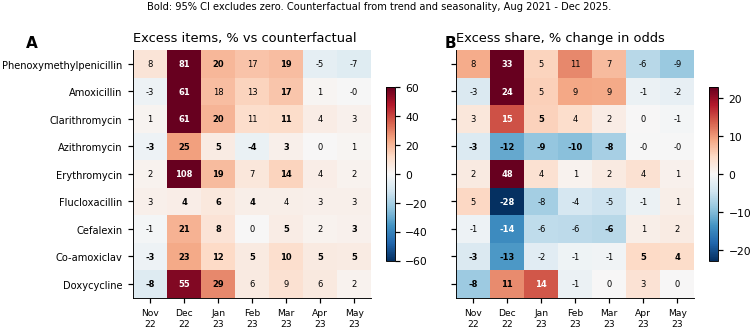

  figure: outputs_antibacterials/figures/figure5_supply_cascade.png / .pdf

FORMULATION SHIFTS UNDER THE SSPs
                       model               term   pct pct_low pct_high     p  q_bh model_abs_items model_abs_low model_abs_high  bg_p placebo_p scan_best
         FORM_CLARITHROMYCIN   WIN_CLARI_SSP054  38.6    22.2     57.2 0.000 0.000          43,128        21,050         66,898 0.000       NaN          
         FORM_CLARITHROMYCIN WIN_CLARI_SSP_2024  15.7    -7.1     44.0 0.193 0.238          43,128        21,050         66,898 0.000       NaN          
FORM_PHENOXYMETHYLPENICILLIN       WIN_PENV_SSP -10.9   -26.4      7.9 0.238 0.238         -37,893       -97,463         26,310 0.000       NaN          
(model_abs_items = prescriptions dispensed as a solid dose instead of a liquid while the SSPs were active)
  written: outputs_antibacterials/table_formulation_shift.csv


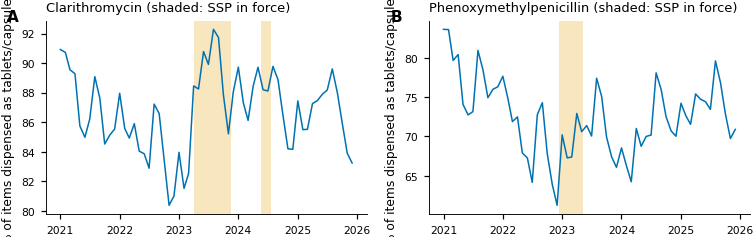

  figure: outputs_antibacterials/figures/supplementary/figure_s_formulation_shift.png / .pdf


In [16]:
banner("AIM 2 - CASCADE, NOV 2022 - MAY 2023")
CASCADE_YMS = ym_range(*CASCADE_MONTHS)
CASCADE_BLOCK = usable_block(CASCADE_YMS[0], max_pre=ITS_MAX_PRE, max_post=10 ** 4)


def cascade_extra(block):
    return {"M_%d" % ym: (np.array(block) == ym).astype(float) for ym in CASCADE_YMS if ym in block}


def cascade_nuisance(names):
    nu = ["MHRA_FQ_AUG23", "MHRA_FQ_JAN24"]
    if any(n in ATYPICAL_PNEUMONIA_UNITS for n in names):
        nu.append("MYCOPLASMA_2324")
    if any(n in URINARY_UNITS for n in names):
        nu.append("MHRA_NITRO_APR23")
    if "Clarithromycin" in names:
        nu += ["CLARI_SSP054", "CLARI_SSP_2024"]
    return nu


CASC_UNITS = [u for u in CASCADE_UNITS if u in COHORT_ACTIVE]
for u in CASC_UNITS:
    for oc, kind, tag in [(("items", u), "log", "items"), (("share", u), "logit", "share")]:
        run_its("CASCADE_%s_%s" % (tag, key(u)), oc, kind, [], cascade_nuisance([u]), anchor=CASCADE_YMS[0],
                family="Aim 2 cascade (%s)" % tag, extra=cascade_extra(CASCADE_BLOCK), block=CASCADE_BLOCK, scan=False)
for a, b in [("Phenoxymethylpenicillin", "Amoxicillin"), ("Amoxicillin", "Clarithromycin"),
             ("Clarithromycin", "Erythromycin")]:
    run_its("CASCADE_pair_%s_%s" % (key(a), key(b)), ("pair", (a, b)), "logit", [], cascade_nuisance([a, b]),
            anchor=CASCADE_YMS[0], family="Aim 2 cascade (pair)", extra=cascade_extra(CASCADE_BLOCK),
            block=CASCADE_BLOCK, scan=False)
casc = its_table(["Aim 2 cascade (items)", "Aim 2 cascade (share)", "Aim 2 cascade (pair)"])
casc["month"] = casc.term.str.replace("M_", "", regex=False).astype(int)
casc["unit"] = casc.model.str.replace(r"^CASCADE_(items|share|pair)_", "", regex=True)
save("table_s4b_its_aim2_cascade", casc)

cum = []
for u in CASC_UNITS:
    for tag in ("items", "share"):
        f = ITS_FITS.get("CASCADE_%s_%s" % (tag, key(u)))
        if f:
            cum.append(dict(unit=u, outcome=tag, excess_items_nov22_may23=f["eff"]["point"],
                            low=f["eff"]["low"], high=f["eff"]["high"]))
CASCADE_CUM = pd.DataFrame(cum)
print("Cumulative excess items, Nov 2022 - May 2023 ('items': volume model; 'share': items reallocated "
      "by the change in composition):")
print(CASCADE_CUM.pivot(index="unit", columns="outcome",
                        values="excess_items_nov22_may23").round(0).to_string())
save("table_aim2_cascade_cumulative", CASCADE_CUM)

fig, axes = plt.subplots(1, 2, figsize=(180 * MM, 80 * MM), sharey=True)
for ax, fam, title, letter in [(axes[0], "Aim 2 cascade (items)", "Excess items, % vs counterfactual", "A"),
                               (axes[1], "Aim 2 cascade (share)", "Excess share, % change in odds", "B")]:
    t = casc[casc.family == fam]
    M = t.pivot(index="unit", columns="month", values="pct").reindex([key(u) for u in CASC_UNITS])
    S = (t.assign(sig=(t.pct_low > 0) | (t.pct_high < 0))
         .pivot(index="unit", columns="month", values="sig").reindex([key(u) for u in CASC_UNITS]))
    lim = np.nanpercentile(np.abs(M.values), 95) or 1
    im = ax.imshow(M.values, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, "%.0f" % v, ha="center", va="center", fontsize=5.5,
                        fontweight="bold" if S.values[i, j] else "normal",
                        color="white" if abs(v) > 0.6 * lim else "black")
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels([pd.Timestamp(str(c) + "01").strftime("%b\n%y") for c in M.columns], fontsize=6)
    ax.set_yticks(range(len(CASC_UNITS)))
    ax.set_yticklabels(CASC_UNITS, fontsize=6.5)
    ax.set_title(title, loc="left")
    fig.colorbar(im, ax=ax, shrink=0.7)
    _label(ax, letter, dx=-0.05 if letter == "B" else -0.45)
fig.suptitle("Bold: 95% CI excludes zero. Counterfactual from trend and seasonality, Aug 2021 - Dec 2025.", fontsize=6.5)
fig.tight_layout()
_save(fig, "figure5_supply_cascade")

banner("FORMULATION SHIFTS UNDER THE SSPs")
for u, wins in [("Clarithromycin", ["CLARI_SSP054", "CLARI_SSP_2024"]), ("Phenoxymethylpenicillin", ["PENV_SSP"])]:
    run_its("FORM_" + key(u), ("solid_fraction", u), "logit", wins, ["STREP_A_SURGE"], anchor=event_month(wins[0]),
            family="Formulation shift", frame=nat_all, scan=False)
form = its_table(["Formulation shift"])
show_its(form)
print("(model_abs_items = prescriptions dispensed as a solid dose instead of a liquid while the SSPs were active)")
save("table_formulation_shift", form)

fig, axes = plt.subplots(1, 2, figsize=(180 * MM, 60 * MM))
for ax, u, wins, letter in [(axes[0], "Clarithromycin", ["CLARI_SSP054", "CLARI_SSP_2024"], "A"),
                            (axes[1], "Phenoxymethylpenicillin", ["PENV_SSP"], "B")]:
    fr = series_for(nat_all, ("solid_fraction", u)) * 100
    ax.plot(to_dates(fr.index), fr.values, color=OKABE["blue"])
    for w in wins:
        s = pd.Timestamp(EV[w]["date"])
        e = pd.Timestamp(EV[w]["end"])
        ax.axvspan(s, e, color=OKABE["orange"], alpha=0.25, lw=0)
    ax.set_ylabel("% of items dispensed as tablets/capsules")
    ax.set_title(u + " (shaded: SSP in force)", loc="left")
    year_axis(ax)
    _label(ax, letter)
fig.tight_layout()
_save(fig, "figure_s_formulation_shift", supplementary=True)

## 12a. Aim 3 — urinary market

* **NICE NG109 and the 2019 MHRA restriction** are attempted and, with a 2021 start, refused by
  the estimability guard. The planned "NG109 success story" cannot be tested from these data; the
  secular 2021–25 trend in the trimethoprim/nitrofurantoin pair is reported descriptively
  instead.
* **MHRA nitrofurantoin safety update (26 April 2023)** is in-window and testable: did it move
  prescribing away from nitrofurantoin, and towards what?


AIM 3 - URINARY MARKET
Guideline events before the data (attempted; the guard should refuse them):
  skipped NG109_pair                     not estimable: precedes the data (202101); extend extracts back to test it
  skipped MHRA2019_FQ_share              not estimable: precedes the data (202101); extend extracts back to test it

MHRA nitrofurantoin DSU, 26 Apr 2023 (level change, % change in odds):
               model                  term  pct pct_low pct_high     p  q_bh model_abs_items model_abs_low model_abs_high  bg_p placebo_p scan_best
NITRO_pair_tri_nitro STEP_MHRA_NITRO_APR23 -2.1    -3.7     -0.5 0.010 0.060         -67,004      -118,602        -16,677 0.008     0.206   2023-10
NITRO_pair_nitro_piv STEP_MHRA_NITRO_APR23  1.0    -1.6      3.5 0.461 0.553           8,280       -12,942         30,743 0.539     0.471   2023-12
   NITRO_share_nitro STEP_MHRA_NITRO_APR23  8.2     0.6     16.4 0.035 0.104         785,624        56,421      1,478,728 0.003     0.029   2023-05
    

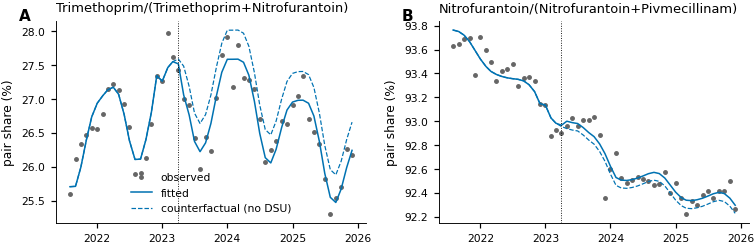

  figure: outputs_antibacterials/figures/figure3_urinary_market.png / .pdf


In [17]:
banner("AIM 3 - URINARY MARKET")
print("Guideline events before the data (attempted; the guard should refuse them):")
run_its("NG109_pair", ("pair", ("Trimethoprim", "Nitrofurantoin")), "logit", ["NICE_NG109"], ["STREP_A_SURGE"],
        family="Aim 3 guideline (pre-window)")
run_its("MHRA2019_FQ_share", ("share", "Fluoroquinolones"), "logit", ["MHRA_FQ_MAR19"], ["STREP_A_SURGE"],
        family="Aim 3 guideline (pre-window)")

UTI_NUISANCE = ["STREP_A_SURGE", "MHRA_FQ_AUG23", "MHRA_FQ_JAN24"]
for mid, oc in [("NITRO_pair_tri_nitro", ("pair", ("Trimethoprim", "Nitrofurantoin"))),
                ("NITRO_pair_nitro_piv", ("pair", ("Nitrofurantoin", "Pivmecillinam"))),
                ("NITRO_share_nitro", ("share", "Nitrofurantoin")),
                ("NITRO_share_piv", ("share", "Pivmecillinam")),
                ("NITRO_share_tri", ("share", "Trimethoprim")),
                ("NITRO_share_fosfo", ("share", "Fosfomycin"))]:
    run_its(mid, oc, "logit", ["MHRA_NITRO_APR23"], UTI_NUISANCE, family="Aim 3 nitrofurantoin DSU")
aim3 = its_table(["Aim 3 nitrofurantoin DSU"])
print("\nMHRA nitrofurantoin DSU, 26 Apr 2023 (level change, % change in odds):")
show_its(aim3)
save("table_s4c_its_aim3", aim3)

rows = []
for oc in [("pair", ("Trimethoprim", "Nitrofurantoin")), ("pair", ("Nitrofurantoin", "Pivmecillinam")),
           ("share", "Trimethoprim"), ("share", "Nitrofurantoin"), ("share", "Pivmecillinam")]:
    y = logit(series_for(nat.loc[MAIN_BLOCK], oc).values)
    X, _ = its_design(MAIN_BLOCK, "logit", [], ["STREP_A_SURGE"])
    hac, _, _ = fit_its(y, X)
    b = float(hac.params["T"])
    lo, hi = (float(v) for v in hac.conf_int().loc["T"])
    rows.append(dict(series=outcome_label(oc), pct_change_odds_per_year=100 * (np.exp(12 * b) - 1),
                     low=100 * (np.exp(12 * lo) - 1), high=100 * (np.exp(12 * hi) - 1), p=float(hac.pvalues["T"])))
UTI_TRENDS = pd.DataFrame(rows)
print("\nSecular trends %s to %s (descriptive; not attributable to NG109 without pre-2019 data):" %
      (ym_str(MAIN_BLOCK[0]), ym_str(MAIN_BLOCK[-1])))
print(UTI_TRENDS.round(3).to_string(index=False))
save("table_aim3_urinary_trends", UTI_TRENDS)

fig, axes = plt.subplots(1, 2, figsize=(180 * MM, 62 * MM))
for ax, mid, letter in [(axes[0], "NITRO_pair_tri_nitro", "A"), (axes[1], "NITRO_pair_nitro_piv", "B")]:
    f = ITS_FITS.get(mid)
    if f is None:
        ax.set_visible(False)
        continue
    d = to_dates(f["block"])
    fit_v, cf_v = fitted_cf(f)
    ax.plot(d, f["yv"] * 100, "o", ms=2.2, color=OKABE["grey"], label="observed")
    ax.plot(d, fit_v * 100, color=OKABE["blue"], label="fitted")
    ax.plot(d, cf_v * 100, color=OKABE["blue"], ls="--", lw=0.8, label="counterfactual (no DSU)")
    ax.axvline(to_dates([event_month("MHRA_NITRO_APR23")])[0], color=OKABE["black"], ls=":", lw=0.6)
    ax.set_ylabel("pair share (%)")
    ax.set_title(outcome_label(f["outcome"]).replace("pair share ", ""), loc="left")
    year_axis(ax)
    _label(ax, letter)
axes[0].legend(loc="best")
fig.tight_layout()
_save(fig, "figure3_urinary_market")

## 12. Aim 1 — ICB intensity design: where did displaced fluoroquinolone prescribing go? (Table 2)

National series cannot separate substitution from coincident national trends in the
alternatives. ICBs differed in how much fluoroquinolone prescribing they had to give up, so the
restriction "bit" harder where baseline use was higher. With ICB and month fixed effects:

  *y*ᵢₜ = αᵢ + γₜ + θ_phase · Dᵢ · PHASEₜ + θ_post · Dᵢ · POSTₜ + εᵢₜ

* **Dᵢ** = ICB fluoroquinolone share of all antibacterial items, July 2021 – June 2022,
  in percentage points. It is measured *before* the estimation window (July 2022 onwards), so
  regression to the mean cannot manufacture an effect; the event-study leads test for it.
* **PHASE** = Aug–Dec 2023 (after the August 2023 reminder); **POST** = from 22 Jan 2024
  (fractional in January).
* Month fixed effects absorb everything national: seasonality, Strep A, SSPs, secular trends.
* **Dᵢ × seasonality** (two Fourier harmonic pairs of calendar month, 4 terms) absorbs seasonality
  that scales with intensity. A share's seasonal swing in percentage points is proportional to its
  level (fluoroquinolone share falls every winter as respiratory items swell the denominator),
  which additive month effects cannot remove; without these terms the event-study leads show a
  seasonal saw-tooth. Harmonics rather than 11 month dummies, because month dummies × Dᵢ are
  exactly collinear with quarterly event-study bins.
* **Dᵢ × national denominator index** (non-fluoroquinolone items per working day relative to
  their window mean, inverted). A national surge in the denominator — December 2022 — lowers every ICB's
  fluoroquinolone share by the same *proportion*, i.e. by more percentage points where the share
  is higher: the same signature as the policy. This term absorbs such shocks. It is built from
  non-fluoroquinolone items so that the restriction itself cannot move it.

Every one of the 21 units is analysed in percentage points of all items. Because the unit
shares sum to 100 in every ICB-month, the θ_post coefficients **sum to zero exactly** (checked
below). This gives an internally consistent decomposition: of each 1 pp of fluoroquinolone
share lost, how many pp went to each other unit. The **pro-rata benchmark** is what closure
alone would produce: if displaced prescriptions were simply not issued, every other unit's share
would rise in proportion to its baseline share of non-fluoroquinolone items. "Excess over
pro-rata" is targeted substitution, estimated directly as one coefficient with its own
cluster-robust error.

Inference: CR1 cluster-robust standard errors by ICB (42 clusters; t with G − 1 df) and a
restricted wild cluster bootstrap (Rademacher weights) p-value for θ_post. The event study
uses quarters relative to January 2024, with April–June 2023 (the last quarter before any
2023–24 fluoroquinolone communication) as reference; leads are tested jointly. The joint test does
not depend on which quarter is the reference. Read the lead *coefficients* alongside the p-value:
with 42 clusters and large counts, a residual seasonal misfit an order of magnitude smaller than
the estimated effect can still be statistically significant.

In [18]:
banner("ICB INTENSITY DESIGN")
from scipy import stats as st


class TWFE:
    """OLS with ICB and month fixed effects (dummies); CR1 cluster-robust by ICB; restricted
    wild cluster bootstrap (Rademacher) for a single coefficient of interest."""

    def __init__(self, df, xcols, icb_trends=False):
        self.xcols = list(xcols)
        ent = pd.Categorical(df["ORG_CODE"])
        tim = pd.Categorical(df["YEAR_MONTH"])
        self.g = np.asarray(ent.codes, dtype=int)
        self.G = len(ent.categories)
        E = np.eye(self.G)[self.g]
        Tm = np.eye(len(tim.categories))[np.asarray(tim.codes, dtype=int)][:, 1:]
        parts = [df[self.xcols].to_numpy(dtype=float), E, Tm]
        if icb_trends:
            t = np.array([ym_index(v) for v in df["YEAR_MONTH"]], float)
            parts.append((E * (t - t.mean())[:, None])[:, 1:])
        self.X = np.column_stack(parts)
        self.N, self.p = self.X.shape
        if np.linalg.matrix_rank(self.X) < self.p:
            raise ValueError("TWFE design is rank-deficient")
        self.XtX_inv = np.linalg.inv(self.X.T @ self.X)
        self.A = self.XtX_inv @ self.X.T
        self.C = np.zeros((self.G, self.N))
        self.C[self.g, np.arange(self.N)] = 1.0
        self.c = self.G / (self.G - 1) * (self.N - 1) / (self.N - self.p)
        self.H = self.X @ self.XtX_inv[:, :len(self.xcols)]
        self.tcrit = st.t.ppf(0.975, self.G - 1)

    def fit(self, y):
        y = np.asarray(y, float)
        beta = self.A @ y
        u = y - self.X @ beta
        S = self.C @ (self.H * u[:, None])
        return beta[:len(self.xcols)], self.c * S.T @ S, u

    def cov_between(self, u1, u2):
        S1 = self.C @ (self.H * u1[:, None])
        S2 = self.C @ (self.H * u2[:, None])
        return self.c * S1.T @ S2

    def wild_p(self, y, j, B=N_BOOT, seed=RANDOM_SEED, batch=2000):
        y = np.asarray(y, float)
        beta, V, _ = self.fit(y)
        t_hat = beta[j] / np.sqrt(V[j, j])
        Xr = np.delete(self.X, j, axis=1)
        fr = Xr @ np.linalg.lstsq(Xr, y, rcond=None)[0]
        ur = y - fr
        rng = np.random.default_rng(seed)
        h = self.H[:, [j]]
        hits = done = 0
        while done < B:                       # in batches: 10,000 x N matrices are large
            n_b = min(batch, B - done)
            Ys = fr[:, None] + ur[:, None] * rng.choice([-1.0, 1.0], size=(self.G, n_b))[self.g]
            Bs = self.A @ Ys
            Sg = self.C @ (h * (Ys - self.X @ Bs))
            ts = Bs[j] / np.sqrt(self.c * (Sg ** 2).sum(axis=0))
            hits += int((np.abs(ts) >= abs(t_hat)).sum())
            done += n_b
        return float(hits / B)


FQ_UNITS = [u for u in UNIT_ORDER if UNIT_CLASS[u] == "Fluoroquinolones"]
SEAS_BASE = ["DxZ", "DxS1", "DxC1", "DxS2", "DxC2"]
SEAS_COLS = SEAS_BASE
NONFQ_UNITS = [u for u in UNIT_ORDER if u not in FQ_UNITS]


def baseline_intensity(p, period=BASELINE_FQ_PERIOD):
    bl = p[(p.YEAR_MONTH >= period[0]) & (p.YEAR_MONTH <= period[1])]
    s = bl.groupby("ORG_CODE")[["ITEMS_FQ", "TOTAL_ITEMS"]].sum()
    return 100 * s.ITEMS_FQ / s.TOTAL_ITEMS, bl


def make_pw(p, period=BASELINE_FQ_PERIOD, window=PANEL_WINDOW):
    D, _ = baseline_intensity(p, period)
    w = p[(p.YEAR_MONTH >= window[0]) & (p.YEAR_MONTH <= window[1]) & p.YEAR_MONTH.isin(USABLE_SET)].copy()
    w["D_FQ"] = w.ORG_CODE.map(D)
    w["D_C"] = w.D_FQ - D.mean()
    yms = sorted(w.YEAR_MONTH.unique())
    e_aug = dict(zip(yms, step_exposure(yms, EV["MHRA_FQ_AUG23"]["date"])))
    e_jan = dict(zip(yms, step_exposure(yms, EV["MHRA_FQ_JAN24"]["date"])))
    w["POST"] = w.YEAR_MONTH.map(e_jan)
    w["PHASE"] = (w.YEAR_MONTH.map(e_aug) - w.POST).clip(lower=0)
    w["DxPHASE"] = w.D_C * w.PHASE
    w["DxPOST"] = w.D_C * w.POST
    new = {}
    for u in UNIT_ORDER:
        new["PP_" + key(u)] = 100 * w[item_col(u)] / w.TOTAL_ITEMS
        new["LV_" + key(u)] = np.log(w[item_col(u)] + 1.0)
    new["PP_FQ"] = 100 * w.ITEMS_FQ / w.TOTAL_ITEMS
    new["PP_BROAD"] = 100 * w.ITEMS_BROAD / w.TOTAL_ITEMS
    new["LV_TOTAL"] = np.log(w.TOTAL_ITEMS)
    new["LV_FQ"] = np.log(w.ITEMS_FQ + 1.0)
    nonfq = (p.TOTAL_ITEMS - p.ITEMS_FQ).groupby(p.YEAR_MONTH).sum().reindex(yms)
    nonfq = nonfq / pd.Series([working_days(v) for v in yms], index=yms)   # working days cancel out of shares
    z = nonfq.mean() / nonfq
    new["DxZ"] = w.D_C * (w.YEAR_MONTH.map(z) - 1.0)
    moy = (w.YEAR_MONTH % 100).astype(float)
    for h in (1, 2):
        new["DxS%d" % h] = w.D_C * np.sin(2 * np.pi * h * moy / 12)
        new["DxC%d" % h] = w.D_C * np.cos(2 * np.pi * h * moy / 12)
    w = pd.concat([w, pd.DataFrame(new, index=w.index)], axis=1)
    return w.sort_values(["ORG_CODE", "YEAR_MONTH"]).reset_index(drop=True), D


def decomposition(w, p_full, icb_trends=False, wild=True):
    """Pooled intensity model for all 21 units; returns (table, first-stage dict)."""
    m = TWFE(w, ["DxPHASE", "DxPOST"] + SEAS_COLS, icb_trends=icb_trends)
    b_fq, V_fq, u_fq = m.fit(w.PP_FQ)
    th_fq, se_fq = b_fq[1], np.sqrt(V_fq[1, 1])
    _, bl = baseline_intensity(p_full)
    bn = bl[[item_col(u) for u in UNIT_ORDER] + ["TOTAL_ITEMS", "ITEMS_FQ"]].sum()
    s_fq = bn.ITEMS_FQ / bn.TOTAL_ITEMS
    rows, total, empty = [], 0.0, []
    for u in UNIT_ORDER:
        col = "PP_" + key(u)
        if float(w[col].std()) == 0:          # no items in this scope: contributes exactly 0
            empty.append(u)
            continue
        b, V, uu = m.fit(w[col])
        total += b[1]
        if u in FQ_UNITS:
            continue
        th, se = b[1], np.sqrt(V[1, 1])
        cov = m.cov_between(uu, u_fq)[1, 1]
        frac = th / (-th_fq)
        var_f = V[1, 1] / th_fq ** 2 + th ** 2 * V_fq[1, 1] / th_fq ** 4 - 2 * th * cov / th_fq ** 3
        c_u = (bn[item_col(u)] / bn.TOTAL_ITEMS) / (1 - s_fq)
        z = w["PP_" + key(u)] - c_u * (100 - w.PP_FQ)
        bz, Vz, _ = m.fit(z)
        rows.append(dict(unit=u, theta_post_pp=th, low=th - m.tcrit * se, high=th + m.tcrit * se,
                         p_cluster=2 * st.t.sf(abs(th / se), m.G - 1),
                         p_wild=m.wild_p(w["PP_" + key(u)], 1, seed=_seed("wild" + u)) if wild else np.nan,
                         share_of_displaced_pct=100 * frac,
                         share_low=100 * (frac - 1.96 * np.sqrt(max(var_f, 0))),
                         share_high=100 * (frac + 1.96 * np.sqrt(max(var_f, 0))),
                         pro_rata_pct=100 * c_u, excess_over_pro_rata_pp=bz[1],
                         excess_low=bz[1] - m.tcrit * np.sqrt(Vz[1, 1]),
                         excess_high=bz[1] + m.tcrit * np.sqrt(Vz[1, 1]),
                         p_excess_wild=m.wild_p(z, 1, seed=_seed("wildx" + u)) if wild else np.nan))
    if empty:
        print("  no items in this scope, not modelled: " + ", ".join(empty))
    fs = dict(theta_fq=th_fq, low=th_fq - m.tcrit * se_fq, high=th_fq + m.tcrit * se_fq,
              p_cluster=2 * st.t.sf(abs(th_fq / se_fq), m.G - 1),
              p_wild=m.wild_p(w.PP_FQ, 1, seed=_seed("wildFQ")) if wild else np.nan,
              theta_phase=b_fq[0], adding_up=total, model=m)
    return pd.DataFrame(rows).sort_values("theta_post_pp", ascending=False).reset_index(drop=True), fs


pw, D_FQ = make_pw(panel)
print("Baseline fluoroquinolone share (%d-%d) across %d ICBs: mean %.2f%%, SD %.2f, range %.2f-%.2f%%" %
      (BASELINE_FQ_PERIOD[0], BASELINE_FQ_PERIOD[1], len(D_FQ), D_FQ.mean(), D_FQ.std(), D_FQ.min(), D_FQ.max()))
print("Estimation window %d-%d: %d ICB-months" % (pw.YEAR_MONTH.min(), pw.YEAR_MONTH.max(), len(pw)))
DECOMP, FS = decomposition(pw, panel)
if abs(FS["adding_up"]) > 1e-6:
    raise RuntimeError("Adding-up check failed: unit coefficients sum to %.3g, not 0" % FS["adding_up"])
print("Adding-up check: theta_post summed over all 21 units = %.1e (must be 0)  OK" % FS["adding_up"])
print("\nFirst stage - fluoroquinolone share, pp change per 1 pp of baseline share:")
print("  Aug-Dec 2023 phase: %.3f;  after 22 Jan 2024: %.3f (95%% CI %.3f to %.3f; cluster p=%.4f; wild p=%.3f)" %
      (FS["theta_phase"], FS["theta_fq"], FS["low"], FS["high"], FS["p_cluster"], FS["p_wild"]))
print("\nTable 2 - where the displaced share went (per 1 pp of fluoroquinolone share lost):")
print(DECOMP[["unit", "theta_post_pp", "low", "high", "p_wild", "share_of_displaced_pct", "share_low",
              "share_high", "pro_rata_pct", "excess_over_pro_rata_pp", "excess_low", "excess_high",
              "p_excess_wild"]].round(3).to_string(index=False))
print("\nshare_of_displaced_pct sums to %.1f%% over the non-fluoroquinolone units (100 by construction)." %
      DECOMP.share_of_displaced_pct.sum())
DECOMP["ci_width_pct"] = DECOMP.share_high - DECOMP.share_low
DECOMP["informative"] = DECOMP.ci_width_pct < INFORMATIVE_CI_PP
print("Rows whose share-of-displaced interval is narrower than %d percentage points: %d of %d. Wider "
      "intervals say nothing about where prescribing went and should not be quoted." %
      (INFORMATIVE_CI_PP, int(DECOMP.informative.sum()), len(DECOMP)))
save("table2_fluoroquinolone_displacement_icb", DECOMP)
RESULTS["decomposition"], RESULTS["first_stage"] = DECOMP, {k: v for k, v in FS.items() if k != "model"}

DECOMP_T, FS_T = decomposition(pw, panel, icb_trends=True, wild=False)
print("\nFirst stage, primary     : %.3f pp per pp (95%% CI %.3f to %.3f)" % (FS["theta_fq"], FS["low"], FS["high"]))
print("First stage, ICB trends  : %.3f pp per pp (95%% CI %.3f to %.3f)" % (FS_T["theta_fq"], FS_T["low"], FS_T["high"]))
print("Report both whenever the lead test in the next cell fails. Trends fitted over the whole window\n"
      "also absorb effects that grow over time, so the trend-adjusted estimate is a lower bound.")
save("table2b_displacement_icb_trend_adjusted", DECOMP_T)
RESULTS["first_stage_trend_adj"] = {k: v for k, v in FS_T.items() if k != "model"}

m = FS["model"]
rows = []
for name, col in ([("All antibacterials", "LV_TOTAL"), ("Fluoroquinolones", "LV_FQ")] +
                  [(a, "LV_" + key(a)) for a in FQ_ALTERNATIVES]):
    b, V, _ = m.fit(pw[col])
    se = np.sqrt(V[1, 1])
    rows.append(dict(outcome=name, pct_per_pp=100 * (np.exp(b[1]) - 1),
                     low=100 * (np.exp(b[1] - m.tcrit * se) - 1), high=100 * (np.exp(b[1] + m.tcrit * se) - 1),
                     p_wild=m.wild_p(pw[col], 1, seed=_seed("wildLV" + name))))
VOLUME = pd.DataFrame(rows)
print("\nVolume: % change in items after Jan 2024 per 1 pp of baseline fluoroquinolone share:")
print(VOLUME.round(3).to_string(index=False))
save("table_aim1_icb_volume", VOLUME)


ICB INTENSITY DESIGN
Baseline fluoroquinolone share (202107-202206) across 42 ICBs: mean 1.58%, SD 0.35, range 0.98-2.73%
Estimation window 202207-202512: 1764 ICB-months
Adding-up check: theta_post summed over all 21 units = -8.0e-13 (must be 0)  OK

First stage - fluoroquinolone share, pp change per 1 pp of baseline share:
  Aug-Dec 2023 phase: 0.018;  after 22 Jan 2024: -0.248 (95% CI -0.339 to -0.156; cluster p=0.0000; wild p=0.000)

Table 2 - where the displaced share went (per 1 pp of fluoroquinolone share lost):
                   unit  theta_post_pp    low  high  p_wild  share_of_displaced_pct  share_low  share_high  pro_rata_pct  excess_over_pro_rata_pp  excess_low  excess_high  p_excess_wild
   Other antibacterials          0.205 -0.420 0.830   0.717                  82.952   -173.561     339.464         1.179                    0.203      -0.423        0.828          0.721
         Co-trimoxazole          0.105  0.027 0.184   0.038                  42.557      2.020      83


EVENT STUDY AND PRE-TRENDS
Quarters relative to Jan 2024; reference quarter -3 (Apr-Jun 2023). Joint test of 3 leads:
                       outcome  n_leads     F     p
              Fluoroquinolones        3 3.968 0.014
                  Co-amoxiclav        3 1.614 0.201
                   Doxycycline        3 4.137 0.012
                     Cefalexin        3 2.277 0.094
                Nitrofurantoin        3 0.803 0.500
                 Pivmecillinam        3 3.752 0.018
  Broad-spectrum (NHS measure)        3 5.729 0.002
All antibacterials (log items)        3 4.380 0.009
  written: outputs_antibacterials/table_s5_event_study.csv
  written: outputs_antibacterials/table_s5_pretrend_tests.csv

Lead magnitudes (a significant lead test matters only if the leads are large next to the effect):
                       outcome  mean_abs_lead  mean_abs_post  lead_pct_of_effect  p_leads                        verdict
              Fluoroquinolones          0.085          0.305            

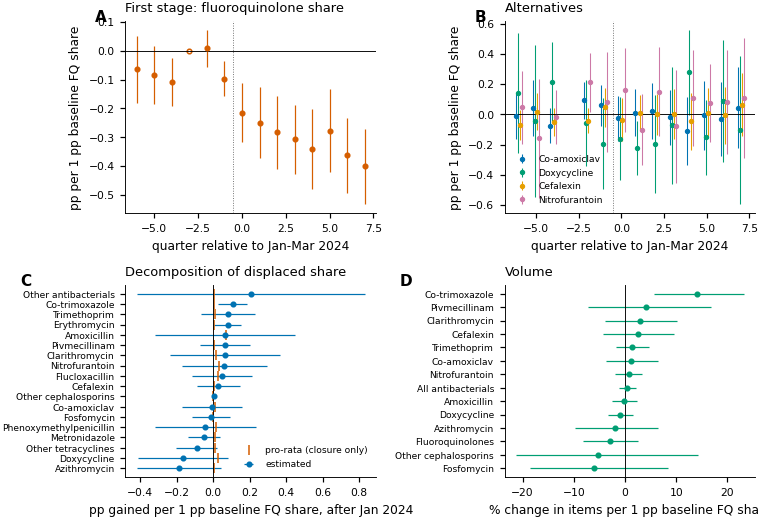

  figure: outputs_antibacterials/figures/figure4b_fluoroquinolone_icb_intensity.png / .pdf


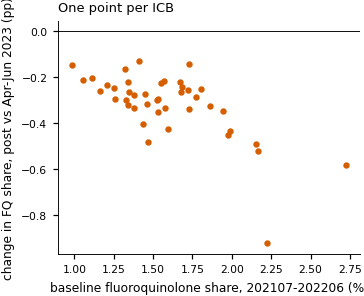

  figure: outputs_antibacterials/figures/supplementary/figure_s_icb_first_stage.png / .pdf


In [19]:
banner("EVENT STUDY AND PRE-TRENDS")


def quarter_bin(ym):
    return int(np.floor((ym_index(ym) - ym_index(EVENT_STUDY_ANCHOR)) / 3))


pw["BIN"] = pw.YEAR_MONTH.map(quarter_bin)
ES_BINS = sorted(b for b in pw.BIN.unique() if b != EVENT_STUDY_REF_BIN)
es_cols = []
for b in ES_BINS:
    c = "ES_%+d" % b
    pw[c] = pw.D_C * (pw.BIN == b).astype(float)
    es_cols.append(c)
ES = TWFE(pw, es_cols + SEAS_COLS)
LEADS = [i for i, b in enumerate(ES_BINS) if b < EVENT_STUDY_REF_BIN]
ES_OUTCOMES = [("PP_FQ", "Fluoroquinolones"), ("PP_CO_AMOXICLAV", "Co-amoxiclav"),
               ("PP_DOXYCYCLINE", "Doxycycline"), ("PP_CEFALEXIN", "Cefalexin"),
               ("PP_NITROFURANTOIN", "Nitrofurantoin"), ("PP_PIVMECILLINAM", "Pivmecillinam"),
               ("PP_BROAD", "Broad-spectrum (NHS measure)"), ("LV_TOTAL", "All antibacterials (log items)")]
es_rows, pre_rows = [], []
for col, lab in ES_OUTCOMES:
    b, V, _ = ES.fit(pw[col])
    se = np.sqrt(np.diag(V))
    for i, bb in enumerate(ES_BINS):
        es_rows.append(dict(outcome=lab, bin=bb, coef=b[i], low=b[i] - ES.tcrit * se[i], high=b[i] + ES.tcrit * se[i]))
    if LEADS:
        bl_, Vl = b[LEADS], V[np.ix_(LEADS, LEADS)]
        F = float(bl_ @ np.linalg.pinv(Vl) @ bl_) / len(LEADS)
        pre_rows.append(dict(outcome=lab, n_leads=len(LEADS), F=F, p=float(st.f.sf(F, len(LEADS), ES.G - 1))))
ES_TABLE = pd.DataFrame(es_rows)
PRETRENDS = pd.DataFrame(pre_rows)
print("Quarters relative to Jan 2024; reference quarter %+d (Apr-Jun 2023). Joint test of %d leads:" %
      (EVENT_STUDY_REF_BIN, len(LEADS)))
print(PRETRENDS.round(3).to_string(index=False))
save("table_s5_event_study", ES_TABLE)
save("table_s5_pretrend_tests", PRETRENDS)
RESULTS["pretrends"] = PRETRENDS

mag = []
for col, lab in ES_OUTCOMES:
    t = ES_TABLE[ES_TABLE.outcome == lab]
    lead = float(t[t.bin < EVENT_STUDY_REF_BIN].coef.abs().mean())
    post = float(t[t.bin >= 0].coef.abs().mean())
    p = float(PRETRENDS.loc[PRETRENDS.outcome == lab, "p"].iloc[0]) if (PRETRENDS.outcome == lab).any() else np.nan
    ratio = 100 * lead / post if post else np.nan
    mag.append(dict(outcome=lab, mean_abs_lead=lead, mean_abs_post=post, lead_pct_of_effect=ratio, p_leads=p,
                    verdict="clean" if p > 0.05 else
                    ("small relative to effect" if ratio < 25 else "pre-trend comparable to effect")))
LEAD_MAGNITUDE = pd.DataFrame(mag)
print("\nLead magnitudes (a significant lead test matters only if the leads are large next to the effect):")
print(LEAD_MAGNITUDE.round(3).to_string(index=False))
save("table_s5_lead_magnitude", LEAD_MAGNITUDE)
RESULTS["lead_magnitude"] = LEAD_MAGNITUDE
if (PRETRENDS.p < 0.05).any():
    print("\nCAUTION: leads are jointly non-zero for " + ", ".join(PRETRENDS.loc[PRETRENDS.p < 0.05, "outcome"]) +
          ".\n  Higher-intensity ICBs were already moving differently before the event, so Table 2 is\n"
          "  descriptive: quote the trend-adjusted first stage alongside the primary one, and quote a\n"
          "  unit's share of the displaced prescribing only where its interval is informative.")

fig, axes = plt.subplots(2, 2, figsize=(180 * MM, 125 * MM))
ax = axes[0, 0]
t = ES_TABLE[ES_TABLE.outcome == "Fluoroquinolones"]
ax.errorbar(t.bin, t.coef, yerr=[t.coef - t.low, t.high - t.coef], fmt="o", ms=3, color=OKABE["vermillion"],
            elinewidth=0.8, capsize=0)
ax.plot(EVENT_STUDY_REF_BIN, 0, "o", ms=3, mfc="white", color=OKABE["vermillion"])
ax.axhline(0, color=OKABE["black"], lw=0.6)
ax.axvline(-0.5, color=OKABE["grey"], ls=":", lw=0.6)
ax.set_xlabel("quarter relative to Jan-Mar 2024")
ax.set_ylabel("pp per 1 pp baseline FQ share")
ax.set_title("First stage: fluoroquinolone share", loc="left")
_label(ax, "A")
ax = axes[0, 1]
for k, (lab, col) in enumerate([("Co-amoxiclav", OKABE["blue"]), ("Doxycycline", OKABE["green"]),
                                ("Cefalexin", OKABE["orange"]), ("Nitrofurantoin", OKABE["purple"])]):
    t = ES_TABLE[ES_TABLE.outcome == lab]
    x = t.bin + (k - 1.5) * 0.12
    ax.errorbar(x, t.coef, yerr=[t.coef - t.low, t.high - t.coef], fmt="o", ms=2.5, color=col,
                elinewidth=0.7, capsize=0, label=lab)
ax.axhline(0, color=OKABE["black"], lw=0.6)
ax.axvline(-0.5, color=OKABE["grey"], ls=":", lw=0.6)
ax.set_xlabel("quarter relative to Jan-Mar 2024")
ax.set_ylabel("pp per 1 pp baseline FQ share")
ax.legend(fontsize=6)
ax.set_title("Alternatives", loc="left")
_label(ax, "B")
ax = axes[1, 0]
dd = DECOMP.sort_values("theta_post_pp")
yy = np.arange(len(dd))
ax.errorbar(dd.theta_post_pp, yy, xerr=[dd.theta_post_pp - dd.low, dd.high - dd.theta_post_pp], fmt="o", ms=3,
            color=OKABE["blue"], elinewidth=0.8, capsize=0, label="estimated")
ax.plot(dd.pro_rata_pct / 100 * (-FS["theta_fq"]), yy, "|", ms=7, color=OKABE["vermillion"],
        label="pro-rata (closure only)")
ax.axvline(0, color=OKABE["black"], lw=0.6)
ax.set_yticks(yy)
ax.set_yticklabels(dd.unit, fontsize=6)
ax.set_xlabel("pp gained per 1 pp baseline FQ share, after Jan 2024")
ax.legend(fontsize=6, loc="lower right")
ax.set_title("Decomposition of displaced share", loc="left")
_label(ax, "C", dx=-0.42)
ax = axes[1, 1]
vv = VOLUME.sort_values("pct_per_pp")
yy = np.arange(len(vv))
ax.errorbar(vv.pct_per_pp, yy, xerr=[vv.pct_per_pp - vv.low, vv.high - vv.pct_per_pp], fmt="o", ms=3,
            color=OKABE["green"], elinewidth=0.8, capsize=0)
ax.axvline(0, color=OKABE["black"], lw=0.6)
ax.set_yticks(yy)
ax.set_yticklabels(vv.outcome, fontsize=6)
ax.set_xlabel("% change in items per 1 pp baseline FQ share")
ax.set_title("Volume", loc="left")
_label(ax, "D", dx=-0.42)
fig.tight_layout()
_save(fig, "figure4b_fluoroquinolone_icb_intensity")

ref_months = [ym for ym in pw.YEAR_MONTH.unique() if quarter_bin(ym) == EVENT_STUDY_REF_BIN]
post_months = [ym for ym in pw.YEAR_MONTH.unique() if ym >= ym_add(EVENT_STUDY_ANCHOR, 1)]
chg = (pw[pw.YEAR_MONTH.isin(post_months)].groupby("ORG_CODE").PP_FQ.mean() -
       pw[pw.YEAR_MONTH.isin(ref_months)].groupby("ORG_CODE").PP_FQ.mean())
fig, ax = plt.subplots(figsize=(90 * MM, 70 * MM))
ax.scatter(D_FQ.reindex(chg.index), chg, s=10, color=OKABE["vermillion"])
ax.axhline(0, color=OKABE["black"], lw=0.6)
ax.set_xlabel("baseline fluoroquinolone share, %d-%d (%%)" % BASELINE_FQ_PERIOD)
ax.set_ylabel("change in FQ share, post vs Apr-Jun 2023 (pp)")
ax.set_title("One point per ICB", loc="left")
_save(fig, "figure_s_icb_first_stage", supplementary=True)

## 13. Temporal dynamics (descriptive): VAR, Granger and impulse responses (Supplementary Table S6)

Prescribing substitution is largely **contemporaneous**: when a drug is restricted or
unavailable, the alternative is prescribed at the same consultation. Granger tests only ask
whether one series' *past* improves prediction of another's *future*. They are therefore
reported as descriptive dynamics, not as evidence of substitution (which comes from Sections
10–12). Specification, per clinical market:

* each drug as log(items ÷ items of all antibacterials outside the market), STL-deseasonalised;
* every registered in-window event as an exogenous term (Strep A pulses, SSP windows, the
  nitrofurantoin and fluoroquinolone steps), so that shared responses to known interventions are
  not reported as one drug "causing" another;
* a deterministic linear trend for trend-stationary series; all series differenced (constant
  only) if any is not trend-stationary;
* lag order by AIC within a maximum that keeps ≥3 observations per parameter;
* F-tests within the VAR, **BH-FDR across all tests in all markets**; stability checked;
* orthogonalised IRFs (Cholesky order = order listed) with 90% Monte Carlo bands
  (1,000 replications). No fallback bands.

**Panel cross-lagged models** are the inferential counterpart: within-ICB lagged associations
with ICB and month fixed effects (the month effects remove every national shock, including
seasonality), cluster-robust by ICB, BH-FDR across the 16 directional tests. Nickell bias from a
lagged outcome with fixed effects is of order 1/T (about 2% here).


DESCRIPTIVE VAR / GRANGER BY CLINICAL MARKET
                      market                                                                           units  differenced trend  n  lag  lag_max  stable                                              verdicts
                 Respiratory Amoxicillin, Phenoxymethylpenicillin, Co-amoxiclav, Clarithromycin, Doxycycline         True     c 52    1        1    True unit root; ambiguous; unit root; ambiguous; unit root
                     Urinary                                     Trimethoprim, Nitrofurantoin, Pivmecillinam         True     c 52    2        2    True         trend-stationary; unit root; trend-stationary
        Skin and soft tissue                                       Flucloxacillin, Cefalexin, Clarithromycin         True     c 52    2        2    True                trend-stationary; ambiguous; ambiguous
Fluoroquinolone displacement                          Fluoroquinolones, Co-amoxiclav, Cefalexin, Doxycycline         True     

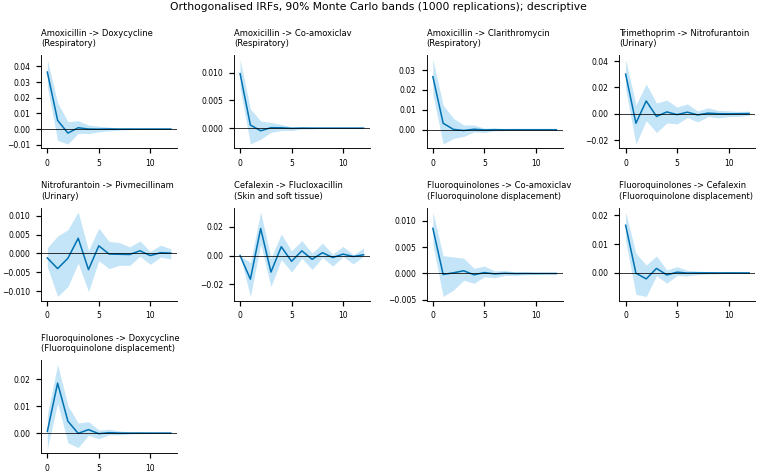

  figure: outputs_antibacterials/figures/supplementary/figure_s_var_irf.png / .pdf


In [20]:
banner("DESCRIPTIVE VAR / GRANGER BY CLINICAL MARKET")
from statsmodels.tsa.api import VAR

VAR_EXOG_EVENTS = ["STREP_A_SURGE", "PENV_SSP", "MHRA_NITRO_APR23", "MHRA_FQ_AUG23", "MHRA_FQ_JAN24",
                   "CLARI_SSP054", "CLARI_SSP_2024", "MYCOPLASMA_2324"]
_X, _ = its_design(MAIN_BLOCK, "logit", [], VAR_EXOG_EVENTS)
VAR_EXOG = _X[[c for c in _X.columns if c.startswith(("PULSE_", "STEP_", "SLOPE_", "WIN_"))]].copy()
VAR_EXOG.index = MAIN_BLOCK
granger_rows, VAR_META, IRF_STORE = [], [], {}
for market, units in MARKETS.items():
    fr = nat.loc[MAIN_BLOCK]
    rest = fr.TOTAL_ITEMS - sum(fr[item_col(u)] for u in units)
    S = pd.DataFrame({u: deseasonalise(np.log(fr[item_col(u)].values / rest.values)) for u in units},
                     index=MAIN_BLOCK)
    E = VAR_EXOG
    verdicts = [verdict(adf_p(S[u].values, "ct"), kpss_p(S[u].values, "ct")) for u in units]
    diff = any(v != "trend-stationary" for v in verdicts)
    Z, EX = (S.diff().iloc[1:], E.diff().iloc[1:]) if diff else (S, E)
    n, k = len(Z), len(units)
    trend = "c" if diff else "ct"
    kmax = max(1, min(VAR_MAX_LAG, int((n / 3 - 1 - (trend == "ct") - EX.shape[1]) // k)))
    try:
        sel = VAR(Z.values, exog=EX.values).select_order(maxlags=kmax, trend=trend)
        p = max(1, int(sel.aic))
    except Exception:
        p = 1
    res = VAR(Z.values, exog=EX.values).fit(p, trend=trend)
    names = list(units)
    stable = bool(res.is_stable(verbose=False))
    VAR_META.append(dict(market=market, units=", ".join(units), differenced=diff, trend=trend, n=n, lag=p, lag_max=kmax,
                         stable=stable, verdicts="; ".join(verdicts)))
    for i, caused in enumerate(names):
        for j, causing in enumerate(names):
            if i == j:
                continue
            r = res.test_causality(i, [j], kind="f")
            granger_rows.append(dict(market=market, cause=causing, effect=caused, lag=p,
                                     F=float(r.test_statistic), p=float(r.pvalue)))
    try:
        irf = res.irf(IRF_HORIZON)
        lo, hi = irf.errband_mc(orth=True, repl=IRF_REPS, signif=0.10, seed=RANDOM_SEED)
        IRF_STORE[market] = dict(names=names, irf=irf.orth_irfs, lo=lo, hi=hi, differenced=diff)
    except Exception as exc:
        print("  %s: IRF bands could not be computed (%s) - IRFs not drawn for this market." % (market, exc))
GRANGER = pd.DataFrame(granger_rows)
GRANGER["q_bh"] = multipletests(GRANGER.p, method="fdr_bh")[1]
print(pd.DataFrame(VAR_META).to_string(index=False))
print("\nGranger tests: %d; nominal p<0.05: %d; BH q<0.05: %d" %
      (len(GRANGER), (GRANGER.p < 0.05).sum(), (GRANGER.q_bh < 0.05).sum()))
print(GRANGER.sort_values("p").head(12).round(4).to_string(index=False))
save("table_s6_granger_var", GRANGER)
save("table_s6_var_specification", pd.DataFrame(VAR_META))

dyads = [(a, b) for a, b, _ in KEY_PAIRS] + [("Fluoroquinolones", "Co-amoxiclav"), ("Fluoroquinolones", "Cefalexin"),
                                            ("Fluoroquinolones", "Doxycycline")]
panels = []
for market, s in IRF_STORE.items():
    for a, b in dyads:
        if a in s["names"] and b in s["names"] and (a, b, market) not in panels:
            panels.append((a, b, market))
if panels:
    ncol = 4
    nrow = int(np.ceil(len(panels) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(180 * MM, 38 * MM * nrow), squeeze=False)
    for ax, (a, b, market) in zip(axes.flat, panels):
        s = IRF_STORE[market]
        i, j = s["names"].index(b), s["names"].index(a)
        h = np.arange(s["irf"].shape[0])
        ax.fill_between(h, s["lo"][:, i, j], s["hi"][:, i, j], color=OKABE["sky"], alpha=0.35, lw=0)
        ax.plot(h, s["irf"][:, i, j], color=OKABE["blue"])
        ax.axhline(0, color=OKABE["black"], lw=0.5)
        ax.set_title("%s -> %s\n(%s)" % (a, b, market), fontsize=5.5, loc="left")
        ax.tick_params(labelsize=5)
    for ax in list(axes.flat)[len(panels):]:
        ax.set_visible(False)
    fig.suptitle("Orthogonalised IRFs, 90%% Monte Carlo bands (%d replications); descriptive" % IRF_REPS, fontsize=7)
    fig.tight_layout()
    _save(fig, "figure_s_var_irf", supplementary=True)

In [21]:
banner("PANEL CROSS-LAGGED MODELS")
cl = panel[panel.YEAR_MONTH.isin(MAIN_BLOCK)].copy().sort_values(["ORG_CODE", "YEAR_MONTH"]).reset_index(drop=True)
need = sorted({u for a, b, _ in KEY_PAIRS for u in (a, b)})
new = {}
for u in need:
    z = logit((cl[item_col(u)] + 0.5) / (cl.TOTAL_ITEMS + 1.0))
    new["Z_" + key(u)] = (z - z.mean()) / z.std()
cl = pd.concat([cl, pd.DataFrame(new, index=cl.index)], axis=1)
cl["IDX"] = cl.YEAR_MONTH.map(ym_index)
g = cl.groupby("ORG_CODE")
lags = {"L1_" + key(u): g["Z_" + key(u)].shift(1) for u in need}
lags["GAP"] = cl.IDX - g.IDX.shift(1)
cl = pd.concat([cl, pd.DataFrame(lags, index=cl.index)], axis=1)
cl = cl[cl.GAP == 1].reset_index(drop=True)
rows = []
for a, b, lab in KEY_PAIRS:
    for frm, to in ((a, b), (b, a)):
        mm = TWFE(cl, ["L1_" + key(to), "L1_" + key(frm)])
        beta, V, _ = mm.fit(cl["Z_" + key(to)])
        se = np.sqrt(V[1, 1])
        rows.append(dict(pair=lab, predictor=frm + " (t-1)", outcome=to + " (t)", coef_sd=beta[1],
                         low=beta[1] - mm.tcrit * se, high=beta[1] + mm.tcrit * se,
                         p=float(2 * st.t.sf(abs(beta[1] / se), mm.G - 1)), autoregressive=beta[0]))
CROSSLAG = pd.DataFrame(rows)
CROSSLAG["q_bh"] = multipletests(CROSSLAG.p, method="fdr_bh")[1]
print("Standardised within-ICB lagged associations (ICB and month fixed effects; cluster-robust):")
print(CROSSLAG.round(4).to_string(index=False))
save("table_s6_panel_crosslag", CROSSLAG)


PANEL CROSS-LAGGED MODELS
Standardised within-ICB lagged associations (ICB and month fixed effects; cluster-robust):
                          pair            predictor            outcome  coef_sd     low    high      p  autoregressive   q_bh
           NG109 urinary shift   Trimethoprim (t-1) Nitrofurantoin (t)  -0.0506 -0.1063  0.0051 0.0740          0.5991 0.2245
           NG109 urinary shift Nitrofurantoin (t-1)   Trimethoprim (t)  -0.0396 -0.0847  0.0056 0.0842          0.6372 0.2245
   respiratory tract infection    Amoxicillin (t-1)    Doxycycline (t)  -0.0409 -0.0960  0.0141 0.1407          0.7114 0.3215
   respiratory tract infection    Doxycycline (t-1)    Amoxicillin (t)  -0.0218 -0.0652  0.0216 0.3162          0.5950 0.4794
     broad-spectrum escalation    Amoxicillin (t-1)   Co-amoxiclav (t)   0.0401 -0.0223  0.1026 0.2017          0.7029 0.4033
     broad-spectrum escalation   Co-amoxiclav (t-1)    Amoxicillin (t)  -0.0115 -0.0402  0.0173 0.4255          0.5953 0.5237


## 14. Exploratory regime models (Supplementary Figures S7–S8)

Both are run on STL-deseasonalised, linearly detrended series, standardised by a robust noise
scale, so that seasonality and trend cannot be reported as "regimes" (defect A12).

* **BOCPD** (Adams & MacKay 2007): normal–gamma conjugate model (unknown mean and variance),
  Student-t predictive, constant hazard 1/50. With a constant hazard, P(run length = 0 | data)
  equals the hazard at every step, which is why the old threshold rule could never fire (defect
  A11). Changepoints are read from **resets of the maximum a posteriori run length**, located at
  the start of the new run.
* **Gaussian HMM**, 2 vs 3 states by BIC, 20 random restarts each.

These are hypothesis-generating only; they do not enter the main results.


EXPLORATORY: BOCPD AND HMM


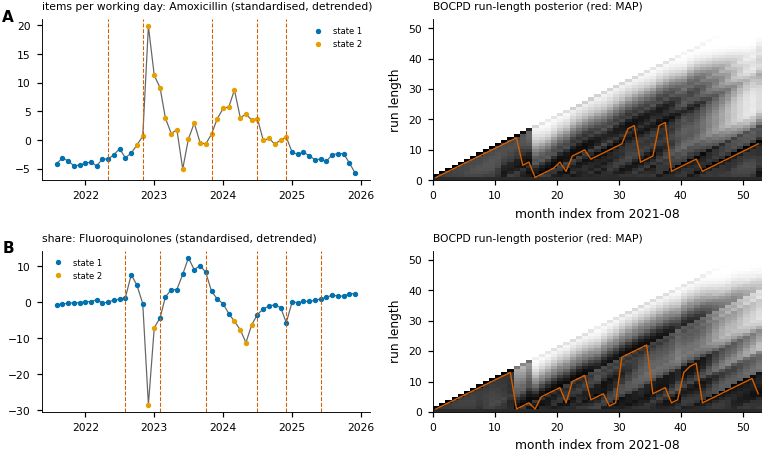

  figure: outputs_antibacterials/figures/supplementary/figure_s7_s8_regimes.png / .pdf
                            series method                                               result
items per working day: Amoxicillin  BOCPD          2022-05; 2022-11; 2023-11; 2024-07; 2024-12
items per working day: Amoxicillin    HMM            2 states by BIC (BIC: 2: 275.2, 3: 288.6)
           share: Fluoroquinolones  BOCPD 2022-08; 2023-02; 2023-10; 2024-07; 2024-12; 2025-06
           share: Fluoroquinolones    HMM            2 states by BIC (BIC: 2: 341.1, 3: 341.8)
  written: outputs_antibacterials/table_s_regimes_exploratory.csv


In [22]:
banner("EXPLORATORY: BOCPD AND HMM")
import logging
logging.getLogger("hmmlearn").setLevel(logging.ERROR)


def bocpd(x, hazard=BOCPD_HAZARD, mu0=0.0, kappa0=0.1, alpha0=1.0, beta0=1.0):
    x = np.asarray(x, float)
    n = len(x)
    R = np.zeros((n + 1, n + 1))
    R[0, 0] = 1.0
    mu, kappa, alpha, beta = (np.array([v]) for v in (mu0, kappa0, alpha0, beta0))
    for t in range(n):
        scale = np.sqrt(beta * (kappa + 1) / (alpha * kappa))
        pred = st.t.pdf(x[t], 2 * alpha, loc=mu, scale=scale)
        R[t + 1, 1:t + 2] = R[t, :t + 1] * pred * (1 - hazard)
        R[t + 1, 0] = (R[t, :t + 1] * pred * hazard).sum()
        R[t + 1] /= R[t + 1].sum()
        mu_n = (kappa * mu + x[t]) / (kappa + 1)
        beta_n = beta + kappa * (x[t] - mu) ** 2 / (2 * (kappa + 1))
        mu, kappa = np.concatenate([[mu0], mu_n]), np.concatenate([[kappa0], kappa + 1])
        alpha, beta = np.concatenate([[alpha0], alpha + 0.5]), np.concatenate([[beta0], beta_n])
    return R


def bocpd_changepoints(R, min_drop=3, dedup=3):
    rmap = R[1:].argmax(axis=1)
    cps = []
    for t in range(1, len(rmap)):
        if rmap[t] < rmap[t - 1] - min_drop:
            start = t + 1 - rmap[t] - 1
            if not cps or start - cps[-1] > dedup:
                cps.append(int(start))
    return rmap, cps


def regime_input(oc):
    y = deseasonalise(transformed(nat, oc, MAIN_BLOCK))
    t = np.arange(len(y))
    r = y - np.polyval(np.polyfit(t, y, 1), t)
    d = np.diff(r)
    s = np.median(np.abs(d - np.median(d))) / 0.6745 / np.sqrt(2)
    return r / s


try:
    from hmmlearn.hmm import GaussianHMM
    HAS_HMM = True
except ImportError:
    HAS_HMM = False
    print("hmmlearn not installed - HMM skipped.")


def fit_hmm(x, k, restarts=20):
    best = None
    for r in range(restarts):
        m = GaussianHMM(n_components=k, covariance_type="diag", n_iter=500, random_state=RANDOM_SEED + r,
                        init_params="mc", params="stmc")
        m.startprob_ = np.full(k, 1.0 / k)
        tm = np.full((k, k), 0.1 / (k - 1))
        np.fill_diagonal(tm, 0.9)
        m.transmat_ = tm
        try:
            m.fit(x.reshape(-1, 1))
            ll = m.score(x.reshape(-1, 1))
        except Exception:
            continue
        if best is None or ll > best[0]:
            best = (ll, m)
    return best


REGIME_SERIES = [("items_wd", "Amoxicillin"), ("share", "Fluoroquinolones")]
fig, axes = plt.subplots(2, 2, figsize=(180 * MM, 110 * MM))
d = to_dates(MAIN_BLOCK)
reg_rows = []
for r_i, oc in enumerate(REGIME_SERIES):
    x = regime_input(oc)
    R = bocpd(x)
    rmap, cps = bocpd_changepoints(R)
    reg_rows.append(dict(series=outcome_label(oc), method="BOCPD", result="; ".join(ym_str(MAIN_BLOCK[c]) for c in cps) or "none"))
    ax = axes[r_i, 1]
    ax.imshow(np.log(R[1:, :len(x)].T + 1e-12), origin="lower", aspect="auto", cmap="Greys",
              extent=[0, len(x), 0, len(x)])
    ax.plot(np.arange(len(x)) + 0.5, rmap, color=OKABE["vermillion"], lw=0.9)
    ax.set_xlabel("month index from %s" % ym_str(MAIN_BLOCK[0]))
    ax.set_ylabel("run length")
    ax.set_title("BOCPD run-length posterior (red: MAP)", loc="left", fontsize=7)
    ax = axes[r_i, 0]
    ax.plot(d, x, color=OKABE["grey"], lw=0.8)
    if HAS_HMM:
        fits = {}
        for k in (2, 3):
            b = fit_hmm(x, k)
            if b:
                pk = k * k + 2 * k - 1
                fits[k] = (b[1], -2 * b[0] + pk * np.log(len(x)))
        if fits:
            kbest = min(fits, key=lambda k: fits[k][1])
            states = fits[kbest][0].predict(x.reshape(-1, 1))
            cols = [OKABE["blue"], OKABE["orange"], OKABE["green"]]
            for s_ in range(kbest):
                ax.plot(d[states == s_], x[states == s_], "o", ms=2.5, color=cols[s_], label="state %d" % (s_ + 1))
            reg_rows.append(dict(series=outcome_label(oc), method="HMM",
                                 result="%d states by BIC (BIC: %s)" % (kbest, ", ".join("%d: %.1f" % (k, v[1]) for k, v in fits.items()))))
            ax.legend(fontsize=5.5)
    for c in cps:
        ax.axvline(d[c], color=OKABE["vermillion"], ls="--", lw=0.7)
    ax.set_title(outcome_label(oc) + " (standardised, detrended)", loc="left", fontsize=7)
    year_axis(ax)
    _label(ax, "AB"[r_i])
fig.tight_layout()
_save(fig, "figure_s7_s8_regimes", supplementary=True)
REGIMES = pd.DataFrame(reg_rows)
print(REGIMES.to_string(index=False))
save("table_s_regimes_exploratory", REGIMES)

## 15. Sensitivity analyses (Supplementary Table S7)

Each row re-estimates the headline quantities under one change:

* the other formulation scope (tablets/capsules only);
* Newey–West with 12 lags;
* three Fourier harmonics;
* 2023–24 events coded from the first full month (September 2023, February 2024);
* no winter nuisance terms;
* a 24-month pre-period;
* DDDs instead of items.

For the ICB design: the other scope, ICB-specific linear trends, and intensity measured over
all pre-policy months (August 2021 – July 2023) with the window starting in August 2021 (a longer
pre-period, at the cost of overlap between the baseline and the window). ICB-specific linear trends
fitted over the whole window also absorb effects that *grow* over time, which the fluoroquinolone
effect does, so that row is a conservative bound rather than a like-for-like check.

The section also shows directly why the tablets/capsules-only scope of the previous notebook
was biased. Under that scope, the clarithromycin SSP (a suspension → tablet swap) shows up as
a clarithromycin surge.

In [23]:
banner("SENSITIVITY ANALYSES")
EV["MHRA_FQ_AUG23_FULLMONTH"] = dict(EV["MHRA_FQ_AUG23"], id="MHRA_FQ_AUG23_FULLMONTH", date="2023-09-01")
EV["MHRA_FQ_JAN24_FULLMONTH"] = dict(EV["MHRA_FQ_JAN24"], id="MHRA_FQ_JAN24_FULLMONTH", date="2024-02-01")
ALT_SCOPE = "solid_oral" if FORMULATION_SCOPE == "all_oral" else "all_oral"
panel_alt = build_panel(presc, ALT_SCOPE)
nat_alt = national(panel_alt)


def step_pct(fit, term):
    if fit is None or term not in fit["hac"].params.index:
        return np.nan, np.nan, np.nan
    b = float(fit["hac"].params[term])
    lo, hi = (float(v) for v in fit["hac"].conf_int().loc[term])
    return 100 * (np.exp(b) - 1), 100 * (np.exp(lo) - 1), 100 * (np.exp(hi) - 1)


ITS_VARIANTS = [
    ("Primary specification", {}, "STEP_MHRA_FQ_JAN24"),
    ("Formulation scope: " + ALT_SCOPE, dict(frame=nat_alt), "STEP_MHRA_FQ_JAN24"),
    ("Newey-West 12 lags", dict(nw=12), "STEP_MHRA_FQ_JAN24"),
    ("Three Fourier harmonics", dict(harmonics=3), "STEP_MHRA_FQ_JAN24"),
    ("Events from first full month", dict(primary=["MHRA_FQ_AUG23_FULLMONTH", "MHRA_FQ_JAN24_FULLMONTH"],
                                          anchor=event_month("MHRA_FQ_JAN24_FULLMONTH")), "STEP_MHRA_FQ_JAN24_FULLMONTH"),
    ("No winter nuisance terms", dict(nuisance=[]), "STEP_MHRA_FQ_JAN24"),
    ("Pre-period limited to 24 months", dict(block=usable_block(FQ_ANCHOR, max_pre=24)), "STEP_MHRA_FQ_JAN24"),
]
rows = []
for lab, kw, term in ITS_VARIANTS:
    r = dict(analysis=lab)
    for tag, oc, kind in [("FQ share", ("share", "Fluoroquinolones"), "logit"),
                          ("FQ items", ("items", "Fluoroquinolones"), "log"),
                          ("Co-amoxiclav share", ("share", "Co-amoxiclav"), "logit")]:
        args = dict(primary=FQ_EVENTS, nuisance=nuisance_for(oc[1]), anchor=FQ_ANCHOR)
        args.update(kw)
        f = run_its("SENS", oc, kind, args.pop("primary"), family="sensitivity", scan=False, store=False, **args)
        r[tag], r[tag + " low"], r[tag + " high"] = step_pct(f, term)
    rows.append(r)
f = run_its("SENS_DDD", ("ddd", "Fluoroquinolones"), "log", FQ_EVENTS, WINTER_NUISANCE, anchor=FQ_ANCHOR,
            family="sensitivity", scan=False, store=False)
v = step_pct(f, "STEP_MHRA_FQ_JAN24")
rows.append({"analysis": "Outcome in DDDs (fluoroquinolones)", "FQ items": v[0], "FQ items low": v[1],
             "FQ items high": v[2]})
SENS_ITS = pd.DataFrame(rows)
print("Level change at 22 Jan 2024, % (odds of share, or items/DDDs), 95% CI:")
print(SENS_ITS.round(1).to_string(index=False))
save("table_s7a_sensitivity_its", SENS_ITS)

rows = []
for lab, (w_, p_full), kw in [
        ("Primary specification", (pw, panel), {}),
        ("Formulation scope: " + ALT_SCOPE, make_pw(panel_alt)[:1] + (panel_alt,), {}),
        ("ICB-specific linear trends", (pw, panel), dict(icb_trends=True)),
        ("Intensity from all pre-policy months, window from first usable month",
         (make_pw(panel, period=(MAIN_BLOCK[0], ym_add(event_month("MHRA_FQ_AUG23"), -1)),
                  window=(MAIN_BLOCK[0], STUDY_END))[0], panel), {})]:
    dec, fs = decomposition(w_, p_full, wild=False, **kw)
    r = dict(analysis=lab, first_stage=fs["theta_fq"], fs_low=fs["low"], fs_high=fs["high"])
    for u in ("Co-amoxiclav", "Doxycycline", "Cefalexin", "Nitrofurantoin"):
        row = dec[dec.unit == u]
        r[u + " % of displaced"] = float(row.share_of_displaced_pct.iloc[0]) if len(row) else np.nan
    rows.append(r)
SENS_ICB = pd.DataFrame(rows)
print("\nICB design: first stage (pp per pp) and % of displaced share going to each alternative:")
print(SENS_ICB.round(3).to_string(index=False))
save("table_s7b_sensitivity_icb", SENS_ICB)

print("\nWhy the scope matters - clarithromycin share during SSP054 (suspension dispensed as tablets):")
for lab, frame in [("all oral (primary)", nat if FORMULATION_SCOPE == "all_oral" else nat_alt),
                   ("tablets/capsules only", nat_alt if FORMULATION_SCOPE == "all_oral" else nat)]:
    f = run_its("SENS_CLARI", ("share", "Clarithromycin"), "logit", ["CLARI_SSP054", "CLARI_SSP_2024"],
                ["STREP_A_SURGE", "MHRA_FQ_AUG23", "MHRA_FQ_JAN24"], anchor=event_month("CLARI_SSP054"),
                family="sensitivity", frame=frame, scan=False, store=False)
    v = step_pct(f, "WIN_CLARI_SSP054")
    print("  %-24s %+.1f%% (95%% CI %+.1f to %+.1f)" % (lab, *v))

y_fq = break_series(("share", "Fluoroquinolones"))
h_fq = max(int(np.ceil(BREAK_TRIM * len(y_fq))), 6)
for mult in (1, 3):
    br, pen, _ = pelt(y_fq, h_fq, mult=mult)
    print("PELT on fluoroquinolone share, penalty x%d: %s" % (mult, "; ".join(ym_str(MAIN_BLOCK[b]) for b in br) or "none"))


SENSITIVITY ANALYSES
Level change at 22 Jan 2024, % (odds of share, or items/DDDs), 95% CI:
                          analysis  FQ share  FQ share low  FQ share high  FQ items  FQ items low  FQ items high  Co-amoxiclav share  Co-amoxiclav share low  Co-amoxiclav share high
             Primary specification     -13.8         -17.1          -10.3      -8.2         -11.7           -4.5                -4.8                    -7.1                     -2.5
     Formulation scope: solid_oral     -12.5         -15.3           -9.6      -8.3         -11.8           -4.7                -4.5                    -6.5                     -2.5
                Newey-West 12 lags     -13.8         -16.9          -10.5      -8.2         -10.4           -5.9                -4.8                    -7.1                     -2.5
           Three Fourier harmonics     -13.3         -16.4          -10.1      -7.6         -11.4           -3.5                -4.3                    -6.5                     -2

## 16. Results summary

Every number below is read from the estimate tables above; nothing is typed in. Interpretation
belongs in the manuscript, where it can be checked against these values.

In [24]:
banner("RESULTS SUMMARY")


def ci_txt(v, lo, hi, unit="%", sign=True, dp=1):
    f = ("%+." if sign else "%.") + str(dp) + "f"
    return (f % v) + unit + " (95% CI " + (f % lo) + " to " + (f % hi) + ")"


def items_txt(v, lo, hi):
    return "%s (95%% interval %s to %s)" % (format(int(round(v)), ","), format(int(round(lo)), ","),
                                             format(int(round(hi)), ","))


def its_row(model, term):
    t = pd.DataFrame(ITS_ROWS)
    r = t[(t.model == model) & (t.term == term)]
    return None if r.empty else r.iloc[0]


S = []
S.append("DATA: %s systemic oral antibacterial items (%s scope), %d ICBs, %d months (%d-%d); %d usable months "
         "after the COVID-19 exclusion." % (format(int(nat.TOTAL_ITEMS.sum()), ","), FORMULATION_SCOPE,
                                            panel.ORG_CODE.nunique(), len(ALL_MONTHS), STUDY_START, STUDY_END, len(USABLE)))
r1, r2, r3 = (its_row("FQ_share", t) for t in ("STEP_MHRA_FQ_JAN24", "SLOPE_MHRA_FQ_JAN24", "STEP_MHRA_FQ_AUG23"))
if r1 is not None:
    S.append("FLUOROQUINOLONES (national ITS): odds of the fluoroquinolone share changed by %s at 22 Jan 2024, "
             "with a further %s per month thereafter; August 2023 reminder: %s. Placebo-date p = %.3f; data-preferred "
             "break date %s." % (ci_txt(r1.pct, r1.pct_low, r1.pct_high), ci_txt(r2.pct, r2.pct_low, r2.pct_high),
                                ci_txt(r3.pct, r3.pct_low, r3.pct_high), r1.placebo_p, r1.scan_best))
    e = ITS_FITS["FQ_items"]["eff"]
    S.append("  Fluoroquinolone items vs counterfactual, %d months from Aug 2023: %s." % (e["n_months"], items_txt(e["point"], e["low"], e["high"])))
    e = ITS_FITS["All_items"]["eff"]
    S.append("  All antibacterial items, same months: %s." % items_txt(e["point"], e["low"], e["high"]))
rb = its_row("Broad_share", "STEP_MHRA_FQ_JAN24")
if rb is not None:
    S.append("  Broad-spectrum (NHS measure) share, Jan 2024 level change: %s." % ci_txt(rb.pct, rb.pct_low, rb.pct_high))
if "trend_decomposition" in RESULTS:
    for r in RESULTS["trend_decomposition"].itertuples():
        S.append("  TREND %s: %+.1f%%/year before the restriction (cumulative %+.1f%% across the window), "
                 "step %+.1f%%, %+.1f%%/year after." % (r.series, r.trend_pct_per_year,
                                                        r.cumulative_trend_over_window_pct, r.step_jan24_pct,
                                                        r.post_trend_pct_per_year))
if RESULTS.get("denominator_note"):
    S.append("  " + RESULTS["denominator_note"])
if "displacement_adjusted" in RESULTS:
    da = RESULTS["displacement_adjusted"]
    moved = da[(da.low > 0) | (da.high < 0)]
    S.append("  VOLUME-ADJUSTED displacement: " + ("; ".join(
        "%s %s items (95%% %s to %s)" % (r.alternative, format(int(r.excess_items), ","),
                                         format(int(r.low), ","), format(int(r.high), ","))
        for r in moved.itertuples()) if len(moved) else "no alternative changed detectably"))
fs = RESULTS["first_stage"]
S.append("ICB DESIGN: each 1 pp of baseline fluoroquinolone share -> %s pp change in fluoroquinolone share after "
         "Jan 2024 (wild cluster bootstrap p = %.3f)." % (ci_txt(fs["theta_fq"], fs["low"], fs["high"], unit="", dp=3), fs["p_wild"]))
if "first_stage_trend_adj" in RESULTS:
    ta = RESULTS["first_stage_trend_adj"]
    S.append("  Trend-adjusted first stage (ICB-specific trends): %s pp per pp." %
             ci_txt(ta["theta_fq"], ta["low"], ta["high"], unit="", dp=3))
if "lead_magnitude" in RESULTS:
    bad = RESULTS["lead_magnitude"][RESULTS["lead_magnitude"].p_leads < 0.05]
    if len(bad):
        S.append("  CAUTION - leads jointly non-zero for: " + "; ".join(
            "%s (leads %.0f%% of the estimated effect)" % (r.outcome, r.lead_pct_of_effect) for r in bad.itertuples()))
inf = DECOMP[DECOMP.informative] if "informative" in DECOMP.columns else DECOMP
S.append("  Rows with an informative share-of-displaced interval: %d of %d%s" %
         (len(inf), len(DECOMP), (" (" + ", ".join(inf.unit) + ")") if len(inf) else ""))
for _, d in DECOMP.head(5).iterrows():
    S.append("  %-24s %5.1f%% of the displaced share (95%% CI %.1f to %.1f; pro-rata expectation %.1f%%; "
             "excess over pro-rata %+.3f pp, wild p = %.3f)" % (d.unit, d.share_of_displaced_pct, d.share_low,
                                                                d.share_high, d.pro_rata_pct, d.excess_over_pro_rata_pp,
                                                                d.p_excess_wild))
pt = RESULTS["pretrends"]
S.append("  Joint pre-trend (lead) tests: " + "; ".join("%s p = %.3f" % (r.outcome, r.p) for r in pt.itertuples()))
for u in ("Phenoxymethylpenicillin", "Amoxicillin", "Clarithromycin"):
    t = casc[(casc.family == "Aim 2 cascade (items)") & (casc.unit == key(u))]
    if len(t):
        pk = t.loc[t.pct.idxmax()]
        e = ITS_FITS["CASCADE_items_" + key(u)]["eff"]
        S.append("CASCADE %s: largest monthly excess %s in %s; cumulative Nov 2022-May 2023 %s items." %
                 (u, ci_txt(pk.pct, pk.pct_low, pk.pct_high), ym_str(pk.month), items_txt(e["point"], e["low"], e["high"])))
for mid, lab in (("FORM_CLARITHROMYCIN", "clarithromycin (SSP054)"), ("FORM_PHENOXYMETHYLPENICILLIN", "PenV (SSP040-047)")):
    t = pd.DataFrame(ITS_ROWS)
    t = t[t.model == mid]
    if len(t):
        r = t.iloc[0]
        S.append("FORMULATION: odds of solid-dose dispensing for %s changed by %s while the SSP was active; %s items." %
                 (lab, ci_txt(r.pct, r.pct_low, r.pct_high), items_txt(r.model_abs_items, r.model_abs_low, r.model_abs_high)))
for r in aim3.itertuples():
    S.append("NITROFURANTOIN DSU (26 Apr 2023), %s: %s (BH q = %.3f)." % (r.outcome, ci_txt(r.pct, r.pct_low, r.pct_high), r.q_bh))
for r in UTI_TRENDS.itertuples():
    S.append("URINARY TREND %s: %s per year." % (r.series, ci_txt(r.pct_change_odds_per_year, r.low, r.high)))
b = BREAKS[BREAKS.series == "share: Fluoroquinolones"]
if len(b):
    b = b.iloc[0]
    S.append("BREAKS, fluoroquinolone share: Bai-Perron %s (95%% intervals %s); PELT %s; events inside the intervals: %s." %
             (b.bp_dates, b.bp_95ci, b.pelt_dates, b.events_in_ci))
S.append("GRANGER (descriptive): %d tests, %d with BH q < 0.05." % (len(GRANGER), (GRANGER.q_bh < 0.05).sum()))
for s_ in ITS_SKIPPED:
    S.append("NOT ESTIMATED: %s (%s) - %s" % (s_["model"], s_["outcome"], s_["reason"]))
print("\n".join(S))
with open(os.path.join(OUT_DIR, "results_summary.txt"), "w") as fh:
    fh.write("\n".join(S) + "\n")
save("models_not_estimated", pd.DataFrame(ITS_SKIPPED))
save("table_s4d_nuisance_terms", pd.DataFrame(ITS_NUISANCE_ROWS))
_nz = pd.DataFrame(ITS_NUISANCE_ROWS)
if len(_nz):
    _nz = _nz[(_nz.term.str.contains("MYCOPLASMA|CLARI_SSP|PENV_SSP")) & (_nz.p < 0.05)]
    print("\nConcurrent-event (nuisance) terms that moved a modelled series, p < 0.05: %d; "
          "full list in table_s4d_nuisance_terms.csv" % len(_nz))
    if len(_nz):
        print(_nz[["model", "term", "pct", "pct_low", "pct_high"]].round(1).head(12).to_string(index=False))


RESULTS SUMMARY
DATA: 176,879,270 systemic oral antibacterial items (all_oral scope), 42 ICBs, 60 months (202101-202512); 53 usable months after the COVID-19 exclusion.
FLUOROQUINOLONES (national ITS): odds of the fluoroquinolone share changed by -13.8% (95% CI -17.1 to -10.3) at 22 Jan 2024, with a further +0.2% (95% CI -0.1 to +0.5) per month thereafter; August 2023 reminder: -2.0% (95% CI -6.2 to +2.5). Placebo-date p = 0.083; data-preferred break date 2024-02.
  Fluoroquinolone items vs counterfactual, 29 months from Aug 2023: -193,739 (95% interval -247,090 to -143,810).
  All antibacterial items, same months: -5,051,517 (95% interval -11,238,014 to 793,867).
  Broad-spectrum (NHS measure) share, Jan 2024 level change: -9.1% (95% CI -12.1 to -5.9).
  TREND Fluoroquinolone share: -5.1%/year before the restriction (cumulative -20.4% across the window), step -13.8%, -3.2%/year after.
  TREND Fluoroquinolone items: -0.7%/year before the restriction (cumulative -2.8% across the window

## 17. Decisions needed from the authors

1. **NG109 and the 2019 MHRA restriction.** Neither can be tested with data starting January
   2021: there is no pre-period. To keep the "NG109" and "2019 MHRA" questions, add PCA
   extracts from January 2017 (NHSBSA publishes them) and set `STUDY_START = 201701`. Nothing
   else changes. The guard then finds 21 pre-months for NG109 and ≥12 post-months for both
   events before the COVID-19 exclusion, and fits them automatically. Otherwise, Aim 3 in the
   manuscript should be reframed around the nitrofurantoin safety update and the secular
   2021–25 trends.
2. **Dates still marked "month" or "to confirm"** in Table 1: the exact day of the August 2023
   and September 2023 MHRA fluoroquinolone communications, the AMR National Action Plan 2024
   publication date, the NG111 date, and the Strep A surge period (currently December 2022 –
   January 2023, per UKHSA).
3. **Primary outcome scale.** Items are the primary unit (one prescription = one decision).
   Report *items* (and DDDs) for how much of a drug was prescribed and *shares* for the mix;
   Section 10b splits each headline number into the two. Check the WHO DDD values in Section 2
   against the current ATC/DDD index, and any drug flagged by the DDDs-per-item guard, before
   quoting DDD results.
4. **Atypical pneumonia.** The *Mycoplasma pneumoniae* resurgence (November 2023 – July 2024) is now
   a nuisance term in the macrolide and doxycycline models. Two judgements are yours: whether to
   add levofloxacin (used for atypical pneumonia in adults, so the term could absorb part of the
   restriction effect it is meant to isolate), and whether to narrow the window once UKHSA's final
   dates are settled. Compare the azithromycin estimate with and without it before writing.
5. **Rates per population.** Everything here uses shares and within-ICB comparisons, so no
   population denominator is needed. If the manuscript wants ICB maps of prescribing *rates*,
   add ICB registered-population counts (NHS Digital, "Patients registered at a GP practice").
6. **Manuscript text.** Replace the Statistical analysis subsection with the text below. The
   previous notebook's numbers must not be carried into the Results: the "NG109 effect",
   "switching intensity", the 15/30 Granger "significant" links and the HMM/BOCPD regimes all
   came from defects A3, A6, A8, A11 and A12.

### Methods text (replacement for the Statistical analysis subsection)

**Data and outcomes.** We used NHSBSA Prescription Cost Analysis data for January 2021 to December
2025, restricted by BNF code to systemic antibacterials (BNF 5.1, excluding antituberculosis and
antileprotic drugs). Each chemical substance was mapped to one of 16 study drugs or five residual
groups by ordered rules that match combination products before their components. The 21 units
partition all systemic antibacterial items, so every share uses the full denominator. The primary
scope was oral solid and liquid formulations; tablets and capsules only was a sensitivity
analysis. Monthly item counts were aggregated to integrated care boards (ICBs; STP codes before
July 2022). Months affected by COVID-19 restrictions (23 March 2020 – 19 July 2021) were excluded
from all estimation windows.

**Events.** Regulatory, guideline and supply events were dated from primary sources (Table 1).
Step changes were coded as the fraction of the event month on or after the event date. Serious
shortage protocols were coded as time-limited windows. Events without at least 12 pre- and 6
post-event usable months were not modelled.

**Structural breaks.** For each series (log-odds of shares; log items per working day; STL-
deseasonalised, with Strep A surge months interpolated) we applied an OLS-CUSUM test scaled by a
Newey–West long-run variance, with a simulated null distribution. We also fitted Bai–Perron
piecewise-linear models (0–3 breaks, 15% trimming, number of breaks by BIC, break-date intervals
from a 999-replication moving-block bootstrap) and PELT with a BIC-type penalty (noise scale from the
Bai–Perron residuals). p-values were adjusted by the
Benjamini–Hochberg procedure.

**Interrupted time series.** Segmented regressions of log-odds shares or log item counts included:

* a linear trend and two Fourier harmonic pairs;
* log working days (count outcomes);
* the event terms;
* nuisance terms for concurrent events (Strep A pulses, the phenoxymethylpenicillin SSP window, the
  nitrofurantoin safety update or the clarithromycin SSP windows where relevant).

Each model used the longest run of usable months within 36 months of the event. Standard errors
were Newey–West with six lags; Breusch–Godfrey tests are reported. Absolute effects are fitted
minus counterfactual items, with 95% intervals from 10,000 draws of the coefficient vector. Each
effect was compared with a placebo-date scan of the same model. Because a share responds to its
denominator as well as its numerator, every headline effect is reported on both scales and the
identity (share change ≈ items change minus total-items change) is checked explicitly; national
substitution models carry log total antibacterial items, excluding fluoroquinolones and the drug
being modelled, as a covariate.

**Supply-shock cascade.** Each month from November 2022 to May 2023 received its own indicator in
models otherwise specified as above. Formulation substitution under the SSPs was analysed as the
log-odds of solid-dose dispensing.

**Substitution after fluoroquinolone restriction.** The primary substitution analysis exploited
variation in ICB exposure. It regressed each unit's percentage-point share of all items on
interactions of the ICB's baseline (July 2021 – June 2022) fluoroquinolone share with indicators
for August–December 2023 and for the period after 22 January 2024, with ICB and month fixed effects and baseline-share × seasonal
harmonic terms (seasonal swings in percentage points scale with the level of a share). Because shares sum to 100, coefficients across units sum to zero, which yields a
decomposition of the displaced share. It was compared with a pro-rata benchmark representing
prescriptions not being replaced. Inference used cluster-robust standard errors by ICB (t
distribution, G − 1 degrees of freedom) and restricted wild cluster bootstrap p-values (9,999
Rademacher replications). An event study by quarter tested for differential pre-trends; where leads
were jointly non-zero we report their size relative to the estimated effect and an estimate with
ICB-specific linear trends alongside the primary one.

**Descriptive dynamics.** Within clinical markets we fitted VAR models to deseasonalised log-ratios
(lag by AIC, differencing guided by ADF/KPSS tests). We report Granger F-tests with BH correction
and orthogonalised impulse responses with Monte Carlo bands, interpreted descriptively. Panel
cross-lagged models with ICB and month fixed effects provided the within-ICB counterpart.
Exploratory BOCPD and Gaussian HMMs on deseasonalised, detrended series are reported in the
Supplement.

All analyses used Python (statsmodels, ruptures, hmmlearn); the notebook reproduces every table and
figure from the raw extracts.

In [25]:
banner("EXPORT")
import shutil
csvs = sorted(glob.glob(os.path.join(OUT_DIR, "*.csv")))
try:
    used = set()
    with pd.ExcelWriter(os.path.join(OUT_DIR, "all_tables.xlsx"), engine="openpyxl") as xw:
        for f in csvs:
            base = os.path.basename(f)[:-4]
            if base.startswith("extract_"):
                continue
            name = base[:31]
            i = 1
            while name in used:
                name = base[:28] + "_%d" % i
                i += 1
            used.add(name)
            pd.read_csv(f).to_excel(xw, sheet_name=name, index=False)
    print("Workbook: " + os.path.join(OUT_DIR, "all_tables.xlsx") + " (%d sheets)" % len(used))
except ImportError:
    print("openpyxl not installed - tables are available as CSV files.")
archive = shutil.make_archive(OUT_DIR, "zip", OUT_DIR)
n_fig = len(glob.glob(os.path.join(FIGDIR, "*.png"))) + len(glob.glob(os.path.join(SFIGDIR, "*.png")))
print("Tables: %d CSV | figures: %d (PNG + PDF) | archive: %s" % (len(csvs), n_fig, archive))


EXPORT
Workbook: outputs_antibacterials/all_tables.xlsx (30 sheets)
Tables: 30 CSV | figures: 12 (PNG + PDF) | archive: /content/drive/MyDrive/KCL/Drug/outputs_antibacterials.zip
